# DIMER Notebook: Document-Type Classification with DiT
## RVL-CDIP with Microsoft Document Image Transformer (DiT)

**Notebook profile:** `TASK-INFERENCE`  
**Pedagogical mode:** `WORKSHOP`  
**DIMER Notebook Specification:** `2.2`  
**Standalone:** yes  
**Task:** whole-page document-type classification  
**Canonical model:** `microsoft/dit-base-finetuned-rvlcdip`  
**Classes:** 16  
**Adaptation:** none

This notebook treats each document page as an image and predicts one of the 16 RVL-CDIP document types.

The notebook covers:

- immutable model acquisition and an explicit `.bin → SafeTensors` candidate conversion boundary;
- balanced RVL-CDIP-derived evaluation sampling;
- accuracy, macro F1 and top-3 accuracy;
- per-class metrics and confusion analysis;
- high-confidence and low-margin errors;
- rotation, resolution and crop robustness;
- score/margin/entropy interpretation;
- machine-readable outputs and provenance; and
- optional BYOD page classification.

> **Candidate status.** The upstream model repository currently exposes a PyTorch pickle checkpoint on its pinned revision. This notebook verifies the exact source SHA-256, loads the state dict with `weights_only=True`, converts it locally to SafeTensors, proves logit parity, and performs the remainder of inference from the converted representation. A future DIMER-hosted release should ship the already-converted SafeTensors snapshot and remove the source-conversion step from the user path.

**AI Use Disclosure:** Generative AI assisted with this notebook’s code and instructional content under maintainer direction. The maintainer remains responsible for review, validation, and release decisions. AI-generated material may contain errors; validation claims are limited to documented runs and configurations. AI use does not imply independent verification, provider endorsement, or release approval.

## How to use this notebook

**Who it is for.** Learners who can run Python cells in Colab/Jupyter and are new to image classification or document intelligence.

**Runtime.** Use the documented GPU runtime for the canonical DiT evaluation.

**How to run it.**
1. Select the documented runtime/accelerator.
2. Choose **Run all** for the canonical path; leave the default settings unchanged on your first pass.
3. Read the explanatory markdown while the notebook runs.
4. Sections marked **Infrastructure** support reproducibility, model acquisition, or orchestration. Run those cells as written; understanding their implementation is not a learning objective.

### Task at a glance

`document page image → DiT classifier → fixed document-type label + score → confusion/robustness analysis`

### Roadmap

1. Understand the task and its input/output contract.
2. Inspect and validate the built-in data or inputs.
3. Establish the baseline/reference behavior.
4. Run the model or multi-model comparison.
5. Inspect errors, disagreements, robustness, and/or resource tradeoffs.
6. Try one controlled change and explain what changed.
7. Write an evidence-based conclusion; optionally continue with BYOD.

### What successful execution looks like

You should finish with a validated input/sample, the notebook's principal baseline/reference, model outputs and evaluation results, at least one diagnostic or qualitative comparison, and machine-readable results/provenance where supported. Exact values can vary slightly across supported runtimes; focus on the defined metrics and the observed pattern.

**Reading layers:** Core concepts explain page images, learned representations and fixed classes. Evaluation practice covers baselines, metrics and controlled transformations. Infrastructure cells install packages, verify weights and prepare data; their code is collapsed and may stay collapsed. For active learning, run section by section and write each prediction before revealing results. The optional activity below reads existing robustness results without changing canonical predictions.


## 1. Document classification is not OCR or Document QA

This notebook answers:

> **What kind of document is this page?**

It does not answer:

- What text is on the page?
- What field/value appears in the document?
- What does a table contain?
- What is the answer to a question about the page?

The classifier uses visual evidence from the whole rendered page and outputs one fixed RVL-CDIP class.

## 2. Why DiT?

Microsoft's Document Image Transformer (DiT) adapts a vision-transformer-style architecture to document images. The selected checkpoint is already fine-tuned for the 16-way RVL-CDIP task.

The model configuration uses a BEiT-style image transformer with:

- 12 transformer layers;
- hidden size 768;
- 12 attention heads;
- 16×16 image patches;
- 224×224 model input; and
- mean pooling before a 16-class classification head.

A key practical consequence is that a potentially very large page image is ultimately compressed into a 224×224 model view.

## 3. Configuration

The default values form the canonical `Run all` path.

In [ ]:
USE_BYOD = False  # @param {type:"boolean"}
BYOD_PATH = ""  # @param {type:"string"}
BYOD_LABELS_PATH = ""  # @param {type:"string"}

SAMPLE_SEED = 42  # @param {type:"integer"}
SAMPLE_PER_CLASS = 20  # @param {type:"integer"}

RUN_ROBUSTNESS = True  # @param {type:"boolean"}
RUN_SELECTIVE_CLASSIFICATION = False  # @param {type:"boolean"}

OUTPUT_DIR = "outputs/document_type_classification"
WORK_DIR = "work/document_type_classification"  # isolated environment, carried files and stage state

MIN_IMAGE_SIDE = 32
MAX_IMAGE_SIDE = 4096
MAX_PIXELS = 32_000_000
BATCH_SIZE = 16

if SAMPLE_PER_CLASS != 20:
    raise ValueError("The canonical tutorial sample uses exactly 20 pages per class.")
print({
    "sample_seed": SAMPLE_SEED,
    "sample_per_class": SAMPLE_PER_CLASS,
    "run_robustness": RUN_ROBUSTNESS,
    "use_byod": USE_BYOD,
    "output_dir": OUTPUT_DIR,
})

{'sample_seed': 42, 'sample_per_class': 20, 'run_robustness': True, 'use_byod': False, 'output_dir': 'outputs/document_type_classification'}


### Isolated runtime: no kernel install, no restart

The model code runs in its own Python environment, so **Run all** needs no restart and nothing is installed into this kernel. The next cell writes two carried files and checks their SHA-256: the stage file that holds every model, download and dataset step, and a hash lock of its packages. The runtime cell after it downloads a pinned `uv`, builds a CPython 3.12.12 environment and installs only hash-verified wheels. Each model step then runs as a separate process with that environment's Python, and this kernel reads its results.

**Linux x86_64 only:** Google Colab, Kaggle or a Linux x86_64 Jupyter server. Windows and macOS kernels are refused. The first run spends several minutes building the environment; later runs in the same session reuse it.

> **Infrastructure.** Run these cells as written; their implementation is not a learning objective.


In [ ]:
# @title Carried stage file and hash lock (infrastructure)
# Generated by tools/build_document_classification_workshop_carrier.py; do not edit by hand.
CARRIED_FILES = {
 'document_classification_workshop.py': (
  '"""Model stages of the DiT document-type classification workshop notebook.\n\nThe notebook carries this file byte-for-byte (cell ``uvcarrier``) and runs every stage that needs\nPyTorch, Transformers, datasets or the Hugging Face Hub as a subprocess on the Python of an isolated\nuv environment::\n\n    python document_classification_workshop.py --config stage_config.json --stage <name> [options]\n\nNothing here is imported into the notebook kernel. The kernel keeps the metrics, tables, galleries and\nexports, which need only NumPy and Pillow; stages hand results back as JSON, ``.npy`` arrays and\nlossless PNG pages under ``<work_dir>/state`` and ``<work_dir>/pages``.\n\nThe function bodies are the notebook\'s former in-kernel cells (442373b0, 3eaee889, d954e7b8,\nca003003, 18aafd5c, fe55f221, b485b2eb, 3891d68d) with the display code left in the notebook.\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport hashlib\nimport importlib.metadata as importlib_metadata\nimport io\nimport json\n'
  'import shutil\nimport sys\nimport time\nfrom collections import Counter, defaultdict\nfrom pathlib import Path\n\nSTAGES = ("environment", "download", "convert", "dataset", "sample", "load-check", "predict")\n\nPINS = {\n    "torch": "2.14.0",\n    "torchvision": "0.29.0",\n    "torchaudio": "2.11.0",\n    "transformers": "4.57.6",\n    "safetensors": "0.8.0",\n    "numpy": "2.1.3",\n    "pillow": "11.3.0",\n    "huggingface-hub": "0.36.2",\n    "datasets": "4.1.1",\n}\n\nMODEL_ID = "microsoft/dit-base-finetuned-rvlcdip"\nMODEL_REVISION = "23f8b03d130fb66bbc9a15df3c75d753e49240eb"\nSOURCE_BIN_SHA256 = "1b7a901642c36ec7e32de997683223faf02028624fb2e62a7e7e798a5dd1344e"\n\nSOURCE_DIR = Path("weights/dit-rvlcdip-source")\nCONVERTED_DIR = Path("weights/dit-rvlcdip-safetensors")\n\nLABELS = [\n    "letter","form","email","handwritten","advertisement","scientific report",\n    "scientific publication","specification","file folder","news article","budget",\n    "invoice","presentation","questionnaire","resume","memo"\n]\n\n'
  'ROBUSTNESS_VARIANTS = ["original","rotate90","rotate180","low_resolution","center_crop"]\n\n# Set by main() from the notebook\'s stage configuration.\nCONFIG: dict = {}\nWORK = Path("work/document_type_classification")\n\n\n# ---- shared helpers -------------------------------------------------------------------------------------\ndef installed_version(name):\n    try:\n        return importlib_metadata.version(name)\n    except importlib_metadata.PackageNotFoundError:\n        return None\n\n\ndef matches_public_version(observed, expected):\n    from packaging.version import InvalidVersion, Version\n\n    if observed is None:\n        return False\n    try:\n        return Version(Version(str(observed)).public) == Version(Version(str(expected)).public)\n    except InvalidVersion:\n        return False\n\n\ndef sha256_file(path):\n    h = hashlib.sha256()\n    with open(path, "rb") as f:\n        for chunk in iter(lambda: f.read(1 << 20), b""):\n            h.update(chunk)\n    return h.hexdigest()\n\n\n'
  'def write_state(name, value):\n    path = WORK / "state" / name\n    path.parent.mkdir(parents=True, exist_ok=True)\n    path.write_text(json.dumps(value, indent=2), encoding="utf-8")\n    return path\n\n\ndef read_state(name):\n    return json.loads((WORK / "state" / name).read_text(encoding="utf-8"))\n\n\ndef device():\n    import torch\n\n    return "cuda:0" if torch.cuda.is_available() else "cpu"\n\n\n# ---- environment ----------------------------------------------------------------------------------------\ndef verify_environment():\n    """Every pinned distribution in this environment has its pinned public version."""\n    observed = {k: installed_version(k) for k in PINS}\n    bad = {k: (observed[k], v) for k, v in PINS.items() if not matches_public_version(observed[k], v)}\n    if bad:\n        raise RuntimeError(f"Isolated environment does not match the pins: {bad}")\n    return observed\n\n\ndef stage_environment():\n    verify_environment()\n    import datasets\n    import huggingface_hub\n'
  '    import numpy as np\n    import torch\n    import torchvision\n    import transformers\n\n    runtime = {\n        "python": sys.version.split()[0],\n        "torch": torch.__version__,\n        "torchvision": torchvision.__version__,\n        "transformers": transformers.__version__,\n        "datasets": datasets.__version__,\n        "huggingface_hub": huggingface_hub.__version__,\n        "numpy": np.__version__,\n        "pillow": importlib_metadata.version("pillow"),\n        "device": device(),\n        "cuda_available": torch.cuda.is_available(),\n    }\n    if torch.cuda.is_available():\n        runtime["gpu_name"] = torch.cuda.get_device_name(0)\n        runtime["gpu_total_memory_bytes"] = torch.cuda.get_device_properties(0).total_memory\n    write_state("runtime.json", runtime)\n    print(runtime)\n\n\n# ---- model identity, download and conversion -------------------------------------------------------------\ndef download_and_verify_checkpoint():\n'
  '    """Download the pinned files and refuse a source checkpoint whose SHA-256 differs from the pin."""\n    from huggingface_hub import hf_hub_download\n\n    SOURCE_DIR.mkdir(parents=True, exist_ok=True)\n    CONVERTED_DIR.mkdir(parents=True, exist_ok=True)\n    for filename in ("config.json", "preprocessor_config.json", "pytorch_model.bin"):\n        hf_hub_download(\n            repo_id=MODEL_ID,\n            filename=filename,\n            revision=MODEL_REVISION,\n            local_dir=str(SOURCE_DIR),\n        )\n\n    source_bin = SOURCE_DIR / "pytorch_model.bin"\n    actual_source_sha = sha256_file(source_bin)\n    if actual_source_sha != SOURCE_BIN_SHA256:\n        raise RuntimeError(\n            f"Source checkpoint SHA-256 {actual_source_sha} != pinned {SOURCE_BIN_SHA256}; refusing to load"\n        )\n    return {\n        "model_id": MODEL_ID,\n        "revision": MODEL_REVISION,\n        "source_bin_bytes": source_bin.stat().st_size,\n        "source_bin_sha256": actual_source_sha,\n'
  '        "config_sha256": sha256_file(SOURCE_DIR / "config.json"),\n        "processor_sha256": sha256_file(SOURCE_DIR / "preprocessor_config.json"),\n    }\n\n\ndef stage_download():\n    record = download_and_verify_checkpoint()\n    write_state("download.json", record)\n    print(record)\n\n\ndef make_probe(kind):\n    from PIL import Image, ImageDraw\n\n    image = Image.new("RGB", (900, 1200), "white")\n    draw = ImageDraw.Draw(image)\n    if kind == "letter":\n        for y in range(140, 980, 45):\n            draw.line((120,y,760,y), fill="black", width=3)\n        draw.rectangle((110,80,420,115), outline="black", width=3)\n    else:\n        for y in range(100, 1050, 80):\n            draw.rectangle((100,y,800,y+35), outline="black", width=2)\n        draw.line((450,100,450,1085), fill="black", width=2)\n    return image\n\n\ndef convert_and_verify():\n    """Convert the verified pickle once to SafeTensors and prove tensor identity and logit parity."""\n    import torch\n'
  '    from safetensors.torch import save_file\n    from transformers import AutoConfig, AutoImageProcessor, AutoModelForImageClassification\n\n    downloaded = read_state("download.json")\n    source_bin = SOURCE_DIR / "pytorch_model.bin"\n    if sha256_file(source_bin) != SOURCE_BIN_SHA256:\n        raise RuntimeError("Source checkpoint changed after verification; run the download cell again")\n\n    # Copy load-bearing non-weight assets into the converted snapshot.\n    shutil.copy2(SOURCE_DIR / "config.json", CONVERTED_DIR / "config.json")\n    shutil.copy2(SOURCE_DIR / "preprocessor_config.json", CONVERTED_DIR / "preprocessor_config.json")\n\n    config = AutoConfig.from_pretrained(str(SOURCE_DIR), local_files_only=True)\n    actual_labels = [config.id2label[i] for i in range(16)]\n    if actual_labels != LABELS:\n        raise RuntimeError(f"Config class ordering changed: {actual_labels}")\n\n    state = torch.load(source_bin, map_location="cpu", weights_only=True)\n'
  '    if not isinstance(state, dict) or not state:\n        raise RuntimeError("Source checkpoint did not decode to a non-empty state dict")\n\n    source_model = AutoModelForImageClassification.from_config(config)\n    missing, unexpected = source_model.load_state_dict(state, strict=False)\n    if missing or unexpected:\n        raise RuntimeError(f"Strict state identity failed; missing={missing}, unexpected={unexpected}")\n    source_model.eval()\n\n    converted_path = CONVERTED_DIR / "model.safetensors"\n    cpu_state = {k: v.detach().cpu().contiguous() for k,v in source_model.state_dict().items()}\n    save_file(cpu_state, str(converted_path))\n\n    converted_sha256 = sha256_file(converted_path)\n    conversion_manifest = {\n        "format": "dimer_derived_model_snapshot",\n        "formatVersion": 1,\n        "modelKey": "dit-base-finetuned-rvlcdip",\n        "modelId": MODEL_ID,\n        "revision": MODEL_REVISION,\n        "source": {\n            "file": "pytorch_model.bin",\n'
  '            "bytes": source_bin.stat().st_size,\n            "sha256": SOURCE_BIN_SHA256,\n            "serialization": "PyTorch pickle; loaded only with weights_only=True",\n        },\n        "derived": {\n            "file": "model.safetensors",\n            "bytes": converted_path.stat().st_size,\n            "sha256": converted_sha256,\n            "derivedFromSha256": SOURCE_BIN_SHA256,\n        },\n        "companions": {\n            "config.json": downloaded["config_sha256"],\n            "preprocessor_config.json": downloaded["processor_sha256"],\n        },\n        "conversion": {\n            "torch": torch.__version__,\n            "safetensors": importlib_metadata.version("safetensors"),\n        },\n        "redistributionStatus": "pending-review",\n        "hostingStatus": "HOLD",\n    }\n    (CONVERTED_DIR / "dimer-base-manifest.json").write_text(\n        json.dumps(conversion_manifest, indent=2), encoding="utf-8"\n    )\n\n'
  '    processor_probe = AutoImageProcessor.from_pretrained(str(CONVERTED_DIR), local_files_only=True)\n    converted_model_probe = AutoModelForImageClassification.from_pretrained(\n        str(CONVERTED_DIR), local_files_only=True\n    ).eval()\n\n    probe_images = [make_probe("letter"), make_probe("form")]\n    probe_inputs = processor_probe(images=probe_images, return_tensors="pt")\n\n    with torch.inference_mode():\n        source_logits = source_model(**probe_inputs).logits\n        converted_logits = converted_model_probe(**probe_inputs).logits\n\n    max_abs_logit_diff = float((source_logits - converted_logits).abs().max())\n    if max_abs_logit_diff > 1e-6:\n        raise RuntimeError(f"Converted logit parity failed: max abs diff={max_abs_logit_diff}")\n\n    if list(source_model.state_dict()) != list(converted_model_probe.state_dict()):\n        raise RuntimeError("Converted state-dict key ordering differs from source model")\n\n    for key in source_model.state_dict():\n'
  '        a, b = source_model.state_dict()[key], converted_model_probe.state_dict()[key]\n        if a.shape != b.shape or a.dtype != b.dtype or not torch.equal(a, b):\n            raise RuntimeError(f"Converted tensor mismatch: {key}")\n\n    return {\n        "converted_bytes": converted_path.stat().st_size,\n        "converted_sha256": converted_sha256,\n        "parity_max_abs_logit_diff": max_abs_logit_diff,\n        "status": "candidate conversion verified",\n    }\n\n\ndef stage_convert():\n    record = convert_and_verify()\n    write_state("convert.json", record)\n    print(record)\n\n\n# ---- dataset and the deterministic tutorial sample -------------------------------------------------------\ndef load_pinned_test_split():\n    from datasets import load_dataset\n\n    dataset_test = load_dataset(\n        CONFIG["dataset_id"],\n        split="test",\n        revision=CONFIG["dataset_revision"],\n    )\n    if len(dataset_test) != 992:\n'
  '        raise RuntimeError(f"Expected 992 rows in the pinned derived test split, got {len(dataset_test)}")\n    return dataset_test\n\n\ndef stage_dataset():\n    dataset_test = load_pinned_test_split()\n    record = {\n        "dataset_id": CONFIG["dataset_id"],\n        "dataset_revision": CONFIG["dataset_revision"],\n        "test_rows": len(dataset_test),\n    }\n    write_state("dataset.json", record)\n    print(record)\n\n\ndef select_sample_indices(labels, sample_seed, sample_per_class):\n    """Rank rows within each class by SHA-256 of seed:row:label and keep the first rows of each class."""\n    ranked = defaultdict(list)\n    for row_index, label_id in enumerate(labels):\n        label_id = int(label_id)\n        key = hashlib.sha256(f"{sample_seed}:{row_index}:{label_id}".encode()).hexdigest()\n        ranked[label_id].append((key,row_index))\n\n    selected_indices = []\n    for label_id in range(16):\n        items = sorted(ranked[label_id])\n        if len(items) < sample_per_class:\n'
  '            raise RuntimeError(f"Class {label_id} has only {len(items)} rows")\n        selected_indices.extend(idx for _key,idx in items[:sample_per_class])\n    return sorted(selected_indices)\n\n\ndef image_bytes_and_rgb(value):\n    from PIL import Image\n\n    if isinstance(value, Image.Image):\n        image = value.convert("RGB")\n        buffer = io.BytesIO()\n        image.save(buffer, format="PNG")\n        data = buffer.getvalue()\n        return data, image\n    if isinstance(value, dict) and value.get("bytes") is not None:\n        data = value["bytes"]\n        image = Image.open(io.BytesIO(data))\n        image.load()\n        return data, image.convert("RGB")\n    raise TypeError(f"Unsupported dataset image type: {type(value).__name__}")\n\n\ndef pixel_sha256(image):\n    return hashlib.sha256(f"{image.width}x{image.height}:".encode() + image.tobytes()).hexdigest()\n\n\ndef build_sample(dataset_test, page_dir):\n'
  '    """Decode, validate and digest the selected pages; write each as a lossless RGB PNG for the kernel."""\n    sample_seed, sample_per_class = CONFIG["sample_seed"], CONFIG["sample_per_class"]\n    min_side, max_side, max_pixels = CONFIG["min_image_side"], CONFIG["max_image_side"], CONFIG["max_pixels"]\n    labels = [int(label) for label in dataset_test["label"]]\n    selected_indices = select_sample_indices(labels, sample_seed, sample_per_class)\n\n    page_dir = Path(page_dir)\n    if page_dir.exists():\n        shutil.rmtree(page_dir)\n    page_dir.mkdir(parents=True)\n    sample_records = []\n    seen_pixel_digests = set()\n\n    for row_index in selected_indices:\n        row = dataset_test[row_index]\n        raw_bytes, image = image_bytes_and_rgb(row["image"])\n        label_id = int(row["label"])\n        if label_id not in range(16):\n            raise RuntimeError(f"Invalid class id {label_id}")\n        if not (min_side <= min(image.size) and max(image.size) <= max_side):\n'
  '            raise RuntimeError(f"Row {row_index}: dimensions {image.size} outside tutorial limits")\n        if image.width * image.height > max_pixels:\n            raise RuntimeError(f"Row {row_index}: image exceeds {max_pixels} pixels")\n        pixel_digest = pixel_sha256(image)\n        if pixel_digest in seen_pixel_digests:\n            raise RuntimeError(f"Duplicate decoded page detected at source row {row_index}")\n        seen_pixel_digests.add(pixel_digest)\n        image_id = f"rvl-derived-test-{row_index:04d}"\n        png = page_dir / f"{image_id}.png"\n        image.save(png, format="PNG")\n        sample_records.append({\n            "image_id": image_id,\n            "source_row_index": row_index,\n            "png": str(png),\n            "source_bytes_sha256": hashlib.sha256(raw_bytes).hexdigest(),\n            "pixel_sha256": pixel_digest,\n            "width": image.width,\n            "height": image.height,\n            "label_id": label_id,\n            "label": LABELS[label_id],\n'
  '        })\n\n    counts = Counter(r["label_id"] for r in sample_records)\n    if (len(sample_records) != 16 * sample_per_class or set(counts.values()) != {sample_per_class}\n            or len(counts) != 16):\n        raise RuntimeError(f"Balanced sample validation failed: {counts}")\n\n    sample_digest_payload = "\\n".join(\n        json.dumps(\n            [r["source_row_index"], r["label_id"], r["pixel_sha256"]],\n            separators=(",",":"),\n        )\n        for r in sorted(sample_records, key=lambda x:x["source_row_index"])\n    )\n    sample_digest = hashlib.sha256(sample_digest_payload.encode()).hexdigest()\n    return {"records": sample_records, "sample_digest": sample_digest}\n\n\ndef stage_sample():\n    sample = build_sample(load_pinned_test_split(), WORK / "pages" / "sample")\n    write_state("sample.json", sample)\n    print({"sample_images": len(sample["records"]), "sample_digest": sample["sample_digest"]})\n\n\n'
  '# ---- model load and inference ----------------------------------------------------------------------------\ndef load_converted_model():\n    """Load only the converted SafeTensors snapshot; the source pickle is never used for evaluation."""\n    from transformers import AutoImageProcessor, AutoModelForImageClassification\n\n    processor = AutoImageProcessor.from_pretrained(str(CONVERTED_DIR), local_files_only=True)\n    t0 = time.perf_counter()\n    model = AutoModelForImageClassification.from_pretrained(\n        str(CONVERTED_DIR),\n        local_files_only=True,\n    ).to(device()).eval()\n    model_load_seconds = time.perf_counter() - t0\n    config_labels = [model.config.id2label[i] for i in range(16)]\n    if config_labels != LABELS:\n        raise RuntimeError("Loaded class ordering differs from canonical RVL-CDIP order")\n    return processor, model, model_load_seconds\n\n\ndef stage_load_check():\n    _processor, model, model_load_seconds = load_converted_model()\n    record = {\n'
  '        "model_load_seconds": model_load_seconds,\n        "parameter_count": sum(p.numel() for p in model.parameters()),\n        "class_count": len(LABELS),\n        "device": device(),\n    }\n    write_state("load_check.json", record)\n    print(record)\n\n\ndef batched_predict(processor, model, records, batch_size):\n    import numpy as np\n    import torch\n\n    DEVICE = device()\n    all_logits = []\n    timings = []\n    if torch.cuda.is_available():\n        torch.cuda.reset_peak_memory_stats()\n\n    # Warm-up.\n    warm = processor(images=[records[0]["image"]], return_tensors="pt").to(DEVICE)\n    with torch.inference_mode():\n        _ = model(**warm).logits\n    if torch.cuda.is_available():\n        torch.cuda.synchronize()\n\n    for start in range(0, len(records), batch_size):\n        batch_records = records[start:start+batch_size]\n        inputs = processor(\n            images=[r["image"] for r in batch_records],\n            return_tensors="pt",\n        ).to(DEVICE)\n'
  '        if torch.cuda.is_available():\n            torch.cuda.synchronize()\n        t0 = time.perf_counter()\n        with torch.inference_mode():\n            logits = model(**inputs).logits\n        if torch.cuda.is_available():\n            torch.cuda.synchronize()\n        timings.append(time.perf_counter() - t0)\n        if logits.shape != (len(batch_records), 16):\n            raise RuntimeError(f"Unexpected logits shape: {tuple(logits.shape)}")\n        if not torch.isfinite(logits).all():\n            raise RuntimeError("Model produced non-finite logits")\n        all_logits.append(logits.float().cpu())\n\n    logits = torch.cat(all_logits, dim=0).numpy()\n    scores = torch.softmax(torch.from_numpy(logits), dim=1).numpy()\n    if not np.allclose(scores.sum(axis=1), 1.0, atol=1e-5):\n        raise RuntimeError("Softmax score rows do not sum approximately to 1")\n    peak_gpu = torch.cuda.max_memory_allocated() if torch.cuda.is_available() else None\n    return logits, scores, timings, peak_gpu\n\n'
  '\ndef transform_variant(image, variant):\n    from PIL import Image\n\n    image = image.convert("RGB")\n    if variant == "original":\n        return image\n    if variant == "rotate90":\n        return image.rotate(-90, expand=True, fillcolor="white")\n    if variant == "rotate180":\n        return image.rotate(180, expand=True, fillcolor="white")\n    if variant == "low_resolution":\n        low = image.resize((112,112), Image.Resampling.BILINEAR)\n        return low.resize(image.size, Image.Resampling.BILINEAR)\n    if variant == "center_crop":\n        w,h = image.size\n        cw,ch = int(w*0.8), int(h*0.8)\n        x0,y0 = (w-cw)//2, (h-ch)//2\n        return image.crop((x0,y0,x0+cw,y0+ch))\n    raise ValueError(variant)\n\n\ndef stage_predict(job_dir):\n    """Score the pages listed in <job_dir>/job.json; write logits.npy, scores.npy and result.json there.\n\n    An item with a "variant" is transformed here first and the transformed page is written back as\n'
  '    PNG, so the notebook displays exactly the page the model scored.\n    """\n    import numpy as np\n    from PIL import Image\n\n    job_dir = Path(job_dir)\n    job = json.loads((job_dir / "job.json").read_text(encoding="utf-8"))\n    records = []\n    scored_paths = []\n    for k, item in enumerate(job["items"]):\n        with Image.open(item["path"]) as opened:\n            image = opened.convert("RGB")\n        variant = item.get("variant")\n        if variant is not None:\n            image = transform_variant(image, variant)\n            path = job_dir / f"scored-{k:04d}.png"\n            image.save(path, format="PNG")\n            scored_paths.append(str(path))\n        else:\n            scored_paths.append(item["path"])\n        records.append({"image": image})\n    if not records:\n        raise ValueError("No pages to score")\n    processor, model, _seconds = load_converted_model()\n    logits, scores, timings, peak_gpu = batched_predict(processor, model, records, int(job["batch_size"]))\n'
  '    np.save(job_dir / "logits.npy", logits)\n    np.save(job_dir / "scores.npy", scores)\n    (job_dir / "result.json").write_text(json.dumps({\n        "timings": timings,\n        "peak_gpu_memory_bytes": peak_gpu,\n        "scored_paths": scored_paths,\n        "device": device(),\n    }, indent=2), encoding="utf-8")\n    print({"pages": len(records), "batches": len(timings), "device": device()})\n\n\n# ---- command line ---------------------------------------------------------------------------------------\ndef main(argv=None):\n    global CONFIG, WORK\n    parser = argparse.ArgumentParser(description=__doc__.splitlines()[0])\n    parser.add_argument("--config", required=True)\n    parser.add_argument("--stage", required=True, choices=STAGES)\n    parser.add_argument("--job", help="job directory of the predict stage")\n    args = parser.parse_args(argv)\n    CONFIG = json.loads(Path(args.config).read_text(encoding="utf-8"))\n    WORK = Path(CONFIG["work_dir"])\n    if args.stage == "predict":\n'
  '        if not args.job:\n            parser.error("--job is required for --stage predict")\n        stage_predict(args.job)\n        return 0\n    {\n        "environment": stage_environment,\n        "download": stage_download,\n        "convert": stage_convert,\n        "dataset": stage_dataset,\n        "sample": stage_sample,\n        "load-check": stage_load_check,\n    }[args.stage]()\n    return 0\n\n\nif __name__ == "__main__":\n    sys.exit(main())\n'
 ),
 'requirements.lock.txt': (
  '# Hash lock of the isolated environment of tutorials/DIMER_Document_Type_Classification_RVL_CDIP_Workshop.ipynb.\n# Target: CPython 3.12.12 on Linux x86_64 (manylinux_2_28), wheels only, installed with\n#   uv pip install --require-hashes --only-binary :all: -r requirements.lock.txt\n# Direct pins (document-classification-workshop-requirements.in) are the versions the notebook pinned for its\n# former in-kernel install (cell 442373b0): torch 2.14.0, torchvision 0.29.0, torchaudio 2.11.0,\n# transformers 4.57.6, safetensors 0.8.0, numpy 2.1.3, pillow 11.3.0, huggingface-hub 0.36.2, datasets 4.1.1.\n# No version changed and nothing was added. Transitive packages the hosted kernel used to supply (pandas,\n# pyarrow, fsspec, ...) are now resolved by uv for this lock.\n# Regenerate from tools/ with the uv command below, then run build_document_classification_workshop_carrier.py.\n# This file was autogenerated by uv via the following command:\n'
  '#    uv pip compile document-classification-workshop-requirements.in --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: --output-file document-classification-workshop-requirements.lock\naiohappyeyeballs==2.7.1 \\\n    --hash=sha256:065665c041c42a5938ed220bdcd7230f22527fbec085e1853d2402c8a3615d9d \\\n    --hash=sha256:9243213661e29250eb41368e5daa826fc017156c3b8a11440826b2e3ed376472\n    # via aiohttp\naiohttp==3.14.3 \\\n    --hash=sha256:03cd2bde3d7f085b64e549c985f4bb928cad7e8ecf5323bfca320db548d81b39 \\\n    --hash=sha256:041badb8f84396357c4d3ad26de6afd7a32b112f43d3c63045c0c8278cfd2043 \\\n    --hash=sha256:0a5ff2dfbb9ce645fa5b8ef3e02c6c0b9cc3f6030ff863d0c51fffc50cb5541b \\\n    --hash=sha256:0fdea2281997af69da84c77ffa6f5938a0285f21fb3887c249d67419ca865b3d \\\n    --hash=sha256:11fb37ef075669eee52ab1928fbf6e1741fada40409fa309ebde9607a962aebf \\\n    --hash=sha256:134ac5ddcf61c6fad984b9a5727d83492ada43d63471db20fb73042c13fca62f \\\n'
  '    --hash=sha256:152516815ef926786a0b6ae2b8f1fd2e0c71582dee0b435636865316fd4891b7 \\\n    --hash=sha256:1576145bdceeb92382d899751e12743a3a5b8e460a841e3e50543859e54864dc \\\n    --hash=sha256:16100ad3ab8d649fdfbee87602d9d2dcdca9df0b9eda8a1b5fdc0d41f96da559 \\\n    --hash=sha256:16ea7e24c309fb7c0bbd505d149abe4fe4dccfb8db911db7dbec0921bc889a6f \\\n    --hash=sha256:18c441d0a8fca6de8d1f546849b9f0ab20d435993e2c5b59562b2fae6be2f929 \\\n    --hash=sha256:18cb43369747b2ae007bd2655fb8e63a099c2ff1d207962943636dac989b3147 \\\n    --hash=sha256:1b59533861b70a2185c8f4f350f791f39d64358ef6944ce71c5240c9ec0982c9 \\\n    --hash=sha256:1c5281acc88b92396f88c7e1e2748f8466689df22b80170e4f51efa712fb47a8 \\\n    --hash=sha256:1c5ec8fb1bcc31a8466f74aaf26c345d5c386fa4bd08a3f0eb9c7a4a3fe8b5bf \\\n    --hash=sha256:1caa7b0d05f3e3a36f87788c59e970a7ee1cefcfcbb924a9f138c4a6551c9cb7 \\\n    --hash=sha256:21c016079415ed3fd676963e9793700a566d85dbbd6bfc564b9b2d209147dcc8 \\\n'
  '    --hash=sha256:2498f0fe69ead802f9675beca44a7c21c62fdaa4ec5145ea1c3ad6edbee29f85 \\\n    --hash=sha256:25bd2708db6bdf6a6630dd37bdcdfcb47c4434d22ac69c64665b802910140b30 \\\n    --hash=sha256:270d3dace9ca2f10f0da5d8ebe519b7a310fc6112ed916e32df5866df0888553 \\\n    --hash=sha256:2e1161602f45a54de2ce0905243a95f58cb42dcd378402f3697f5e0b21e9d2e7 \\\n    --hash=sha256:2e9878ae68e4a5f1c0abe4dd497dbc3d51946f5837b56759e2a02e78fa90ef86 \\\n    --hash=sha256:30402d03a7c0ff52bce290b57e564e9079fd9d0cb545c8aba73f86a103162d2e \\\n    --hash=sha256:33a2d7c28d33797a2e99923dffa63f83d908a19b6bf26cfe80fa790aa5e1a75a \\\n    --hash=sha256:362a3fd481769cac1a824514bcd86fda51c65e8fe6e051099e008fddde6db17c \\\n    --hash=sha256:38901a84da3ce22249f6e860bf8f90d141bcab7da090cc398f8bb58c0e44b7da \\\n    --hash=sha256:39aded8c7f3b935b54aab1d8d73c70ec0ee2d3ec3b943e0e86611bc150ba47f5 \\\n    --hash=sha256:3a26434dafe408229ff3403458ca58de24fb51936504decac49ce6755f77e59d \\\n'
  '    --hash=sha256:3ae5b3a59436d089b5395d910121a390feed4d00578eb95a0fd1a329fe963100 \\\n    --hash=sha256:3d4f72af88ac2474bb5bca640030320e3d38a0163a1d7533500e87be458eef71 \\\n    --hash=sha256:3f42e9b78301f11c8f861746175d8b9c1ccef713fcad9eab396e2f6db8ed4a22 \\\n    --hash=sha256:42a67efc36300d052fb4508a53e8b6901b9284b599ae63945c377569c5fcc1e1 \\\n    --hash=sha256:48d67b87db6279c044760787eb01f6413032c2e6f3ba1cafaa492b1c8e578479 \\\n    --hash=sha256:498c6c623134f8e09a3c4e60bcd607a0b4590dd7dbf08dd40851b27cbb520ccb \\\n    --hash=sha256:49f7325beb0f85ef4aef5f48f490269575f83e6e2acad00a1d80b807eb027062 \\\n    --hash=sha256:4e3ac92d90e92773b2362d506068e9a948192bd553e743c5b2429e28527c8661 \\\n    --hash=sha256:530125ee1163c4219af35dc3aa1206e541e7b31b6efc1a3f93b70a136f65d427 \\\n    --hash=sha256:5373dc80ad1aa2fb9ad95c83f24eef418bbda3a61375f128e5b0192e4f3f9b32 \\\n    --hash=sha256:53e5179d8abb5710f8e83ba207c41c8d1261fcffd4616500e15ca2b7a33be10a \\\n'
  '    --hash=sha256:53e7b4ce82b54a8bcc71b3b67a5cbd177ca1d7f592cbc92cd38b7349f73482db \\\n    --hash=sha256:543906c127fb1d929b95076db19b83fa2d46751006ff1e23b093aa5ac4d8db42 \\\n    --hash=sha256:54cfcdee2770dac994417cbb0ee1f3eb0e7cb6b30c79bf44f2c02ff79ec5124a \\\n    --hash=sha256:55bdcc472aafe2de4a253045cc128007a64f1e0264fb675791e132ea5edaa3bd \\\n    --hash=sha256:56f355e79f71aef2a85c80305cc915f894b170dba76de5fe84f6351939b83c06 \\\n    --hash=sha256:5895ef58c4620afe02fa16044f023dc4dafec08158f9d08874a46a7dbc0341b8 \\\n    --hash=sha256:5bcb6ff3fdab1258a192679ff1a05d44f59626430aa05cd1a9d2447423599228 \\\n    --hash=sha256:5f08ec777f35ee70720233b8b9811d3bb5d728137f30ac91b7457709c3261ac0 \\\n    --hash=sha256:614c61d478b83953e261d02bb2df750f17227cd33ef8002945bf5aebbde21919 \\\n    --hash=sha256:617105e2c3018ee38d0c8ce5ee3c84f621a6d8b9f723202aacaff28449ca91ee \\\n    --hash=sha256:6debfa7312ff9d4c124dc71d72e9a0a4b9e0879e48ba6fcb42bef5c3300289e2 \\\n'
  '    --hash=sha256:7041d52c3a7fa20c9e8c182b534704abb19502c8bdcbde7ab23bfda6f642394f \\\n    --hash=sha256:70c987b27534f9ae1a723f47ae921571d616da21d3208282bf4c52af5164ac43 \\\n    --hash=sha256:74ab5b6a9fb13e873e5a90946588baecaf488745e1db1a4a5c433f971f035098 \\\n    --hash=sha256:78253b573e6ffab5028924fc98bc281aae05445969982a10864bc360dea2016c \\\n    --hash=sha256:7a75aa63cbf9b21cfaf60dc2657e19df2c2867d91707d653fee171ffeedd1371 \\\n    --hash=sha256:8800c996b01c2772a783e3e46f3e1abd5823029adca0df54231960de9bfefa5b \\\n    --hash=sha256:89176250f686cb9853c0fb7ead90e639e915b84a6f43eedc2a4e7ec21f1037f0 \\\n    --hash=sha256:8a5fd34f7f7410d1730d5c2ba873cacb2eed3fede366feb268a70ba22581ed8f \\\n    --hash=sha256:8b3b60de05f3dcb6f6a00f818bb2ec781cee4de0645f59ccaf99b1d1823b6100 \\\n    --hash=sha256:8f2f1c4c032c7cedd7d8da6f54c97b70266c6570c3108d3fdffee7188bb70529 \\\n    --hash=sha256:9491196535a88924a60afd5b5f434b5b203b6cc616250878dbdb223a8f7844bc \\\n'
  '    --hash=sha256:9aa6e61fdf20105c4144e755bd586008ff450791d67b1c8146fdc15959c4d51c \\\n    --hash=sha256:9d9edccfe496b476db5f398d97b865e9a6752bcf8aec4eef8390ce20fb64bb41 \\\n    --hash=sha256:9fc7b5bfec6573f3ae844f457fdde5adeb713f8b8e4a81ad64fc207b49383716 \\\n    --hash=sha256:a0dc483c00da8b673abbb367eb6f8d8f4bcec30eb58529ea13cb42e7fd2dfa33 \\\n    --hash=sha256:a3a8296e7ab5c295f53f1041487cb088e1480775aafbf7fe545d93b770a0f96f \\\n    --hash=sha256:a3e22975f905b89a55a488c2a08f2fdb2186175349e917d48985cc468a3d4c6e \\\n    --hash=sha256:a4af35c443e0b1a1bd6a8af3f3485d7fda15c142751a00f3ff8090f0b93346fa \\\n    --hash=sha256:a94dbaae5ae27bd849c93570669bff91e0510f33a80805738e3de72a7be0447b \\\n    --hash=sha256:ac74facc01463f138b0da5580329cfcc82818dea5656e83ddcd11268fc12ff80 \\\n    --hash=sha256:ad4c8b7488d745d2ca4838ebd8ae5ba9b56341d30b1da43640e4ce87f9f49646 \\\n    --hash=sha256:b014a6ed7cf912e787149fdc529166d3ceabac23f26efeea3158c9aba2354e7e \\\n'
  '    --hash=sha256:b20032766aedf6261c7a566585a40867d092ac03a0d81592d5370ef9b054f99b \\\n    --hash=sha256:b2466434105a4e03113c36ec775cc2ebe6676b62eae326fa670bb607ef788c1c \\\n    --hash=sha256:b304db572b4368edd8dda8a2274f73156fe15558fca4a917cb8a09fc47af5963 \\\n    --hash=sha256:ba59d59aba08ac02fc03b0c8983ccd5ee39a199d0552ce9e6d2b4845b34d59ae \\\n    --hash=sha256:bd52f811e65f6fb634b1047159657c98f52b407f8efec907bcfc09da9a4c0a25 \\\n    --hash=sha256:bdd0e2834dce1a26c1bbe26464861e16bbe217042cbff619247c11594472518c \\\n    --hash=sha256:c23ec8ee9d5ab2f5421f9c7fffce208435607af27fd46d4a44e031954352838f \\\n    --hash=sha256:c39846c3aad97a8530c89d7a3869a8f8e9e3762c6ac0504481e5c80948f7e807 \\\n    --hash=sha256:c3c200cf9757edd785051dc699c7ecbec22110dbfcb3fefc7a9f9695eda8ea7a \\\n    --hash=sha256:c7d3a97c678d34fc5b59da671ee9cd630096ddc643e7b5a30d54a2a6f3574d3f \\\n    --hash=sha256:c8653fd547c93a61aadc612007790f5555cdd18946fa48cf45e26d8ea4ea473d \\\n'
  '    --hash=sha256:cc7cb243a68167172f48c1fd43cee91ec4b1d40cefd190edd43369d1a6bc9c82 \\\n    --hash=sha256:ccd4893707b3e2a13e39c90d43cf80edf2e4d0457935bcc103bf2346214c3f15 \\\n    --hash=sha256:cd817772b2fcf2b8c0905795318485f9ec16eae60b29feb7f4c77085311637f0 \\\n    --hash=sha256:cda5fd5c95ad7a125a2e8464acc78b98b94c475a3780d6aa0aa157c93f470f4d \\\n    --hash=sha256:cef89a58e628c4efcac3275c2d68083f82426dcdc89c1492a6f654f9f7ea6ab9 \\\n    --hash=sha256:d1558173930a5a8d3069cee5c92fc91c87c4dbcb099debbb3622053717145a19 \\\n    --hash=sha256:d6088ec9894113802bddb3c09e974929aed2c7b3a8c456219b8aab4481f1a239 \\\n    --hash=sha256:d6218d92e450824e9b4881f44e8c09f1853b490f9a64130801024a4793b1b3b0 \\\n    --hash=sha256:d77640cc618c1d99fc4f8589c0f24a730adfa54eb1e57ef7bf0c8dfb78da898c \\\n    --hash=sha256:d7d2deec16eeedf55f2c7cf75b521ea3856a5177e123844f8fd0f114ce252cb5 \\\n    --hash=sha256:db332af25642007330fca8be5c4d194caf2bea7a7fc84415aff3497af5dfee6b \\\n'
  '    --hash=sha256:dd54d0e8717de95939766febac482ac0474d8ac3b048115f9f2b1d23a16e7db4 \\\n    --hash=sha256:ddcac3c6b382e81f1dd0499199d4136b877beb4cb5ef770bbbfba56c4b8f55d2 \\\n    --hash=sha256:df82f3787c940c94986b34222d59c9e38843fba85139f36e85255a82ad5355a9 \\\n    --hash=sha256:dfa68deb2a443bdaa3ea5297b0699c1464f08aef3812b486d1348eee61b07dc0 \\\n    --hash=sha256:dff9461ec275f22135650d5ba4b4931a11f3958df7dfbb8db630000d4dee0883 \\\n    --hash=sha256:e1e74298bab6ee0d6e749ed4fd1901c7e604bdda32c03d787a2cc71c46d0433d \\\n    --hash=sha256:e2667f0bbe7eb6c74eae5e9691441ad186e5845ca3cff63230fc09c4e7514f5d \\\n    --hash=sha256:e3be98a7c30b8c25d573dafba7171d66dfb05ee6a9070fc46535464ff97700a6 \\\n    --hash=sha256:e568e14940c09955aa51f4e645b6daa18a581c5dcfcd73744dcc86a856e3ced3 \\\n    --hash=sha256:e72ee89e28d907a18f46959b4eb0bb06701cc7f8cf4366e00029e2ccfaaf5924 \\\n    --hash=sha256:e92eb8acc45eb6a9f4935071a77edf5b85cc6f8dfad5cd99e97653c26593cdde \\\n'
  '    --hash=sha256:ea05e1f97ceea523942d9b2a7d7c0359d781d683d6b043f5943a602b14da4787 \\\n    --hash=sha256:eac645b09bcfdf73df7536331f0678c1086ea250981118ddb5199e17ccef72bb \\\n    --hash=sha256:eb0495d778817619273c108784292be161a924b9f5ae5cbbc70a2caa6838250b \\\n    --hash=sha256:ebe8e504f058fe91223351cecd2d9d6946c9d241bb0250d898ffbdf584cc72b0 \\\n    --hash=sha256:ed099d105449c4f9e84f24af203cd131349d4761d8813fa7e02c32e7128cd910 \\\n    --hash=sha256:f0f177d1b195b9e06376cfd7d308d8a1b920909a609d03ac82a8c73bbb16d3b9 \\\n    --hash=sha256:f3d2669fe7dec7fc359ecdb5984b29b50d85d5d00f8c1cb61de4f4a24ee42627 \\\n    --hash=sha256:f4e05329faa0ea1a404b37de4f034fd2c2defcca06a68dc6745e4e56c88e8a48 \\\n    --hash=sha256:f53bcd52f585e1ac3e590d61434eb61f9a88c38df041b4ea126d97144344a77b \\\n    --hash=sha256:f55119f7bf25f49ed210f6096090715da24f2943c62102448915fde3c62877ce \\\n    --hash=sha256:f631fe87a6f30df5fbe6d79640b25e4cffb38c31c7fb6f10871517b84b0f8c1a \\\n'
  '    --hash=sha256:f8fb78a83c9e5f741ca3a68cfb455c1f5bb83b4e7249a3848b3cd78d0a8563b0 \\\n    --hash=sha256:fa9467a8113aa69d3d7c55a70ef0b7c636010a40993f3df9d9d0d73b3eb7ef24 \\\n    --hash=sha256:fd51ebf9d3a00c074df4ede271023f4d2dba289bcc740b88191872716014e3c5\n    # via fsspec\naiosignal==1.4.0 \\\n    --hash=sha256:053243f8b92b990551949e63930a839ff0cf0b0ebbe0597b0f3fb19e1a0fe82e \\\n    --hash=sha256:f47eecd9468083c2029cc99945502cb7708b082c232f9aca65da147157b251c7\n    # via aiohttp\nattrs==26.1.0 \\\n    --hash=sha256:c647aa4a12dfbad9333ca4e71fe62ddc36f4e63b2d260a37a8b83d2f043ac309 \\\n    --hash=sha256:d03ceb89cb322a8fd706d4fb91940737b6642aa36998fe130a9bc96c985eff32\n    # via aiohttp\ncertifi==2026.7.22 \\\n    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \\\n    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55\n    # via requests\ncharset-normalizer==3.5.2 \\\n    --hash=sha256:01077390b03f7988f11d700a2194e69b119741a86b1a638b1db88891e3eced8e \\\n'
  '    --hash=sha256:01b0c0d2262a9e28e8484a278c7e1b5d650e3ac8cf2683d2967e25899f208bdf \\\n    --hash=sha256:04851f73ae72b8413dddadb16a49dfee95263553741fd42d546f7d66907e6be5 \\\n    --hash=sha256:0521c5665880b33d603717defa76c094048900010897909952397feb3039da56 \\\n    --hash=sha256:0774bf9bf620249fee3e0b8b9fd3065de213be30f3aa94ce2494b3b638949e26 \\\n    --hash=sha256:0891b9d3903c5571c03771ca669a4b0ec5618ca722a5c957d3d29cd4e5062848 \\\n    --hash=sha256:0c951d5e6dd9c2ff60609476752bee49da4206adde960ebc247766937f72e718 \\\n    --hash=sha256:0fed1d06615f022ee3b13caf5e8b180cfea32bb2c5aded8a9d44277afc040f93 \\\n    --hash=sha256:114e4d0c92d618409ed82a99e22b5c5e768fe995f2973f78265f4524f49d4640 \\\n    --hash=sha256:11912e4bb14baae7c5d8791aa55ba0a3a03ec6729073307b0f57270abaa713d3 \\\n    --hash=sha256:11a4d68a6ecda3292cb1e50239e111543ba5d709bb62a6b4ea1afcfa729d8875 \\\n    --hash=sha256:124fbf1a8ff966d87ae05bb8bd45a71f966055ed8bba320d0c7cf450bc5f4d0e \\\n'
  '    --hash=sha256:1461ac396c4fdb983a675f20aa555624f0ee18ac83d832b9244ffff3d8055275 \\\n    --hash=sha256:1503bccbeb36d5527790c3930327704c39af22de3112f1b1666a9f3ce15ee204 \\\n    --hash=sha256:15bb4005af6320d259dc7593ca84a38d7fe06a421dbcf7b910ae23979101e787 \\\n    --hash=sha256:15c44f7edfd477b06f517a5cc317fc1707edb9de2c865f43d4b6513907473234 \\\n    --hash=sha256:16fa0eccf81304b79c5cd87f9271c3b85dd9dd99245e4422ae9c0dd45e0f99d3 \\\n    --hash=sha256:183b88127acdb4fabe59d951ab424faf1af7b63cdbb5f776186c1ea2ffcaed98 \\\n    --hash=sha256:195c26fb65950f8fce54e26349852b7bdd7c5f120aeefbcc440b8a20faaed4a3 \\\n    --hash=sha256:1afb975bd5d68d5ce9f6b6d44fdf2f7e34b895a35e95708a7a91b20a3b51d187 \\\n    --hash=sha256:1b4cbc7c3491ccb4aa17fcd8165649d01cf39f76de1696da8631b5f71b85401d \\\n    --hash=sha256:1bc0baf5ef96b6ede57d47f4b8fe4d9d84019c3bfcbeb20a41edc6a6ee341f1f \\\n    --hash=sha256:1c50fe28bbc2ced33386f298650d91218076c05420e6cbd790b913adc41659e7 \\\n'
  '    --hash=sha256:1db38f4c5496827c1a501846d64d14c3b80c7e6714e406cd7dc36a9899fa1011 \\\n    --hash=sha256:211d5a3eb6af8f513b8d4ca19a8c1b7accab1b5f0d3175f9826b03c1a920dc1f \\\n    --hash=sha256:23851fb4e1b85ed3f6c2a27b777cdfe2e19fb5b38429a8faf38c7542b7665869 \\\n    --hash=sha256:254eb48b9fa5ee9898a3c445825a1f340fe53712a098904b39b0bddba8ea3cb1 \\\n    --hash=sha256:2625388c6c754520c37abaf3b41eb34d1cc4a373f457898f08606c8e362b891d \\\n    --hash=sha256:281cb91036248400f4cc957495cccd44c275c2e0c5854f7e45ac5cf7dc193847 \\\n    --hash=sha256:28a15fdad492a99b6eccfaaed66ef3f74050680545ea61ec8b2f4c538f1f1320 \\\n    --hash=sha256:28b4f0d66fb834ff90f28209ac7bce77868c45d8c93e26f906709d9b7c2e1af9 \\\n    --hash=sha256:2a925889534b3748302dae5dead07cc13480de1dac3aea80a941b729b471ef93 \\\n    --hash=sha256:2b7b3bbfb4fe8ef40600792d762fbaa9057559f9d3fad209525b7a22b99e91fd \\\n    --hash=sha256:2c9ad19a6cfcd5ea5c0d41161d22f9df1dcc277e9bef2751391334546a314c00 \\\n'
  '    --hash=sha256:2cc961b171b3f3440f410489ab3573e86aea8736134ebbb40ea1338b7f0831bc \\\n    --hash=sha256:2ce45c6627b22c47e390bc91a41c3d13032192e699fa0bea96e9671b373d69b0 \\\n    --hash=sha256:2e06a3a98f916dd41d27f3105e02e7a40181c98c94b9158733d03a6f80506c09 \\\n    --hash=sha256:304d5463e65a35d7bb0850550e0780395395f6fcf452f04db7d5ca7cecc425ac \\\n    --hash=sha256:304d8e4d493af723536393eee0c689eb7813f4a474c8b479dee63f1fdd98f621 \\\n    --hash=sha256:30fcd120b732aa79317f08dee04d7de0847822e4cf7ee0e9f445bb958832252c \\\n    --hash=sha256:31f3930700408d211f13378ccbe1c40845d8da54bd0681fac3a9b5aae81c7aa8 \\\n    --hash=sha256:34276fd796040bf0993ab33a369aa572e6979c7aab225a88893667ad8eac8f7a \\\n    --hash=sha256:355ad8011081dec5412240c087a9a0c9d4d5039f3ed11a3f13e18c2b29b56c51 \\\n    --hash=sha256:38a873987f3be698494da8b2e3085e29da02da7b633dce73e79c699a113d7bf0 \\\n    --hash=sha256:39de2a259fc954455c57274dc94c79d5842774e1247a016aff30bc0efed0f4ef \\\n'
  '    --hash=sha256:3d14b50de6bf4d0edf857a9386836846f982b8f524e188e2e68b96d702bcf4aa \\\n    --hash=sha256:3d21b8b13c7592db2ac5e544a6d83187b995257472b0c9e8351b6d507ae37ed6 \\\n    --hash=sha256:3d31298449090ab8d47b7b1b2a555ff73cac7ed438a08b7ac160980c7ebed649 \\\n    --hash=sha256:3ddacd27458c45bdacd6bd6db644bfb730efbf9e830310186e3045c9c5be8fb2 \\\n    --hash=sha256:3df041de8887954562c9b261cba85ca0e9ded74048daf125f45edcfaa4832229 \\\n    --hash=sha256:40ab6bffa02ae10a0581e6c198be7d2d8ca5c2a0c64e4ed3465d766df457573e \\\n    --hash=sha256:4275811936e2f06feff5e598fb42a1b7ae852da8e39605211892b56b81a34efd \\\n    --hash=sha256:443eae2bf318abeaf6f15d785138f71fd6de770e99a92158b8b814265e079115 \\\n    --hash=sha256:447441e76ec720b15e64418d32e092297340387053047c7c694f579efb0ee1d9 \\\n    --hash=sha256:4495c5002a7b28557e7e222e77e0b661183e432b7d6d2e788101e3f240e05b8c \\\n    --hash=sha256:44bd4fbb29dfbeba60e7d2bd000c59e4b21ddb3cc53912b14048d37092706d7c \\\n'
  '    --hash=sha256:4685902cf26edf013ed7a3da0f426ebba7a00ebb9541386d835afbf002c11cab \\\n    --hash=sha256:498dc3188ca05a68231ac3fdbfc7f57eb67e1343c30e0fea17f8218c1599b253 \\\n    --hash=sha256:4c2b5031f63e331e3839b40aed2dd6f191e9c07edbde303e7876846ea1946995 \\\n    --hash=sha256:4d48f2d08b9de5864e2c8744d4461b862fb149a18274abc8b698c45975573438 \\\n    --hash=sha256:4f87960d57feabfb618e4e0af6e7371645fa26a277860739d6e5d6e0012c92f0 \\\n    --hash=sha256:50e3adfb96fc189eb27b1cf62d3b598b89b4bb0420d93a3d3e42e137409011be \\\n    --hash=sha256:51cf45226a9b588d0d2b4880c62d686934b63ab0bd79ca23ab0e9762eb27441b \\\n    --hash=sha256:52aa6992700996af31f375de0c6bacd402b0097fe40b53c426b9f51a90ebabc7 \\\n    --hash=sha256:55ea99acb17b9325618de155a0cd6a2e8f5d10be008113e1d433bbb58db543b2 \\\n    --hash=sha256:56bc200a365efb37383b7852e4cc5898d3b2da5987289b543956cf8cad71018a \\\n    --hash=sha256:588461c2e8384d309bd63e5826019b6977bc66d629b99ac8737bb795d7b2cb5a \\\n'
  '    --hash=sha256:58ca3755ee7ff7f59b57789ec9833c9de9ea275405cdd240eda1f193112e398a \\\n    --hash=sha256:58f361dcbab699cf8f42db3f47c8e7fd1036f138c23a5d08de9fde5f425a730c \\\n    --hash=sha256:598a11a2c7ebaa5334bf698bf29568c9c390abac6a154d8170fedecd1cea38c5 \\\n    --hash=sha256:59f63901b0031c3136cf64704dcb21de0bbae62ce2c9529bc39d27665463de37 \\\n    --hash=sha256:5cde776b7cc66e4f6c99612cea4aa7269aa65863f7a15841b2c264f103822f4e \\\n    --hash=sha256:5e2b6b57e9733d39f0c9fd3185efa6b8e29652c4cd8fe94180272cf6ed9a78c4 \\\n    --hash=sha256:5fb29fb8cd1a46c27a1bf9613ad5ec2599310d46b4025d9556404a6b6a292800 \\\n    --hash=sha256:6045373d5a89a5ec71afde535db987ca28e76dfa276c2d4c818265b375d4b055 \\\n    --hash=sha256:619799369eeef6366ed3e8755a5670f4f2f0fb6b30a0fd7264dc0fdc2357058e \\\n    --hash=sha256:62588a277bfb59def052abd940703fa35107152bf479781a878617d60faf8fb5 \\\n    --hash=sha256:62603db9a7caa0802eaa28c1c46fecd7b3a263a774069c24c3c28c302448721c \\\n'
  '    --hash=sha256:65cd72beeeca9d3aaea1201e5923859f308f952f9c71de93f06063c79f0f7a3b \\\n    --hash=sha256:68eb192d85ab8e5f6ec69c2bc6ac0179fbf04a5ac1569d12fbef74883fe102d0 \\\n    --hash=sha256:6bd128f206a7752ae1f2ab6c61bf8a24ba28913a10df8b14c2637b973ff97a80 \\\n    --hash=sha256:6be488a102b8cf28d0391d8c4ba7748938ae28b78ad901f8585520fca33ead1a \\\n    --hash=sha256:7218e8f32b0956cfcd048fd42d9d5779809745ca1d86113ca56f66e7ae1549c4 \\\n    --hash=sha256:7441d755b7ab94f8d4eb3e43ec05482d760842fd263d003a99102d742cd835e2 \\\n    --hash=sha256:749e97e1b32313717a565abbe321bc2190bc8b35f1a67e4cdbc7c56c8d8ffe58 \\\n    --hash=sha256:75a3ceed0724d625d64b86ca20aba182e4df462e04c2414fc941c0f523f06aac \\\n    --hash=sha256:780fbe7cab297b81dad9fb8dc5eb003c0468ffb0d9e5f65068c53a34661a96bc \\\n    --hash=sha256:78456a747de8dc58360ffa581f30a002baf5aa28cb262536545e91f113ed7639 \\\n    --hash=sha256:7967d08cf06dee78443b874f98c98036f624f3a4e73e11f9f64f5be4d25393cf \\\n'
  '    --hash=sha256:7a881931aa470808df94a8c380eed2bbbc76cd9dc622310f99665658c821eb6d \\\n    --hash=sha256:7dcd882da75ef9adf94903b1e3b9419e8aa8fb4c7396822b834b9ef7fb96954f \\\n    --hash=sha256:7e841fb9010836c992c9f12fcbd43a831de93a5f726fc1ccd8ca1d0268c5014c \\\n    --hash=sha256:7fdde2c9fd9e3eca40631e024664cf2584272cc8f96308cbe5fdfc930f51d8bc \\\n    --hash=sha256:8024d00c3faf3fc0c16e07a69f4405e8eac7cc0ab15f65fe6cf43827c4cf72b4 \\\n    --hash=sha256:80d02b6f04e92601a081dd97b23d3128033098bff5d35d392ddcc0476ea11253 \\\n    --hash=sha256:838dcc90063569a0448120554591a1d6c4a4ffe11babf048908793154ab86ade \\\n    --hash=sha256:849df64e889b2e17230d58410a03dba311a65b163508fd33679b2b737d4b7858 \\\n    --hash=sha256:87475fabc8d9996fd9c27debb395e642e8c838d78a00b6e932227a0e06b81e26 \\\n    --hash=sha256:87e50a3e7cb90af586b6c5faf23e302a970415ac73bd7bd90a515a04b427ef96 \\\n    --hash=sha256:89b53f3cda69831909888e0494f4fa0bcd3537e3e138dabeb620bd6ad946bae8 \\\n'
  '    --hash=sha256:8a893cc101149f80a653f82062ebc95b34525a2614382e1da5458fe7c6997249 \\\n    --hash=sha256:8b2bfab86aa71ae13aa41a6a26aab338e0db2b8bc75434b05aea89e011ff35a4 \\\n    --hash=sha256:8d86d6fc60743dc916eb79e2eb1ec4818e21e427731543af40a3021851174a13 \\\n    --hash=sha256:915563965d418f986e7e145accc592eae9e1a1be3566ff98a05d7a9ec42a76e1 \\\n    --hash=sha256:92888bb3187c5ba50500b00b3b310c9f2c651709d28036077680cb5255450a03 \\\n    --hash=sha256:93223adc95033dd47133a46ccfc316a0139176fd79085762e27202ec56018f03 \\\n    --hash=sha256:9373ad13ef0d2c0fb761e04e55bfdee5a08b52cef2c882c8fbe9935b1517152e \\\n    --hash=sha256:9409a8bf35cf78353942504b24a57de3d75b708997a1e4bd8db71ac8633ce364 \\\n    --hash=sha256:9b7f416ff0978e2f2249330527f0ad6fa02f4932e6199692d3b52da2048c19e4 \\\n    --hash=sha256:9bde855991b7e362c146535e3136a50bfaffc0487d38b33ca7e5edefc6e23849 \\\n    --hash=sha256:9cae88599c7219005d879f98e5ed53341e9a122af585e1091200358a3003d2a0 \\\n'
  '    --hash=sha256:9cf9b1a857e25c4baceeb3624e92a56df3668f398c4acba74e174d81fb4d1d3a \\\n    --hash=sha256:9f56f72050826f63dcee7a7f55b0a77168cb3bfc553fd405e7f8f9ece75a4036 \\\n    --hash=sha256:a090bb2c68df85450502e3e20d665e3a5af9c65a84d6508ed477badd49166fd3 \\\n    --hash=sha256:a192e2c40070d92c3ccf777e3a5c4ff515573cd2bb7ed0c537fdadbbec5bbf21 \\\n    --hash=sha256:a19a731138fc27d5682277d3b9df22855cea1239bce7fcec5f78f42ef2d1f3c3 \\\n    --hash=sha256:a66c3bc5ab1f0ff2164fc9965ddd611ff0802173f4b9d24554c563f6ab7e1d6e \\\n    --hash=sha256:a815775b6c38d4e0ff7bcffbeba67feded90202bb6a226b8dd35f1c855217413 \\\n    --hash=sha256:a89012d6d5476ee112d20d998570ed58df2260a852afb1758809cd6900411d21 \\\n    --hash=sha256:ae4f5fea5b8b8ccff88238cc8569303e5ee95efae67fa62922a311397a71f346 \\\n    --hash=sha256:b6856554c4f44d79fc2307d5768854310a8f0096e501c75637542c82292b0429 \\\n    --hash=sha256:b6b751274acb69d77b3323d6b7dbaa3c7fdfc1eb829b7eb61d262f32e1af9685 \\\n'
  '    --hash=sha256:b736353c0a625bbd5fcec108576e2385db3496f4f771f785ff32e108d3c3bc45 \\\n    --hash=sha256:b7fd005a73d9e657273b7a10dc71a9e03c8fb9ee6999798d6918ce095b81ac7f \\\n    --hash=sha256:b91363207bd9dc966a691e959bb47f64b30f7ac4b072be9968b366982f7db77c \\\n    --hash=sha256:ba0b1d2620edf869789c3879223f52bf2afc5d31b3cb47cc57b3a12c05e2aa9d \\\n    --hash=sha256:bbbfc8e28816f19d7c0f1816664980c0a9875d01b27cdf8eedddb639d9e108ad \\\n    --hash=sha256:bd16aabe4a02a297c23417aa17ac6299dbd8c49f673bcd645b4929b11f5a4400 \\\n    --hash=sha256:c0afc6800ba57ccc350374c5bd6150419915d95ce93cdbab2d783d75eaf30ecb \\\n    --hash=sha256:c6708715abcf3c73b99508253e961a9967f02fe536532834149574eda6de0d1c \\\n    --hash=sha256:c7c9ab723cde841fefb34efbad91e87f00a674b1fe1cd0784fde742bf2c154dc \\\n    --hash=sha256:c8f3d67aeaf55f017982b73683f0e7342ba2f6635a78f69ce89ebb26aa411e5c \\\n    --hash=sha256:c9790464842f85f437dbbb54417eda1e0e6bfc52dd8d22d6fd1c994b73b2dc74 \\\n'
  '    --hash=sha256:ca403d7e4798f525fdfc78e258820419cbbd0f0ecbab9de7840e3c017cf6b8cf \\\n    --hash=sha256:d008d90a7f2471519aef0c90dfbe73b3e6e4d5e66ac48e19154c17e89e98b604 \\\n    --hash=sha256:d19fbd981a488e22cd04883659ca6b08f50b5974f9fd7c95655ef6a043e5893f \\\n    --hash=sha256:d1befeed746d247c81127bb14de9dc3d30edb6e5976d34f83f86ed262b1d9105 \\\n    --hash=sha256:d2374b62878abb00cd8309b32af6c0b715cd02dec0ca74ef12e5069bdc64144a \\\n    --hash=sha256:d376bbd28b3a8999db1a103b3b388aee6f1ddeb3e51bc2172993efdcd86e064d \\\n    --hash=sha256:d4a7319f304a774bed22115bc891618e45f85065ab44ea6acd07d274e750519a \\\n    --hash=sha256:d6734d2ef8a50fbf8445c139477da401f50d62a0606bf00e20ec6d87773fefb1 \\\n    --hash=sha256:d760fe2a4d7c3b226cb9026d6a842868d52a7901bd98420e1baf14e80da85cf5 \\\n    --hash=sha256:d913de495d90407cd859d263bee2e5d1a4ed3eb6573c04e70d9ec619a7cbed7f \\\n    --hash=sha256:db19d07e2e0129e974a0e65d0064fc222a446cd5122c2fd4184d2af9fc734a9e \\\n'
  '    --hash=sha256:dca9ab98072a5a54ebacebdc45f53e645336b320c667410b061be1ca588ae709 \\\n    --hash=sha256:ddc7dacc8ece3a182e7f15cb862d1fd616b46d076cb1ae9dd232b2c38b655874 \\\n    --hash=sha256:ddf19c062bea7a0cc80f519243d2c01dd091be0cf952a0750d4ad576709559f5 \\\n    --hash=sha256:def79fa35ef0cef8d2accec024f4fdc7ead3012ff02f5215c783f39f03ef8cfc \\\n    --hash=sha256:df29a0a7107f7011e77f4eebdddec4c7331e24d787a0b21a46d63bdf7445da95 \\\n    --hash=sha256:e09a3942ecbdee5cce73ea9d42da82b81b72ac1bf031ce069b93b5adf4eac8cd \\\n    --hash=sha256:e242bb1c5e76e97dfa9e7f209a71e93a01d7f19ffdd5cfbb2e2d55b4f08f8ab0 \\\n    --hash=sha256:e243bd13217235fc7290c621941c3f5cc8b66e4872495be821d7436ba2fb838d \\\n    --hash=sha256:e2af3aad578aa6bd1384bcf4750fc285e5a9de53f40b7d41e5a0bf748edeb2b3 \\\n    --hash=sha256:e4e81e09c1578b8df602e3db08b0b3ea0a6947ad612f52bf8dc5ea8d47691f0c \\\n    --hash=sha256:e54da4baf05720032d527874d40b65fa4d7e5c6c6a43d0c3adbeffcaf275a2b3 \\\n'
  '    --hash=sha256:e80e6c2f55656b4824d72065abb4ddd6a525c74bd78a0aab5d9fc2cf4fb5af50 \\\n    --hash=sha256:ed2a239c0ea213acc1908150a3037257083c7c083128f1a4cec2ec4b97dca491 \\\n    --hash=sha256:ed905975ab14056a2e5eb1c376cb2e1ebc5396baf84163939c518556fccde9f5 \\\n    --hash=sha256:ee21e28f0430bd6dc9086c6e525d5e818a44a5ad19720c8a0ef766792f3eb5e5 \\\n    --hash=sha256:ee43c17b173d46a3212baa6ead3ae258eeabdae48c263a01ccf0218c366dd655 \\\n    --hash=sha256:ef4fcbf3327382cd4c9f540babd61248208af7b93eec4de397b4d5f58a09e288 \\\n    --hash=sha256:eff0ac9dbe711a4aee69bf04a83896aa9b85f19641264053a9f6d48573abb7dd \\\n    --hash=sha256:f0aa869112ef88429ae17820d99c3dd9504c9e9c671d3c246f3d7442cb051084 \\\n    --hash=sha256:f3c96f633825733f735c5a9cf21d21a257d8e1edf0b1cee0a064b9c424ca0f7d \\\n    --hash=sha256:f5833ad231be5eb6553de524a70f48d71b2c8563101750531e0b80184e175cd4 \\\n    --hash=sha256:f5ec61164adcec446f8969a3358ec3f9b26bbda3b9213e5586d219afa8df2915 \\\n'
  '    --hash=sha256:f7d486c83842422badd511868fd8a9a20e9407ace71564b6af47ce7e60a336c1 \\\n    --hash=sha256:fb9e68df06293761f9fe66ade60a9bc6d0f5e42b8acf2939a9158af86ab0e5bd \\\n    --hash=sha256:fc14a032f813bf5fe624d991960ea83e9715adc27e4c1830a2361eb1d02ac341 \\\n    --hash=sha256:fcff63213e8e6e47770541a4607175404f47cbb3ebea7b6058cc82d524a0e424 \\\n    --hash=sha256:fd1fbe0f116b6e55da77aca2c6ddcddcfac2186cbf78bdebf40fc156efca389d \\\n    --hash=sha256:fe9753dfee015c570d73df76f899f18444d41388bffcde097deba51c4fadbb9f\n    # via requests\ncuda-bindings==13.4.3 \\\n    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \\\n    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \\\n    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \\\n    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \\\n    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \\\n'
  '    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \\\n    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \\\n    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \\\n    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \\\n    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \\\n    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \\\n    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \\\n    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \\\n    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \\\n    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \\\n    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \\\n'
  '    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \\\n    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \\\n    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \\\n    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \\\n    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \\\n    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \\\n    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368\n    # via torch\ncuda-pathfinder==1.8.3 \\\n    --hash=sha256:e29e59829c297a7a5233bd9cc71094fc5bddbd076951482670178f9eade39b1f\n    # via cuda-bindings\ncuda-toolkit==13.0.3.0 \\\n    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f\n    # via torch\ndatasets==4.1.1 \\\n    --hash=sha256:62e4f6899a36be9ec74a7e759a6951253cc85b3fcfa0a759b0efa8353b149dac \\\n'
  '    --hash=sha256:7d8d5ba8b12861d2c44bfff9c83484ebfafff1ff553371e5901a8d3aab5450e2\n    # via -r document-classification-workshop-requirements.in\ndill==0.4.0 \\\n    --hash=sha256:0633f1d2df477324f53a895b02c901fb961bdbf65a17122586ea7019292cbcf0 \\\n    --hash=sha256:44f54bf6412c2c8464c14e8243eb163690a9800dbe2c367330883b19c7561049\n    # via\n    #   datasets\n    #   multiprocess\nfilelock==4.0.9 \\\n    --hash=sha256:635e7d67fa92654eed444e75e9ca18426d34e77ad9c469bf4373f75a932f7b22 \\\n    --hash=sha256:9287fd61b99a806e5202be29a83034c0808a1b9830e820537c2f5773981f7eeb\n    # via\n    #   datasets\n    #   huggingface-hub\n    #   torch\n    #   transformers\nfrozenlist==1.8.0 \\\n    --hash=sha256:0325024fe97f94c41c08872db482cf8ac4800d80e79222c6b0b7b162d5b13686 \\\n    --hash=sha256:032efa2674356903cd0261c4317a561a6850f3ac864a63fc1583147fb05a79b0 \\\n    --hash=sha256:03ae967b4e297f58f8c774c7eabcce57fe3c2434817d4385c50661845a058121 \\\n'
  '    --hash=sha256:06be8f67f39c8b1dc671f5d83aaefd3358ae5cdcf8314552c57e7ed3e6475bdd \\\n    --hash=sha256:073f8bf8becba60aa931eb3bc420b217bb7d5b8f4750e6f8b3be7f3da85d38b7 \\\n    --hash=sha256:07cdca25a91a4386d2e76ad992916a85038a9b97561bf7a3fd12d5d9ce31870c \\\n    --hash=sha256:09474e9831bc2b2199fad6da3c14c7b0fbdd377cce9d3d77131be28906cb7d84 \\\n    --hash=sha256:0c18a16eab41e82c295618a77502e17b195883241c563b00f0aa5106fc4eaa0d \\\n    --hash=sha256:0f96534f8bfebc1a394209427d0f8a63d343c9779cda6fc25e8e121b5fd8555b \\\n    --hash=sha256:102e6314ca4da683dca92e3b1355490fed5f313b768500084fbe6371fddfdb79 \\\n    --hash=sha256:11847b53d722050808926e785df837353bd4d75f1d494377e59b23594d834967 \\\n    --hash=sha256:119fb2a1bd47307e899c2fac7f28e85b9a543864df47aa7ec9d3c1b4545f096f \\\n    --hash=sha256:13d23a45c4cebade99340c4165bd90eeb4a56c6d8a9d8aa49568cac19a6d0dc4 \\\n    --hash=sha256:154e55ec0655291b5dd1b8731c637ecdb50975a2ae70c606d100750a540082f7 \\\n'
  '    --hash=sha256:168c0969a329b416119507ba30b9ea13688fafffac1b7822802537569a1cb0ef \\\n    --hash=sha256:17c883ab0ab67200b5f964d2b9ed6b00971917d5d8a92df149dc2c9779208ee9 \\\n    --hash=sha256:1a7607e17ad33361677adcd1443edf6f5da0ce5e5377b798fba20fae194825f3 \\\n    --hash=sha256:1a7fa382a4a223773ed64242dbe1c9c326ec09457e6b8428efb4118c685c3dfd \\\n    --hash=sha256:1aa77cb5697069af47472e39612976ed05343ff2e84a3dcf15437b232cbfd087 \\\n    --hash=sha256:1b9290cf81e95e93fdf90548ce9d3c1211cf574b8e3f4b3b7cb0537cf2227068 \\\n    --hash=sha256:20e63c9493d33ee48536600d1a5c95eefc870cd71e7ab037763d1fbb89cc51e7 \\\n    --hash=sha256:21900c48ae04d13d416f0e1e0c4d81f7931f73a9dfa0b7a8746fb2fe7dd970ed \\\n    --hash=sha256:229bf37d2e4acdaf808fd3f06e854a4a7a3661e871b10dc1f8f1896a3b05f18b \\\n    --hash=sha256:2552f44204b744fba866e573be4c1f9048d6a324dfe14475103fd51613eb1d1f \\\n    --hash=sha256:27c6e8077956cf73eadd514be8fb04d77fc946a7fe9f7fe167648b0b9085cc25 \\\n'
  '    --hash=sha256:28bd570e8e189d7f7b001966435f9dac6718324b5be2990ac496cf1ea9ddb7fe \\\n    --hash=sha256:294e487f9ec720bd8ffcebc99d575f7eff3568a08a253d1ee1a0378754b74143 \\\n    --hash=sha256:29548f9b5b5e3460ce7378144c3010363d8035cea44bc0bf02d57f5a685e084e \\\n    --hash=sha256:2c5dcbbc55383e5883246d11fd179782a9d07a986c40f49abe89ddf865913930 \\\n    --hash=sha256:2dc43a022e555de94c3b68a4ef0b11c4f747d12c024a520c7101709a2144fb37 \\\n    --hash=sha256:2f05983daecab868a31e1da44462873306d3cbfd76d1f0b5b69c473d21dbb128 \\\n    --hash=sha256:33139dc858c580ea50e7e60a1b0ea003efa1fd42e6ec7fdbad78fff65fad2fd2 \\\n    --hash=sha256:332db6b2563333c5671fecacd085141b5800cb866be16d5e3eb15a2086476675 \\\n    --hash=sha256:33f48f51a446114bc5d251fb2954ab0164d5be02ad3382abcbfe07e2531d650f \\\n    --hash=sha256:34187385b08f866104f0c0617404c8eb08165ab1272e884abc89c112e9c00746 \\\n    --hash=sha256:342c97bf697ac5480c0a7ec73cd700ecfa5a8a40ac923bd035484616efecc2df \\\n'
  '    --hash=sha256:3462dd9475af2025c31cc61be6652dfa25cbfb56cbbf52f4ccfe029f38decaf8 \\\n    --hash=sha256:39ecbc32f1390387d2aa4f5a995e465e9e2f79ba3adcac92d68e3e0afae6657c \\\n    --hash=sha256:3e0761f4d1a44f1d1a47996511752cf3dcec5bbdd9cc2b4fe595caf97754b7a0 \\\n    --hash=sha256:3ede829ed8d842f6cd48fc7081d7a41001a56f1f38603f9d49bf3020d59a31ad \\\n    --hash=sha256:3ef2d026f16a2b1866e1d86fc4e1291e1ed8a387b2c333809419a2f8b3a77b82 \\\n    --hash=sha256:405e8fe955c2280ce66428b3ca55e12b3c4e9c336fb2103a4937e891c69a4a29 \\\n    --hash=sha256:42145cd2748ca39f32801dad54aeea10039da6f86e303659db90db1c4b614c8c \\\n    --hash=sha256:4314debad13beb564b708b4a496020e5306c7333fa9a3ab90374169a20ffab30 \\\n    --hash=sha256:433403ae80709741ce34038da08511d4a77062aa924baf411ef73d1146e74faf \\\n    --hash=sha256:44389d135b3ff43ba8cc89ff7f51f5a0bb6b63d829c8300f79a2fe4fe61bcc62 \\\n    --hash=sha256:48e6d3f4ec5c7273dfe83ff27c91083c6c9065af655dc2684d2c200c94308bb5 \\\n'
  '    --hash=sha256:494a5952b1c597ba44e0e78113a7266e656b9794eec897b19ead706bd7074383 \\\n    --hash=sha256:4970ece02dbc8c3a92fcc5228e36a3e933a01a999f7094ff7c23fbd2beeaa67c \\\n    --hash=sha256:4e0c11f2cc6717e0a741f84a527c52616140741cd812a50422f83dc31749fb52 \\\n    --hash=sha256:50066c3997d0091c411a66e710f4e11752251e6d2d73d70d8d5d4c76442a199d \\\n    --hash=sha256:517279f58009d0b1f2e7c1b130b377a349405da3f7621ed6bfae50b10adf20c1 \\\n    --hash=sha256:54b2077180eb7f83dd52c40b2750d0a9f175e06a42e3213ce047219de902717a \\\n    --hash=sha256:5500ef82073f599ac84d888e3a8c1f77ac831183244bfd7f11eaa0289fb30714 \\\n    --hash=sha256:581ef5194c48035a7de2aefc72ac6539823bb71508189e5de01d60c9dcd5fa65 \\\n    --hash=sha256:59a6a5876ca59d1b63af8cd5e7ffffb024c3dc1e9cf9301b21a2e76286505c95 \\\n    --hash=sha256:5a3a935c3a4e89c733303a2d5a7c257ea44af3a56c8202df486b7f5de40f37e1 \\\n    --hash=sha256:5c1c8e78426e59b3f8005e9b19f6ff46e5845895adbde20ece9218319eca6506 \\\n'
  '    --hash=sha256:5d63a068f978fc69421fb0e6eb91a9603187527c86b7cd3f534a5b77a592b888 \\\n    --hash=sha256:667c3777ca571e5dbeb76f331562ff98b957431df140b54c85fd4d52eea8d8f6 \\\n    --hash=sha256:6da155091429aeba16851ecb10a9104a108bcd32f6c1642867eadaee401c1c41 \\\n    --hash=sha256:6dc4126390929823e2d2d9dc79ab4046ed74680360fc5f38b585c12c66cdf459 \\\n    --hash=sha256:7398c222d1d405e796970320036b1b563892b65809d9e5261487bb2c7f7b5c6a \\\n    --hash=sha256:74c51543498289c0c43656701be6b077f4b265868fa7f8a8859c197006efb608 \\\n    --hash=sha256:776f352e8329135506a1d6bf16ac3f87bc25b28e765949282dcc627af36123aa \\\n    --hash=sha256:778a11b15673f6f1df23d9586f83c4846c471a8af693a22e066508b77d201ec8 \\\n    --hash=sha256:78f7b9e5d6f2fdb88cdde9440dc147259b62b9d3b019924def9f6478be254ac1 \\\n    --hash=sha256:799345ab092bee59f01a915620b5d014698547afd011e691a208637312db9186 \\\n    --hash=sha256:7bf6cdf8e07c8151fba6fe85735441240ec7f619f935a5205953d58009aef8c6 \\\n'
  '    --hash=sha256:8009897cdef112072f93a0efdce29cd819e717fd2f649ee3016efd3cd885a7ed \\\n    --hash=sha256:80f85f0a7cc86e7a54c46d99c9e1318ff01f4687c172ede30fd52d19d1da1c8e \\\n    --hash=sha256:8585e3bb2cdea02fc88ffa245069c36555557ad3609e83be0ec71f54fd4abb52 \\\n    --hash=sha256:878be833caa6a3821caf85eb39c5ba92d28e85df26d57afb06b35b2efd937231 \\\n    --hash=sha256:8a76ea0f0b9dfa06f254ee06053d93a600865b3274358ca48a352ce4f0798450 \\\n    --hash=sha256:8b7b94a067d1c504ee0b16def57ad5738701e4ba10cec90529f13fa03c833496 \\\n    --hash=sha256:8d92f1a84bb12d9e56f818b3a746f3efba93c1b63c8387a73dde655e1e42282a \\\n    --hash=sha256:908bd3f6439f2fef9e85031b59fd4f1297af54415fb60e4254a95f75b3cab3f3 \\\n    --hash=sha256:92db2bf818d5cc8d9c1f1fc56b897662e24ea5adb36ad1f1d82875bd64e03c24 \\\n    --hash=sha256:940d4a017dbfed9daf46a3b086e1d2167e7012ee297fef9e1c545c4d022f5178 \\\n    --hash=sha256:957e7c38f250991e48a9a73e6423db1bb9dd14e722a10f6b8bb8e16a0f55f695 \\\n'
  '    --hash=sha256:96153e77a591c8adc2ee805756c61f59fef4cf4073a9275ee86fe8cba41241f7 \\\n    --hash=sha256:96f423a119f4777a4a056b66ce11527366a8bb92f54e541ade21f2374433f6d4 \\\n    --hash=sha256:97260ff46b207a82a7567b581ab4190bd4dfa09f4db8a8b49d1a958f6aa4940e \\\n    --hash=sha256:974b28cf63cc99dfb2188d8d222bc6843656188164848c4f679e63dae4b0708e \\\n    --hash=sha256:9ff15928d62a0b80bb875655c39bf517938c7d589554cbd2669be42d97c2cb61 \\\n    --hash=sha256:a6483e309ca809f1efd154b4d37dc6d9f61037d6c6a81c2dc7a15cb22c8c5dca \\\n    --hash=sha256:a88f062f072d1589b7b46e951698950e7da00442fc1cacbe17e19e025dc327ad \\\n    --hash=sha256:ac913f8403b36a2c8610bbfd25b8013488533e71e62b4b4adce9c86c8cea905b \\\n    --hash=sha256:adbeebaebae3526afc3c96fad434367cafbfd1b25d72369a9e5858453b1bb71a \\\n    --hash=sha256:b2a095d45c5d46e5e79ba1e5b9cb787f541a8dee0433836cea4b96a2c439dcd8 \\\n    --hash=sha256:b3210649ee28062ea6099cfda39e147fa1bc039583c8ee4481cb7811e2448c51 \\\n'
  '    --hash=sha256:b37f6d31b3dcea7deb5e9696e529a6aa4a898adc33db82da12e4c60a7c4d2011 \\\n    --hash=sha256:b4dec9482a65c54a5044486847b8a66bf10c9cb4926d42927ec4e8fd5db7fed8 \\\n    --hash=sha256:b4f3b365f31c6cd4af24545ca0a244a53688cad8834e32f56831c4923b50a103 \\\n    --hash=sha256:b6db2185db9be0a04fecf2f241c70b63b1a242e2805be291855078f2b404dd6b \\\n    --hash=sha256:b9be22a69a014bc47e78072d0ecae716f5eb56c15238acca0f43d6eb8e4a5bda \\\n    --hash=sha256:bac9c42ba2ac65ddc115d930c78d24ab8d4f465fd3fc473cdedfccadb9429806 \\\n    --hash=sha256:bf0a7e10b077bf5fb9380ad3ae8ce20ef919a6ad93b4552896419ac7e1d8e042 \\\n    --hash=sha256:c23c3ff005322a6e16f71bf8692fcf4d5a304aaafe1e262c98c6d4adc7be863e \\\n    --hash=sha256:c4c800524c9cd9bac5166cd6f55285957fcfc907db323e193f2afcd4d9abd69b \\\n    --hash=sha256:c7366fe1418a6133d5aa824ee53d406550110984de7637d65a178010f759c6ef \\\n    --hash=sha256:c8d1634419f39ea6f5c427ea2f90ca85126b54b50837f31497f3bf38266e853d \\\n'
  '    --hash=sha256:c9a63152fe95756b85f31186bddf42e4c02c6321207fd6601a1c89ebac4fe567 \\\n    --hash=sha256:cb89a7f2de3602cfed448095bab3f178399646ab7c61454315089787df07733a \\\n    --hash=sha256:cba69cb73723c3f329622e34bdbf5ce1f80c21c290ff04256cff1cd3c2036ed2 \\\n    --hash=sha256:cee686f1f4cadeb2136007ddedd0aaf928ab95216e7691c63e50a8ec066336d0 \\\n    --hash=sha256:cf253e0e1c3ceb4aaff6df637ce033ff6535fb8c70a764a8f46aafd3d6ab798e \\\n    --hash=sha256:d1eaff1d00c7751b7c6662e9c5ba6eb2c17a2306ba5e2a37f24ddf3cc953402b \\\n    --hash=sha256:d3bb933317c52d7ea5004a1c442eef86f426886fba134ef8cf4226ea6ee1821d \\\n    --hash=sha256:d4d3214a0f8394edfa3e303136d0575eece0745ff2b47bd2cb2e66dd92d4351a \\\n    --hash=sha256:d6a5df73acd3399d893dafc71663ad22534b5aa4f94e8a2fabfe856c3c1b6a52 \\\n    --hash=sha256:d8b7138e5cd0647e4523d6685b0eac5d4be9a184ae9634492f25c6eb38c12a47 \\\n    --hash=sha256:db1e72ede2d0d7ccb213f218df6a078a9c09a7de257c2fe8fcef16d5925230b1 \\\n'
  '    --hash=sha256:e25ac20a2ef37e91c1b39938b591457666a0fa835c7783c3a8f33ea42870db94 \\\n    --hash=sha256:e2de870d16a7a53901e41b64ffdf26f2fbb8917b3e6ebf398098d72c5b20bd7f \\\n    --hash=sha256:e4a3408834f65da56c83528fb52ce7911484f0d1eaf7b761fc66001db1646eff \\\n    --hash=sha256:eaa352d7047a31d87dafcacbabe89df0aa506abb5b1b85a2fb91bc3faa02d822 \\\n    --hash=sha256:eab8145831a0d56ec9c4139b6c3e594c7a83c2c8be25d5bcf2d86136a532287a \\\n    --hash=sha256:ec3cc8c5d4084591b4237c0a272cc4f50a5b03396a47d9caaf76f5d7b38a4f11 \\\n    --hash=sha256:edee74874ce20a373d62dc28b0b18b93f645633c2943fd90ee9d898550770581 \\\n    --hash=sha256:eefdba20de0d938cec6a89bd4d70f346a03108a19b9df4248d3cf0d88f1b0f51 \\\n    --hash=sha256:ef2b7b394f208233e471abc541cc6991f907ffd47dc72584acee3147899d6565 \\\n    --hash=sha256:f21f00a91358803399890ab167098c131ec2ddd5f8f5fd5fe9c9f2c6fcd91e40 \\\n    --hash=sha256:f4be2e3d8bc8aabd566f8d5b8ba7ecc09249d74ba3c9ed52e54dc23a293f0b92 \\\n'
  '    --hash=sha256:f57fb59d9f385710aa7060e89410aeb5058b99e62f4d16b08b91986b9a2140c2 \\\n    --hash=sha256:f6292f1de555ffcc675941d65fffffb0a5bcd992905015f85d0592201793e0e5 \\\n    --hash=sha256:f833670942247a14eafbb675458b4e61c82e002a148f49e68257b79296e865c4 \\\n    --hash=sha256:fa47e444b8ba08fffd1c18e8cdb9a75db1b6a27f17507522834ad13ed5922b93 \\\n    --hash=sha256:fb30f9626572a76dfe4293c7194a09fb1fe93ba94c7d4f720dfae3b646b45027 \\\n    --hash=sha256:fe3c58d2f5db5fbd18c2987cba06d51b0529f52bc3a6cdc33d3f4eab725104bd\n    # via\n    #   aiohttp\n    #   aiosignal\nfsspec==2025.9.0 \\\n    --hash=sha256:19fd429483d25d28b65ec68f9f4adc16c17ea2c7c7bf54ec61360d478fb19c19 \\\n    --hash=sha256:530dc2a2af60a414a832059574df4a6e10cce927f6f4a78209390fe38955cfb7\n    # via\n    #   datasets\n    #   huggingface-hub\n    #   torch\nhf-xet==1.6.0 \\\n    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \\\n    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \\\n'
  '    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \\\n    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \\\n    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \\\n    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \\\n    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \\\n    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \\\n    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \\\n    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \\\n    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \\\n    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \\\n    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \\\n'
  '    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \\\n    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \\\n    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \\\n    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b\n    # via huggingface-hub\nhuggingface-hub==0.36.2 \\\n    --hash=sha256:1934304d2fb224f8afa3b87007d58501acfda9215b334eed53072dd5e815ff7a \\\n    --hash=sha256:48f0c8eac16145dfce371e9d2d7772854a4f591bcb56c9cf548accf531d54270\n    # via\n    #   -r document-classification-workshop-requirements.in\n    #   datasets\n    #   tokenizers\n    #   transformers\nidna==3.20 \\\n    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \\\n    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c\n    # via\n    #   requests\n    #   yarl\njinja2==3.1.6 \\\n'
  '    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n    # via torch\nmarkupsafe==3.0.4 \\\n    --hash=sha256:007e1ffd9bf65bb6ee96df7b258fc632a4868dd5566037986c64781f35a36e98 \\\n    --hash=sha256:02fa4acbc6a3fc5c693c34d4dd8c1130b7fe99cc915181b0ddd6f72aeb296002 \\\n    --hash=sha256:03470d1a8268e692ecf79ecd565593e59d44219377a7ead61f1f1b94c1f7ff6b \\\n    --hash=sha256:04e7902ba80ee4bac1d50a549606527a1dcf0476cd81403db41099d3b60ec653 \\\n    --hash=sha256:051417f74bcaaefa316276e0ff723f541616ca51043d070da00249d9bddd3e3c \\\n    --hash=sha256:05295589e619b9bed252a86b532b8e27350abc372d18ba89b59375325e91ec1e \\\n    --hash=sha256:06de8ef6331f6e822c28d577dc8bf43fe398800477c49498f38fc38b67ff33fc \\\n    --hash=sha256:0764a13d34cae40db7bbf3a09b7e9b491bf4603e20b263a7a9d6b8e324975d0a \\\n    --hash=sha256:077293e425f28ec737dbcad442a71752e28f8ae27cde3d68acd1fb212091cd92 \\\n'
  '    --hash=sha256:0930db9bdc62d22944e10b066448bb65dc9abe9112880c7cab8da54db4284d5f \\\n    --hash=sha256:0cee7cb0f9a1b6892ea482237d9403b3d1b4603aee057d0ff01f0fac2d019a97 \\\n    --hash=sha256:0d9c47709875fdb321452056622e930c52afbc07a7d780762fbb8b4d91ce6fa4 \\\n    --hash=sha256:11935df9bf455ed0c04eb87bcd720f02b1fe5e02128a9430f23aed6f93336fc7 \\\n    --hash=sha256:12a606a492de952afcb43b59a14aaaaad120e708d3663dd0fdf2d738d427a691 \\\n    --hash=sha256:14bd2d845d62ab678eaf81da89d7b621b51756c72346745c1a594c09d49207a2 \\\n    --hash=sha256:15ba9e28640feef770374b116a6f019c21f52404aeabe516aa7f800587b98cfc \\\n    --hash=sha256:18a801868a884f216e784d7d14db2a4077143ce7610440aee2ce8f734e7cfcde \\\n    --hash=sha256:1c0df495a977d10460a94941799c72d5b5ab03d3858d949b55b5a66c8f371c99 \\\n    --hash=sha256:1caa2fa5a6184fb233153b35f654e6687bd555476f6170f29d8ee9be1a8b0af9 \\\n    --hash=sha256:1e1451fab512d1bcc3dc26988ec1edb0b82c2db909132872cd9356070a6b63df \\\n'
  '    --hash=sha256:1f1f9477e174582b0a1b583d60b66e1f2cf5d3fe12cee985e4aedf44766600e5 \\\n    --hash=sha256:2628d3a8cb648ecebb3c5d6b0a1052d400e4d8b7ac0fb786be8d285b50040d17 \\\n    --hash=sha256:26e9867520db70d37f7fb421a7f0d8adb40171011fb84ce869afa1a83370dfa8 \\\n    --hash=sha256:2a6ef68ae94aed8721934072b27a3b654ea2100b97e4ab864cf1489c90926fbc \\\n    --hash=sha256:2b2b1e18af909b448bb3cf9e3433366f7a8726271fc214e8b10e0f62a78c724b \\\n    --hash=sha256:2cb3dd71fc6be918ad4264346a8ed69485f9b7ed7bf35495d8e22807cd6b8bea \\\n    --hash=sha256:2d1b7d9308288661f56672b1b157d75fc536714d3638487bbea17b6318a78248 \\\n    --hash=sha256:2dad610540cb2e6272855c178f08ae9a1c7ac258a7fb71660553a5f104b42741 \\\n    --hash=sha256:2e5a7cd7fdd14fcb1ae5d7d8bf23d24fbd1daefd1fbca2580132e1ea75f098b5 \\\n    --hash=sha256:2e9ad7dd851bf45fab9f75cbff4cb493fee9979e8d8c7c9c3ee119022518edd6 \\\n    --hash=sha256:340cbb1957ba99929cbf19a75626d36ba1ae21d1730b287d1cf7f824a20c4fc7 \\\n'
  '    --hash=sha256:34bdde374c5932765d7dc685c4a1d191a3207852d67e8e0a9eb6ea85156181f1 \\\n    --hash=sha256:353bd63081912ab8cfa6a0c7d185934cdf8426f04c618bba6bc4b394f2069b67 \\\n    --hash=sha256:387d8cd30e69b3f0a72877b9ae717033396404e19095b17fe89753a981fda44f \\\n    --hash=sha256:3882fb412298575bae3b9c46868251f15cc69307359f87bb1b382e53d6e5a2c9 \\\n    --hash=sha256:38fc55594dab834470b6733dead2ee9e3f657fb0608c769dcafa0ba5ab52f45c \\\n    --hash=sha256:396ec4e65cc889f69786b3b89478b471cee5a3bcf468b9d9bb03e1a30fb291fc \\\n    --hash=sha256:39dbacefc411633db5b4378b066a9aca70a3d7e2922c9e578d825f844026eeba \\\n    --hash=sha256:3a93d9616ddecfb393727a0041a562cf0b15a244e20f2bd25efc7949be4c4f17 \\\n    --hash=sha256:3d23795802fc8bd72534836d64489bbf0f67c088959091bdb22e10735a5107bf \\\n    --hash=sha256:434139499bb20b502ed3baa1f169e618f924a97e7a777fea1a49446d80106cf6 \\\n    --hash=sha256:436e3ffc6310d3c41878c601db29098102fe5d8a467c49da4a4125254e0980f2 \\\n'
  '    --hash=sha256:489505b03f692c3f376394e49194fa7a7f9e8558d6e293a7056a0032b0c38163 \\\n    --hash=sha256:4a540e2d3192792fc84eced57bef37851ccb2b41f73291bb17408eea77bcd278 \\\n    --hash=sha256:4a7cdc2a420ca01058182da4253329764d4bfa055564d1eced90e6ba1e8b1d3d \\\n    --hash=sha256:4bced6e2a6dba6a28f7dd3c6ce14df1b2dd495923f16ea484cad03decd463b2b \\\n    --hash=sha256:4cf3468d5ec187ffffcaca8e61929a37448f215dafc1386a12c750a72fe53634 \\\n    --hash=sha256:4e2c4809c14559aa7ef426f27fb35afbb38104c349a903bf8f3600456764bb38 \\\n    --hash=sha256:4ed644d75aa94a2baf7ec3a96eaa160ea58c742eb9d27c6506053c5c40fc84ed \\\n    --hash=sha256:4f6e0852a0283b1b1fd776eeb7b766a5f440b3e2bd31ab51af3b400585f3965c \\\n    --hash=sha256:5066b244f576f91afc8ee3ba029a89f99d39c79b1853fe9d39bea9f0afbec148 \\\n    --hash=sha256:5086f9975abb1ab531ee6afca1761e4b59a19b446f3f6522ed776963228cfe5a \\\n    --hash=sha256:50b5bedc9ed8a94fc8857a42ef4f84a81ea88f8d4f05dc8705fb23ee6d8dcca7 \\\n'
  '    --hash=sha256:52704c5d36eb6dda8866493decd61111fff86244c9b1ad225ca01b9e91e5970f \\\n    --hash=sha256:55ffd6ce583d97dc71dc92e930324c8c0d25aea7e3ade6ae54ef77cedb096811 \\\n    --hash=sha256:569d65055d367e3dcdf30c3f41119467b73d9ee9faf332bdf40402644f5ac08e \\\n    --hash=sha256:57f9947a7e57a081c1e3e0a2dd0d2dcf290a4531450e6f611e30084c222a7295 \\\n    --hash=sha256:5989cb26b2e1efc6a42216a9f6b5ee495ce5ace2e5b352a9af489976b32d1ee2 \\\n    --hash=sha256:5c22873ad1f0532ba40fa1727f3c0fc1bbbaab6d373d4cbe3f0dc74b2e2521c7 \\\n    --hash=sha256:5e8b3d0b18fd623afa12ecb2ce8d8becef69f9b5440c6330c7972200e0bb84b0 \\\n    --hash=sha256:61631e08084be9e21a8967ec3139c7616ed7c5e9368e05c86d1b39562c8a57b6 \\\n    --hash=sha256:64511c54db4e4987aef4c41923235927428729e8174c5dba488429be70a998ed \\\n    --hash=sha256:6669c1bf34080161ce49c589cc512ef24d4c704ac9d2b2d3667f519c60418378 \\\n    --hash=sha256:672d207103e6b16ca098611b0f9efad6bc00afd47c03d6ef62186495ca677dc0 \\\n'
  '    --hash=sha256:6768d67d1bce64270e0fdc2e69309d68b9b18ae56ddf6c711d168e9d051c2cac \\\n    --hash=sha256:6a45c3d514f2436064db00d7fc8778d888f0236ebfed649b53d13a59e69ad51b \\\n    --hash=sha256:6bd9e1788e15bfcf6a9082de42e30387e7b85d211ab21e57a939bb8cfaaf8d96 \\\n    --hash=sha256:6d2a9efe686f9de00d0d1ea32a4a5a86d558a2277501bd78d964214eab625e59 \\\n    --hash=sha256:6da83a088f8ef93b2d483a8232a4dbf4d69d3d8496b568a03c56becac43e1808 \\\n    --hash=sha256:7018d4af1cd272e847aa5917983ab5e83e4f6579f9dbfecd4a79c0ca80b144c2 \\\n    --hash=sha256:71f88e749ea29f67f21f3b36433c1dc54c7729ed2a6d9e2da2e0d9e0d7b224eb \\\n    --hash=sha256:737c9c3981998eba27f11786f84fddcbabc74068b72a4a1f454ea02094b57b65 \\\n    --hash=sha256:73e77980c7207854f00fc4e71fb1626868d5740ab4012623d55c7a99ad122a72 \\\n    --hash=sha256:799c39bdf5e2f1292fedd3009f7b3c9e760f10b2420cb9638d56920840ff6db8 \\\n    --hash=sha256:7a83aa6e4805df46fed18e989d3d16f86ef60cb50bbc8d9ce3a6be89165fbf6e \\\n'
  '    --hash=sha256:7d3391b2188d18737cb2fa147028b1096236eaa7e156446c650a489fa2cadc91 \\\n    --hash=sha256:7e1636da3d8dfc220b6dd10264db5f2b165e4888c4518594898fbe381049af8a \\\n    --hash=sha256:805c8b84534fa10891890f0e4be39f3a99e94615d93e8836bf9fa1fdca2feeb2 \\\n    --hash=sha256:811d02d5122171c1941357efd8f9bf4ffe907b7f0a1a4e729a880e4be3f46e3e \\\n    --hash=sha256:8138eb83940ec7299024d92d4dee45f601b9e6c5ffde9d25f4e35e326203c707 \\\n    --hash=sha256:83b3944fea42a8400edf92fd1770fb8d0d4f7de651353bd2d8525a92dba69a21 \\\n    --hash=sha256:849dd2bb0e5e4ab2b71c7191726a4a8d5aa8a610daa584728cbee0b710ddc4ef \\\n    --hash=sha256:8698d70a8081ee8c090dbb394768b5789a1da8b131b5499f89d071dd3cfaf6be \\\n    --hash=sha256:8781a792a070cf2bd1b86d3aa943894115faaba6e88122a7bf32d62072742453 \\\n    --hash=sha256:88d59b473bfb03259722600839af9bbd7fa13a2eb514beefeedb95997882f69a \\\n    --hash=sha256:8909c2f1c6dd65e054ac4b573a91c8384d1492281e55d82d159d653f7a13adf6 \\\n'
  '    --hash=sha256:8965520ac587c94a4ac48b729be3d8b8de00af39699b17585dfb599babe77977 \\\n    --hash=sha256:8b5d563170ff8ba3181caa967c99a3c804d1dedb702c7cb93a6a7c32247da978 \\\n    --hash=sha256:8e124f974786f831d6043728e38296969d3579db8896fe004682f5758e613581 \\\n    --hash=sha256:8f0fac8b13d14bb06c68195f849371924ae53dd7b1c00fed24650f704383b692 \\\n    --hash=sha256:9240187afb63d2f9ddc3e032c670356fe941f6e20662ea168a5dc3f1f317e1b3 \\\n    --hash=sha256:925f929d6b59a8b3f8b8c6ac363cd0af7eecc81efb3071770b3c6717c450a369 \\\n    --hash=sha256:9348cbb300d224fe3b89793262cb093504d4ae927004468463f745188a193e4a \\\n    --hash=sha256:9388003072b95f2f1e3fd908604194d653ba21330d811961a78b7da1a77e9e36 \\\n    --hash=sha256:9438a2648b2195980cb2dd8e53ed7b8df91319e2d0b70ae61a9e1d1bc8d3bec9 \\\n    --hash=sha256:94e4c421742086aeee4c32a506eec8859d7634aad943f7e6aacf70f813478768 \\\n    --hash=sha256:94f5407f7bc64fa6463906b896f9904beeeb7dd8dc116ee8e9056c8714ff9916 \\\n'
  '    --hash=sha256:971a3bbb75d97ae4e2e8f7d4834236f86f85f0c85e04ab2e191db1123b04f80b \\\n    --hash=sha256:9e227f3dbe6bde7491cf0a9965d00b88c6b1a4a95d11480ddf88bb96d397c19f \\\n    --hash=sha256:9e25feb9e330b63edb0278a0acdf85e50d0cb0fbf49c3084abbe4e24ae195346 \\\n    --hash=sha256:9f098115c247e11d138ab83a28fa0323c77015007ea2df73ba5fd714dfefd67c \\\n    --hash=sha256:a18f38cafc329bac5e3c2b96c765b4c96d3d103421ed22ab7988c1e3fce27464 \\\n    --hash=sha256:a4bbd2d87dd233b9fc5812160c3d0ffbe42edc22a26ce0469f58479ede633fe9 \\\n    --hash=sha256:a5fcffb37e602b0b3c1638a97746b9b96125caa9bcf6fa41d337a9261de231ee \\\n    --hash=sha256:a8e9f292fcda89b324f2f5c91d13f1424a153e40fc2756f38ee23b15835ff300 \\\n    --hash=sha256:a9f54054101545a9a9cccefddf54316aa6e4491611fcbef9e91b3b6bebec04f6 \\\n    --hash=sha256:aa2c838cc024642cc04c6854232f32b43e5e22833dd11119c1766c7873b8370d \\\n    --hash=sha256:ac0c7c9f1609b0c4c114feb1d7a3409564c7fb77e360bed9e97e5d25dfeaf868 \\\n'
  '    --hash=sha256:add96447a86d205ab616665d53b2950ee81083757f56e6ea833c8b2917646b46 \\\n    --hash=sha256:ae9dcb8fbe244cb82f8a6458b455b927a03685e383d9bacf1ea5ce180b96dc97 \\\n    --hash=sha256:b4a635a0487774f841cb1fb62e907e7195cc95bc761e053184b8acc3ceb20733 \\\n    --hash=sha256:b4d12837e0203bbace818ff4a7461afdcd78bcd782351cea148139180d7bcffe \\\n    --hash=sha256:b61687d0828e72bf5cda24a2690188f37170bd31c9359ac97e4e66569f120a16 \\\n    --hash=sha256:b807e598953730f82e4eae3bd30f6a122cf6b31c398c6b504c0e04c13c170429 \\\n    --hash=sha256:b8cd1f918b26fd7b1832ece557cc18f2d8747309ff8b3f0ef9d4250c5ad67a39 \\\n    --hash=sha256:b91cc9d336957239ff200f30097e6fea2dc6d6fb3c81e853eaa09eac904fd894 \\\n    --hash=sha256:bd3ce56ae2cbae3ba82b683bc425cd7e48d2ed8b10f3e818186b6f5646d9271c \\\n    --hash=sha256:be6cb0c799abb0e2ba3e618e6d28ddddf7e485f6c2ce938dfa237daf3905072c \\\n    --hash=sha256:befb4158af32106b9a93db8d6d1d1cbbd418c0d5aca0cabb7b1780abf0c89169 \\\n'
  '    --hash=sha256:bf053da3c97a4bc5ecfbb218cdd2983febd91c617be8367d139882aa11e490aa \\\n    --hash=sha256:c02e8f18bdedba082cef725942ac823b9b60656db07f7e265cb31618dfd00d77 \\\n    --hash=sha256:c1bc67752d5f21013cfe430df4062441714eab79f65a6a05e01505957e9c35fe \\\n    --hash=sha256:c61750fadcd119d0825bcb7d7d675dd264dcc89cc05292aab5be68ebdbb374ad \\\n    --hash=sha256:c90d5b3d4e944e065a301d741b3c1d784f6bd1f503aa68b4967e32b2ba313d85 \\\n    --hash=sha256:c9a7f43c0b202b334cc9184af09bb8f21d3a209e038efaf106936fb69e6b026e \\\n    --hash=sha256:cb96e6e088d6cf71c1ea977510948320234824cf226e32f6f6e044f7a9c82b34 \\\n    --hash=sha256:cf63c214fe879a65e69a386f915e36104fc84254ab141240f8854602d8e0be2a \\\n    --hash=sha256:d1aca03ede943eb80ab3d63bb082c84b7aab85ea83bd0fd0c200260945fb49d9 \\\n    --hash=sha256:d2e56fd3b00222722abfb3f5f0759ddbae4b90811b5ad4343c64030ad1bde70c \\\n    --hash=sha256:d5f93ebbeb8032d47e349328ec8662d973d9b05a70b3c35df1f91fe419b84749 \\\n'
  '    --hash=sha256:d882a373d8093c2941e01291b7ced96e9cbe4781da9a7751ca7e6c70385e5214 \\\n    --hash=sha256:d920abdfa61279ba1a2ef9484aab07bf03331f8c08a10120fa332353d06e6932 \\\n    --hash=sha256:da2af0d7aebfc2074080d72efa6ab8317c62481ef1f896f65d9999c1c01f4494 \\\n    --hash=sha256:dd8ea6ebee7aedbf7c749fa80521d9ccf1ba473e0d1e14805caafbaad281c889 \\\n    --hash=sha256:de8b364c423ef0a4bad9069657d617f9a5d2b2062457a89b1fa16ee199c399c1 \\\n    --hash=sha256:df1ae86ff54725a01fa1a0510b914ca53a161b7050be74f6204e24aded5971d0 \\\n    --hash=sha256:dff05cb7016dff1e9fd68f4122c127b65dfc59de5306cfb7ad92f956f230bee2 \\\n    --hash=sha256:e1a622f13970d81f95d0c72f9dc090dce9085fccfa4c9f2174377ee32bd15786 \\\n    --hash=sha256:e49fb0d1ce92cfa0cb198cc5b1b11cdf9d0638658e2a2db2687e39db7c87fc78 \\\n    --hash=sha256:e5c802729725bd07e2bc3ab7b76dc7e0bbfc53129d8f1eb1c002c24cf774717e \\\n    --hash=sha256:e841068dc0be4cb6dfb5c890eb88cbdcff2f4a332393c7ec94e8e618bd32c1a8 \\\n'
  '    --hash=sha256:e916035e3e9930cbdfdd10abf48861340221857f45509565898e012263f7b289 \\\n    --hash=sha256:eba154571c16e032112afac0dc2dfe9e63c2ceb7aedd07bb7eecf2ce26d4dd4c \\\n    --hash=sha256:f03460ff076f70ab595bb45a0205ccea1971443575b6920c52e755dec2b3fbfe \\\n    --hash=sha256:f0ec3b750b59375eab5b0fb2b9254810c00a3375be6d789899f1055a1d556237 \\\n    --hash=sha256:f291bcf42ae98eb5107edb162c3c998b4a89648fd8e99ed4cbd12705292788cd \\\n    --hash=sha256:f61efe1d2fe0de16158a5fe1d1cf3c14bdb6aecd54d8938fd26512c525c1f624 \\\n    --hash=sha256:f68edfc67aabac33708941f26f22a7b8e9f81429bc0cf249fcf7d66b23af8d19 \\\n    --hash=sha256:fa95848c929b6a75f6848d3c9793e59db365ee436776e57db835cdbfa79ba977 \\\n    --hash=sha256:fd9f8797427910198f95bced71ddfed61130d7e349213bfb8466c9c99e2c46a8 \\\n    --hash=sha256:fdb4ca07ab75ffadab4a8b135ad59cdbb3156b99310f3d565370da74a15d6bd3\n    # via jinja2\nmpmath==1.3.0 \\\n    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n'
  '    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n    # via sympy\nmultidict==6.9.1 \\\n    --hash=sha256:006c4478de0a1876f4834e14255776286f09b9846b505fe63f67f9d173a9487c \\\n    --hash=sha256:024123f0ab402ab33828e24eb80fa8f25167d0d3783ba5f287e39ed741e6abf9 \\\n    --hash=sha256:02f6d0c4b70f783305e73f9944d8efe6be1022550f0974ba0ae9d8893c0350fa \\\n    --hash=sha256:02fe09dc197b8ae7e355371e51e5dce2f39060cd5a8badf94904527e23a3f188 \\\n    --hash=sha256:03731f6fc036180700c9dc2308205a48e5ca6f3ff03087739ab746f294022201 \\\n    --hash=sha256:03d47df72f084f757c1cb771188d5f4e3a805e4abc4d67e32509272343ae9382 \\\n    --hash=sha256:03fac50ddfd8302175b77863a015eccfae76767cda5506eef86df559ba861e1f \\\n    --hash=sha256:042fb0196047e786936a730bd302de83143950da45f2c16078da8f35e1cf7919 \\\n    --hash=sha256:083735b7f395894e43adb278d5dae901448883a835ff8f1977e285fefdb10418 \\\n    --hash=sha256:095d900c242e00fbe5f321ee072e7278b4153e78c5ce9c1efde167d62c1e4771 \\\n'
  '    --hash=sha256:0a5769559e3312dd96731fbe15b4abb6033368ac1cad5a98dadd21946a4c7d6c \\\n    --hash=sha256:0b2fb8c349d1103863750b5d8cb5ace766917f4b35f3d883c8f778853eaa9f76 \\\n    --hash=sha256:0dd655518f136febd96c05131a76a863e32fc2a1d7acd4e3c959e3ceb77d8345 \\\n    --hash=sha256:0f06e60fa190aa7abd0914c2a766736fdc8e9f34878c4346338534b73d1b20e2 \\\n    --hash=sha256:0f2ce963299d42fa3f22a90adc0fdf174792ffef5ff4c7ffb68260548fb05580 \\\n    --hash=sha256:0f3bd290711c6e9486173a6ee7cd4e7f00c3971c7908c1ec1b6e5437c5e4c6f9 \\\n    --hash=sha256:10083a8a0f4e1b26b599889e90b9802504ce5d3f7722f925bbb7ca47dd22a7c1 \\\n    --hash=sha256:13849a1d4f54c3809ae721e9e83ab28f5ea602f33660cb84eb6ef261eac706c1 \\\n    --hash=sha256:14c56f73e78faa1f68bbb826197cd5871994e70e841b8590829c35912ece5c64 \\\n    --hash=sha256:15db6a102cbaf1949cf028ecf080aac76d20bcd29ad4e092574db6c6b7af78a5 \\\n    --hash=sha256:19e31815d41cefc365489e591d105d2baceb2f65aa75d29471fbdbda8651e006 \\\n'
  '    --hash=sha256:1a53de2772cfb74559df2eb4456ec4eeb908435ec55a84b69370d9d745d62aa8 \\\n    --hash=sha256:1a8adfcaf96f587ab138476eaddef95f29b8a2a8a9afbfea8d2fd62180995d02 \\\n    --hash=sha256:1a938761c77e0e6edb0c93d02f4e988d44a69e5195e5a3b893e5553311347132 \\\n    --hash=sha256:1c9f3c25df6c9d3bbae4f6fd3f514b1c5c740a2110f56ccf36069c85417e289c \\\n    --hash=sha256:1ca5ebe6d454f1e5496cf052386a559f1080bf2de75bf327ebca0a6003b79f19 \\\n    --hash=sha256:1d804e4caf5d5da37d6dac1325da5629ebef1e27a294c2b568b295814aa36c7b \\\n    --hash=sha256:1fee9a16d88a1c4865610de31ef5c666671020d7a81d1f510eaf3c97d00ebeba \\\n    --hash=sha256:23136f5a564654eb61061ec6d5620a4c1ea32c8f552b65e9982a12b72bff601b \\\n    --hash=sha256:2784090c30a586d5b45197bd9c32f87fb927216cde302f6cfd76d76577e90f08 \\\n    --hash=sha256:29138fef49828542e859828107e42e50d0e587c513b7eb4b2d92bade2b0860fe \\\n    --hash=sha256:2c1aeb92eea59d824f004341b26d5e4b47a8a441cf9726769b9a90abf9d0e08f \\\n'
  '    --hash=sha256:2c5d675da8f1cb5650271c8ad5e95c0a3e5a183c105e72d953b12877b1c8d0fd \\\n    --hash=sha256:3100d169ceb7bc8f05f89a6db11d1b21f119975fc26f29dc45a472e3569f0879 \\\n    --hash=sha256:31199204b3ced121ff5407a2c342326a5d27e3870abbf94bd80dbd2451b7bc8f \\\n    --hash=sha256:32217133dddc58c927805cf6c0731d8144584176b768042ee886d51e71860bc9 \\\n    --hash=sha256:33fa55b990f81c2927e01399ace0d18926c69d69baa8cdaa819424132fb97987 \\\n    --hash=sha256:35ba0263bae5dd3ad5aad767cc9afc01a8598c7dae30f1b3b2de98b1b32c28bd \\\n    --hash=sha256:35fc236507fb1b3138f0af5ecd5f94ed752d4d6d826248eae425f86204013eea \\\n    --hash=sha256:361f7206cf341ba94fb015688f5c8b480f8e63bd58a4c14a48aeca7851a241cc \\\n    --hash=sha256:369b5aa01b241cd3fea6890bdbb11a1425d87bf1515831500d518f4223e9d72c \\\n    --hash=sha256:37245ca4105386194dd1d292a6f2aae09bfe1bd7ac6f9ec25093e3cf8e9b143b \\\n    --hash=sha256:372c063f37480f62c1ae32dc3a1a0a5942b180c883f99789075a8a8ec3c4e709 \\\n'
  '    --hash=sha256:37a9ebe00c698279213d56e6c64e1962ab1e092918270649b397cac3dc196ca4 \\\n    --hash=sha256:38c9986f9ce50c459b10de216a05f4bd7ed5ac63887d56e500a52bb464b861ce \\\n    --hash=sha256:3adf06c66041aa21eeb8a71e82379b74773298c8e6d3d839b151aae441a99b94 \\\n    --hash=sha256:3c95601ed98fad3f6e2f8fe809c3b526b0fab31ef525e00a155e227f3d17f58a \\\n    --hash=sha256:40aec5299e1ed71fbb988389059da381c3c1a60e0c649acceb2a35d9b128848e \\\n    --hash=sha256:43124fe172ada86d03ac3c8dc8179091341f6724d5e5d5b160e1587e4cd3761b \\\n    --hash=sha256:4736d350371337825cac1793c9f7c40701c32a03912548c2a7608e51679cbb96 \\\n    --hash=sha256:475d04d5192eba487a3e2f935976340baa24529046e9c1c9c7a3b7bf80445ae1 \\\n    --hash=sha256:4a409ccc42aefec904038695d5d7fd6d8f3af2721b7b6401d55135ec7d6d298e \\\n    --hash=sha256:4d718fa1b5f0d0dd75e86fbbc5b0c93ea3a5d65216c85c61cd5d7cdddfe08455 \\\n    --hash=sha256:501ed8b02a5990c67a91c732843609d43a6be1f7576fcdfc867331239f37fbd3 \\\n'
  '    --hash=sha256:539c2cd5fed0947c135cd7eabaaac55f48300dfa1de0f3ca4edb5efa6606f471 \\\n    --hash=sha256:557a4e1708df428ebe6c3081c83a273d275dad2446ce0d81fc648ac71afdb18d \\\n    --hash=sha256:56d834b74c993a7d7cb2b8ab33a0d55c3e0d4a3d2f2da2808a4ad3d79189711b \\\n    --hash=sha256:5800368526647146978389dfaa46da3356291e9f0fff9a4ef12e8c2bef964a0d \\\n    --hash=sha256:59c123d0e948d760a5f930f316cfefa07e8d632ab84327c0693ee6a88171154f \\\n    --hash=sha256:5b30ddf7234e611ca877575b62840e6af5977f92f1f9d532eedbb05a44ff8004 \\\n    --hash=sha256:5ecace251ccfa705bf3d7d35c5032cf750f5c629809740405697bce5c118c4a4 \\\n    --hash=sha256:5f89dad732280e7a10b74d40b91364f88e13c3f2c08c2ef83a8cd42f7a61af2e \\\n    --hash=sha256:637f4ae36264bd7b8d9a60193acddc1d735ad52e8ed53a19931ea6d921fea8e5 \\\n    --hash=sha256:63ada7ee2e9345695f9e9bc4c65d72222253f07b1ac94fd0e37555cc6f3c7f60 \\\n    --hash=sha256:6441cc837aea58be7d9baef1b2383eb8311ab9303f500f99ac90b584cd78bb14 \\\n'
  '    --hash=sha256:658f90f49cf5af2441cad0a2b801c3ef520471989a1ec55bcb25b255b2ca8d2f \\\n    --hash=sha256:66987aa68b0f7c2a1cc5f388ca962b8ed92b10f79de38d6d0d8c716154f519d9 \\\n    --hash=sha256:696477ad71385c4795e3b8e4cf10b0d2c28c2a1ca6a955e031cb1e62993e9ee3 \\\n    --hash=sha256:6b7e54fd883671d1a8810704851c044b7173287c552b9f5c3d9e0eb9f00ae194 \\\n    --hash=sha256:6bc94fe17c3c56e5418f79515b786b101845f70609b0d19d0c1ba13448e5633a \\\n    --hash=sha256:6e6b7e3a1520c39a2772f414cd9ddf5995f77e4e823dfa1522af383addd465a3 \\\n    --hash=sha256:6ed30be8918e18c8bed0a2e8b70639ecf02feb61ed00ca2e41cfcb2a50fa3f42 \\\n    --hash=sha256:73533644e1f69ea1164d56cc6505f564c6c44072b646b66d67df2d31fed0348c \\\n    --hash=sha256:73bcafa21a78d0776b3ee7cd2a63c66f968eb7db8e8d594e32d7329950f6e828 \\\n    --hash=sha256:7814bbee202acd3bd240204c17d8b87a4c48c81064fd8674dbe527d94d5a4290 \\\n    --hash=sha256:783ba7d845d79ce976afd9c1e91a4e5714671defa198ee789e8b23316083a485 \\\n'
  '    --hash=sha256:79da2491348b30810728050b4a8ec0416f85884125c2fd44655b3d01150d9c3e \\\n    --hash=sha256:7a0c98f6a636adf0d7edd60c61589eaf52d149239af754d0bfeb0effedba53a8 \\\n    --hash=sha256:7ab379f95caee071a37cbd8be86d4c65accc651d391f9f97748fef006f38769c \\\n    --hash=sha256:7bf6478188f4e47bf5686e8a33da4ae28bf43b1b2528d9ee144d28492bfac60b \\\n    --hash=sha256:7c6eecfab7ce4cd9487ff8ba936fe38cdfd68c04faf3d5c710363c6a8e695659 \\\n    --hash=sha256:7c708566da8014b120a64b1eb6d200c6c0c8cb36296383723cdb6fc82038270b \\\n    --hash=sha256:7c8d5882ba25ac0282258be435d8a05aa0cbcacfce15799154a338f847f159b9 \\\n    --hash=sha256:7fc59e9ba821b220944ccfe0f89c9dc4745f6d097569992356eb03869f21e953 \\\n    --hash=sha256:7fd79c521f6290c69125fa2b85fa65d9e657e6a8ffaf722dc881b926bef4aa5c \\\n    --hash=sha256:803f8b575a71b1b299d677c28db0653459c79b5308874efec813f17b7457c7f1 \\\n    --hash=sha256:8050e75af7e4c6e2d5260b84eeedb618f3e452e66473432e085b5d1b81429299 \\\n'
  '    --hash=sha256:81cdc537e0a42e3c0170752fcadbe450246d5c3b4b7231d6eb9672456605ac94 \\\n    --hash=sha256:827c92145b3b976b39430129c89d213b250dacbe5fce678e9a03940e6e848983 \\\n    --hash=sha256:854fd2f1bc6e8a56b89910b5cd7261a8b40f13ebb31572da985ce59c7da0886d \\\n    --hash=sha256:877ca17fdcfdf5c397493a71e5ff97a87bb181417fe717fdadc77c08c09301ac \\\n    --hash=sha256:87cc632c88ee5dc80e12681047839304d98ee5c9a708d686505767001c9b8b9a \\\n    --hash=sha256:8879510a76940670517ea1cb589978da44b86e286ec3e50d664ef330817afce7 \\\n    --hash=sha256:8885e3808aedbd6725b921fb67dacaae0678933561ddd47c2b01315198c70e2e \\\n    --hash=sha256:8b193bf7a443c97d81c47052f60c486071a4bdef4a573fa2514f920089414d45 \\\n    --hash=sha256:8ed78ccad4c7b421804f5d524b7740946a7ef75d89dc0dac52e9d7c24c472410 \\\n    --hash=sha256:8f2973bbd2bebd9d2e0cd6394c1292a1a19ccd56bdcbe1e174059f1a39be5b40 \\\n    --hash=sha256:910d4260512660484c0dc1588a316fbb35a40c081c36fc51d1225351af17cfe4 \\\n'
  '    --hash=sha256:95052e8777a86bae87c0bd0b5ab22d809e3d1d02bf69e3e66ddda5ba75a05805 \\\n    --hash=sha256:95f273bea318a194f656527ee2ed19494327bc500b8e87d9358e3222579aa28d \\\n    --hash=sha256:963a8d8f97057082679523d0fd4c53a38f86bc58cabe4556faef682ae53fa2fa \\\n    --hash=sha256:976fd7689d69ec78d67d31d38d396d8adb562f7e8368279f76aed4aa451fa06d \\\n    --hash=sha256:989261c5f1735a165f2e4e87cf6d5f17ab734fa18f9ad0383d5adfcdaefce701 \\\n    --hash=sha256:9ae9614c317c50836689ce2dfde07c05fe0b16378562e2221746c3913ede3c80 \\\n    --hash=sha256:9b0124b9c17e9890f0819b2e7a5f65ec9a2f5aabd6c8e7ad090c1675cf70dee6 \\\n    --hash=sha256:9c4880d017555d70dea367dd49271830842d48e3891c2da97da7ce8c4abcee40 \\\n    --hash=sha256:9c62e71e6289d78c0108d8aeb495f8bd3cad4bc1632fedddc9297ddf287ecc20 \\\n    --hash=sha256:9d0a21cf76153de8f2d96a877991d6bc59b9ab5180b949e50db73cc193b4a694 \\\n    --hash=sha256:9e14d17773b1b3c758ff153659a1824608a0cb562c45f484b5ed8a433428444a \\\n'
  '    --hash=sha256:a16a1dc8529f9e734a41c3b856f3eae7ebacdc061dde3f8a844e0c7889c97203 \\\n    --hash=sha256:a2212a0c842c723d919ea4a22a9296cb6b244b386e4e6ea92adfc7fbf3095519 \\\n    --hash=sha256:a313bad717dde740959d50850c315b75fd4eb0c5e6b4dc8535db0f1c369be125 \\\n    --hash=sha256:a32b78c1e52ebd8e247bb68300b90b233300d8816faa008ed0713bc539fb6af0 \\\n    --hash=sha256:a3ffe881246d28a862f1985824f484cb7361f44d6b99c4c620436ef56462f38d \\\n    --hash=sha256:a49ff5cdb33654cb7d6a3c377aa2a83ddefaa1db31eb10bcf3c180aa84f9af8a \\\n    --hash=sha256:a8b75dd3d3638d9a19f23e84af4ffab3b8940422c0df2da2a77005ef5aa3d7ea \\\n    --hash=sha256:ab64ace1a68682d191d9bedd9d4c939406ad86b1d9f628180410644249ad46c2 \\\n    --hash=sha256:abc7c2e4b47bfe6a9aea434d3fdebb9597ee636e914e92ba352f2068b9142f4c \\\n    --hash=sha256:ac348379cf4de5538a0a213be1532d289aa801ec5d267c5909446b9ea2f8e2c3 \\\n    --hash=sha256:ac51cd64bae51c462ea58ad2492c9b8209667a4ef60c45c4a304518b67598d5d \\\n'
  '    --hash=sha256:acddcac38adc8342ba48aba98896faa7928854bebb62542362138655b5367ee3 \\\n    --hash=sha256:ad4528cdce058b684f75fad1faf4a6a6c992fe2f08376370ca66e4ce5916a84a \\\n    --hash=sha256:aec65b53a07f580606593f877eefbb29a45939bfc0d3fe6e6d9f42b41b749f68 \\\n    --hash=sha256:aef74e9beabbd6c4aafc091dabff86d046ccf013ce1e4396c0fbb01b4cad9de8 \\\n    --hash=sha256:af1b5a92315048c3e36bbebfa7d4760a9c3e910bc4166f11b20d77d20d6bcfca \\\n    --hash=sha256:b22ff30006a2f28f8bff878fb93413cbe3a4d1fd517c28081d848c90e9cfd2c8 \\\n    --hash=sha256:b2483da477932ad1983d1d33c18bc3771c6fb00cfbaaed70a875fd547ef8e840 \\\n    --hash=sha256:b2f0adc22a4eb31e545221d93fc73a0f6a8cc2379d0f4309f71d1d17ba938b82 \\\n    --hash=sha256:b4c9e5d05b126b267ac048a89a0e2d9b48b1b648add62d4872906304a8590610 \\\n    --hash=sha256:b4da208a63434d21a3df64d29758e650fc4aa8cb05848554b76949c296539cca \\\n    --hash=sha256:b5f8771aaaed7f80e84a4e471d2f29ab6721e4595075e54d03ae1ed951b2000a \\\n'
  '    --hash=sha256:b65121091567847a8cb520d364ab22ba90e00d3cc55fa9eb34bb439f0684bcd1 \\\n    --hash=sha256:b66ccc5c2cdd26e74fa5d4c29ffae424cc6148bf93ce574821783fb3b6d452c5 \\\n    --hash=sha256:b69651732c64afb691e50cdc3387cae305e0eeff8804fe3e3ce203876494932a \\\n    --hash=sha256:b828cf64d62dc09ac183f03c1aeedd164ade96a2ce4934109452edf29de1dd13 \\\n    --hash=sha256:b8a65621b98984a62e59403009591b8a5a7736273aefe1cab64cfb85b365cc07 \\\n    --hash=sha256:bb0d664505f4b112f384cffeee82e91e3f6448d8e574989479db4439b68cba05 \\\n    --hash=sha256:bb58ba73a3f96f9a3e46b1fab69929d7edbbddb3133ee74b5c3c54074a53c4f1 \\\n    --hash=sha256:bc94a68ea5e18f8e85dc6b522bcb53093f692c8eb62b4837ac047da73956cbe4 \\\n    --hash=sha256:bd82c4977196681a499bb6ca9e462afbc5c91c1c15b6a991dfbd72733fea4dd2 \\\n    --hash=sha256:c0c88085affd35c33e124e36930c5ad96aff9294ce195eaa0fd9cec962b64a82 \\\n    --hash=sha256:c148e8b596000dd3e4bfe206e70f3e666be18d72032e0012555f2373c52e35d6 \\\n'
  '    --hash=sha256:c57541034d12b215ab0a2bfa371d1a8a198da18176d0426c27105b9161a6862d \\\n    --hash=sha256:c9648ed33dc8179e4ec04bbc73bd7f0038e1e81217a69467f61f02a78bf07e88 \\\n    --hash=sha256:ca65cced0d67a9039e93bcd98a369920e499bf98296844ff56ead01c9085321f \\\n    --hash=sha256:cf22b43f35b7dbb9f71e8ee2041b5c00029cdfc28ede3a2f31cf8906f9a6c126 \\\n    --hash=sha256:d35a4f1c63f07fbb8c8f9946dea98b21eddf6c57421585f71d91864be3ba2a24 \\\n    --hash=sha256:d3b6e6840421c83ccb60398e333b44f910b0907bb409597685ab2eedd1e22eab \\\n    --hash=sha256:d73fed4e37158ff00cd271871170b79e40138db51e625fd352fa17c6acb34f67 \\\n    --hash=sha256:d7bf9e43282d69561618e8a0ea33368d532ebef42f15c096f427090521dd74f3 \\\n    --hash=sha256:d9d6544790ba50438a9c1a903c3c4afb1ec8a7832db5518549275b40ef0dd4b1 \\\n    --hash=sha256:db4d697b18b6ef5528b1f36bfa25072cd2a421869f5963bc0e92c8a34b9e2800 \\\n    --hash=sha256:dd9a137a4a9becda3094f3831cd026380f75f6855e051eefe4c73ade524f1cc3 \\\n'
  '    --hash=sha256:de7738b8c0bb74c4cc16bbd7fb49fc2bcf6430dba11b3432cd52768ae40933e8 \\\n    --hash=sha256:e3b1aa25f01238886a6baed9e13b9a9240ed344346c79ae280ae65e8603b21d5 \\\n    --hash=sha256:e58952f04772f59f11c6e007471449809a30165188669bca8fdb19dde40a8f24 \\\n    --hash=sha256:e5ccad4b7bac125722f48d6f862bed3b514d8526deea06316bb72f152cd30a7c \\\n    --hash=sha256:e7386aa18d98d6b8af44b92173654ec469237fda35f8e8523e43b581a86f476a \\\n    --hash=sha256:e81ae656b9935ac4528a71f96bb7a14d949778ed1897c573d3e7ebb9187f8841 \\\n    --hash=sha256:e8f1e362c9352b50ed120f001046fdbb80810c9d56580f4c3fc13bbe30823387 \\\n    --hash=sha256:e96ca64383efa107262ee3949f047af5ee4f1845ba09463466c04d35a83bd3ec \\\n    --hash=sha256:ea999ae6e80e66ad5eea287860951b033d0104ca34d6d87c7b5125ebe0e12721 \\\n    --hash=sha256:ecc89dbd4155b2f8a47f4bbd89242a35ed15e8e0ec581cab5ac65fa38407329d \\\n    --hash=sha256:ef01d29fca550ab871fd99154f82c6472aacf8e7def272dfb07b460123850390 \\\n'
  '    --hash=sha256:f04551dce5a7db8c9659f2e4245494c182d0663b83661803e08d46bfcae5eda1 \\\n    --hash=sha256:f0700527dd5bfa8b7204b08330542f4f388899d3c14d885d8a368992e0eb562d \\\n    --hash=sha256:f2524ec55b3e65cbe235a8b3c36e2af3b635be02ed05e20c94e70c5c943c009e \\\n    --hash=sha256:f5844e7befc707367807586f550fa97e23dcfef0728f02b98c7bc498a961a5df \\\n    --hash=sha256:f9dad513626a33670f17cddc6078e30e311f444c957e8dbfc5b2b4603c8b4edb \\\n    --hash=sha256:fc0dcb22fa9aeabfe3fa4e0430099acff985ec5d77a851382f76cc6146e780e5 \\\n    --hash=sha256:fd882aa29bf402b62bf1fd7c19fd5df4b6528cf468a908864b39368572b662a9\n    # via\n    #   aiohttp\n    #   yarl\nmultiprocess==0.70.16 \\\n    --hash=sha256:0dfd078c306e08d46d7a8d06fb120313d87aa43af60d66da43ffff40b44d2f41 \\\n    --hash=sha256:161af703d4652a0e1410be6abccecde4a7ddffd19341be0a7011b94aeb171ac1 \\\n    --hash=sha256:37b55f71c07e2d741374998c043b9520b626a8dddc8b3129222ca4f1a06ef67a \\\n    --hash=sha256:476887be10e2f59ff183c006af746cb6f1fd0eadcfd4ef49e605cbe2659920ee \\\n'
  '    --hash=sha256:a0bafd3ae1b732eac64be2e72038231c1ba97724b60b09400d68f229fcc2fbf3 \\\n    --hash=sha256:a71d82033454891091a226dfc319d0cfa8019a4e888ef9ca910372a446de4435 \\\n    --hash=sha256:af4cabb0dac72abfb1e794fa7855c325fd2b55a10a44628a3c1ad3311c04127a \\\n    --hash=sha256:ba8c31889abf4511c7308a8c52bb4a30b9d590e7f58523302ba00237702ca054 \\\n    --hash=sha256:c4a9944c67bd49f823687463660a2d6daae94c289adff97e0f9d696ba6371d02 \\\n    --hash=sha256:d951bed82c8f73929ac82c61f01a7b5ce8f3e5ef40f5b52553b4f547ce2b08ec \\\n    --hash=sha256:e7b9d0f307cd9bd50851afaac0dba2cb6c44449efff697df7c7645f7d3f2be3a \\\n    --hash=sha256:fc0544c531920dde3b00c29863377f87e1632601092ea2daca74e4beb40faa2e\n    # via datasets\nnetworkx==3.7 \\\n    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n    # via torch\nnumpy==2.1.3 \\\n    --hash=sha256:016d0f6f5e77b0f0d45d77387ffa4bb89816b57c835580c3ce8e099ef830befe \\\n'
  '    --hash=sha256:02135ade8b8a84011cbb67dc44e07c58f28575cf9ecf8ab304e51c05528c19f0 \\\n    --hash=sha256:08788d27a5fd867a663f6fc753fd7c3ad7e92747efc73c53bca2f19f8bc06f48 \\\n    --hash=sha256:0d30c543f02e84e92c4b1f415b7c6b5326cbe45ee7882b6b77db7195fb971e3a \\\n    --hash=sha256:0fa14563cc46422e99daef53d725d0c326e99e468a9320a240affffe87852564 \\\n    --hash=sha256:13138eadd4f4da03074851a698ffa7e405f41a0845a6b1ad135b81596e4e9958 \\\n    --hash=sha256:14e253bd43fc6b37af4921b10f6add6925878a42a0c5fe83daee390bca80bc17 \\\n    --hash=sha256:15cb89f39fa6d0bdfb600ea24b250e5f1a3df23f901f51c8debaa6a5d122b2f0 \\\n    --hash=sha256:17ee83a1f4fef3c94d16dc1802b998668b5419362c8a4f4e8a491de1b41cc3ee \\\n    --hash=sha256:2312b2aa89e1f43ecea6da6ea9a810d06aae08321609d8dc0d0eda6d946a541b \\\n    --hash=sha256:2564fbdf2b99b3f815f2107c1bbc93e2de8ee655a69c261363a1172a79a257d4 \\\n    --hash=sha256:3522b0dfe983a575e6a9ab3a4a4dfe156c3e428468ff08ce582b9bb6bd1d71d4 \\\n'
  '    --hash=sha256:4394bc0dbd074b7f9b52024832d16e019decebf86caf909d94f6b3f77a8ee3b6 \\\n    --hash=sha256:45966d859916ad02b779706bb43b954281db43e185015df6eb3323120188f9e4 \\\n    --hash=sha256:4d1167c53b93f1f5d8a139a742b3c6f4d429b54e74e6b57d0eff40045187b15d \\\n    --hash=sha256:4f2015dfe437dfebbfce7c85c7b53d81ba49e71ba7eadbf1df40c915af75979f \\\n    --hash=sha256:50ca6aba6e163363f132b5c101ba078b8cbd3fa92c7865fd7d4d62d9779ac29f \\\n    --hash=sha256:50d18c4358a0a8a53f12a8ba9d772ab2d460321e6a93d6064fc22443d189853f \\\n    --hash=sha256:5641516794ca9e5f8a4d17bb45446998c6554704d888f86df9b200e66bdcce56 \\\n    --hash=sha256:576a1c1d25e9e02ed7fa5477f30a127fe56debd53b8d2c89d5578f9857d03ca9 \\\n    --hash=sha256:6a4825252fcc430a182ac4dee5a505053d262c807f8a924603d411f6718b88fd \\\n    --hash=sha256:72dcc4a35a8515d83e76b58fdf8113a5c969ccd505c8a946759b24e3182d1f23 \\\n    --hash=sha256:747641635d3d44bcb380d950679462fae44f54b131be347d5ec2bce47d3df9ed \\\n'
  '    --hash=sha256:762479be47a4863e261a840e8e01608d124ee1361e48b96916f38b119cfda04a \\\n    --hash=sha256:78574ac2d1a4a02421f25da9559850d59457bac82f2b8d7a44fe83a64f770098 \\\n    --hash=sha256:825656d0743699c529c5943554d223c021ff0494ff1442152ce887ef4f7561a1 \\\n    --hash=sha256:8637dcd2caa676e475503d1f8fdb327bc495554e10838019651b76d17b98e512 \\\n    --hash=sha256:96fe52fcdb9345b7cd82ecd34547fca4321f7656d500eca497eb7ea5a926692f \\\n    --hash=sha256:973faafebaae4c0aaa1a1ca1ce02434554d67e628b8d805e61f874b84e136b09 \\\n    --hash=sha256:996bb9399059c5b82f76b53ff8bb686069c05acc94656bb259b1d63d04a9506f \\\n    --hash=sha256:a38c19106902bb19351b83802531fea19dee18e5b37b36454f27f11ff956f7fc \\\n    --hash=sha256:a6b46587b14b888e95e4a24d7b13ae91fa22386c199ee7b418f449032b2fa3b8 \\\n    --hash=sha256:a9f7f672a3388133335589cfca93ed468509cb7b93ba3105fce780d04a6576a0 \\\n    --hash=sha256:aa08e04e08aaf974d4458def539dece0d28146d866a39da5639596f4921fd761 \\\n'
  '    --hash=sha256:b0df3635b9c8ef48bd3be5f862cf71b0a4716fa0e702155c45067c6b711ddcef \\\n    --hash=sha256:b47fbb433d3260adcd51eb54f92a2ffbc90a4595f8970ee00e064c644ac788f5 \\\n    --hash=sha256:baed7e8d7481bfe0874b566850cb0b85243e982388b7b23348c6db2ee2b2ae8e \\\n    --hash=sha256:bc6f24b3d1ecc1eebfbf5d6051faa49af40b03be1aaa781ebdadcbc090b4539b \\\n    --hash=sha256:c006b607a865b07cd981ccb218a04fc86b600411d83d6fc261357f1c0966755d \\\n    --hash=sha256:c181ba05ce8299c7aa3125c27b9c2167bca4a4445b7ce73d5febc411ca692e43 \\\n    --hash=sha256:c7662f0e3673fe4e832fe07b65c50342ea27d989f92c80355658c7f888fcc83c \\\n    --hash=sha256:c80e4a09b3d95b4e1cac08643f1152fa71a0a821a2d4277334c88d54b2219a41 \\\n    --hash=sha256:c894b4305373b9c5576d7a12b473702afdf48ce5369c074ba304cc5ad8730dff \\\n    --hash=sha256:d7aac50327da5d208db2eec22eb11e491e3fe13d22653dce51b0f4109101b408 \\\n    --hash=sha256:d89dd2b6da69c4fff5e39c28a382199ddedc3a5be5390115608345dec660b9e2 \\\n'
  '    --hash=sha256:d9beb777a78c331580705326d2367488d5bc473b49a9bc3036c154832520aca9 \\\n    --hash=sha256:dc258a761a16daa791081d026f0ed4399b582712e6fc887a95af09df10c5ca57 \\\n    --hash=sha256:e14e26956e6f1696070788252dcdff11b4aca4c3e8bd166e0df1bb8f315a67cb \\\n    --hash=sha256:e6988e90fcf617da2b5c78902fe8e668361b43b4fe26dbf2d7b0f8034d4cafb9 \\\n    --hash=sha256:e711e02f49e176a01d0349d82cb5f05ba4db7d5e7e0defd026328e5cfb3226d3 \\\n    --hash=sha256:ea4dedd6e394a9c180b33c2c872b92f7ce0f8e7ad93e9585312b0c5a04777a4a \\\n    --hash=sha256:ecc76a9ba2911d8d37ac01de72834d8849e55473457558e12995f4cd53e778e0 \\\n    --hash=sha256:f55ba01150f52b1027829b50d70ef1dafd9821ea82905b63936668403c3b471e \\\n    --hash=sha256:f653490b33e9c3a4c1c01d41bc2aef08f9475af51146e4a7710c450cf9761598 \\\n    --hash=sha256:fa2d1337dc61c8dc417fbccf20f6d1e139896a30721b7f1e832b2bb6ef4eb6c4\n    # via\n    #   -r document-classification-workshop-requirements.in\n    #   datasets\n    #   pandas\n    #   torchvision\n    #   transformers\n'
  'nvidia-cublas==13.1.1.3 \\\n    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \\\n    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \\\n    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5\n    # via\n    #   cuda-toolkit\n    #   nvidia-cudnn-cu13\n    #   nvidia-cusolver\nnvidia-cuda-cupti==13.0.85 \\\n    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \\\n    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \\\n    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151\n    # via cuda-toolkit\nnvidia-cuda-nvrtc==13.0.88 \\\n    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \\\n    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \\\n    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b\n    # via\n    #   cuda-toolkit\n    #   nvidia-cublas\n'
  'nvidia-cuda-runtime==13.0.96 \\\n    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \\\n    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \\\n    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492\n    # via cuda-toolkit\nnvidia-cudnn-cu13==9.24.0.43 \\\n    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \\\n    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \\\n    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f\n    # via torch\nnvidia-cufft==12.0.0.61 \\\n    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \\\n    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \\\n    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3\n    # via cuda-toolkit\nnvidia-cufile==1.15.1.6 \\\n'
  '    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \\\n    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1\n    # via cuda-toolkit\nnvidia-curand==10.4.0.35 \\\n    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \\\n    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \\\n    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f\n    # via cuda-toolkit\nnvidia-cusolver==12.0.4.66 \\\n    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \\\n    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \\\n    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65\n    # via cuda-toolkit\nnvidia-cusparse==12.6.3.3 \\\n    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \\\n    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \\\n'
  '    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79\n    # via\n    #   cuda-toolkit\n    #   nvidia-cusolver\nnvidia-cusparselt-cu13==0.8.1 \\\n    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \\\n    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \\\n    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215\n    # via torch\nnvidia-nccl-cu13==2.30.7 \\\n    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \\\n    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50\n    # via torch\nnvidia-nvjitlink==13.4.92 \\\n    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \\\n    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \\\n    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \\\n'
  '    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323\n    # via\n    #   cuda-toolkit\n    #   nvidia-cufft\n    #   nvidia-cusolver\n    #   nvidia-cusparse\nnvidia-nvshmem-cu13==3.4.5 \\\n    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \\\n    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9\n    # via torch\nnvidia-nvtx==13.0.85 \\\n    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \\\n    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \\\n    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519\n    # via cuda-toolkit\npackaging==26.3 \\\n    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \\\n    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c\n    # via\n    #   datasets\n    #   huggingface-hub\n    #   transformers\npandas==3.0.6 \\\n'
  '    --hash=sha256:0704044b676496b8350e023b09f174a26772456c974a2b11c36bebb558c9490d \\\n    --hash=sha256:085e3786ae6b2e82b406266bce36690f72b9dc1421903ba9296b2981a9fcf586 \\\n    --hash=sha256:097090508a1dd335013d39106fc10b20f4fd4a171638e47b77d55798ed9dab6c \\\n    --hash=sha256:1bcb3e9ed29e74a7439cedff9e2aefd3ea65de84d7de9ccb6c194192541bd60e \\\n    --hash=sha256:1e7c0afdcaf6661d795fcefc2f647ddd1136f62cdc153fba177c685d97a87808 \\\n    --hash=sha256:1e92d9fa834c7d877130027cddc0cad8dcff97c1f6cca26bd6310f847228b658 \\\n    --hash=sha256:22172a92e7ee678ec0140c7af4fc9366b55413834a1cd86af78b3caa0b0574de \\\n    --hash=sha256:253e12cb9081b0afbac607920f6142975966bc315135e09de275fdbaa415d2de \\\n    --hash=sha256:265f562fdd1079f69f3de96dd425c3405224038c0af4f920c54bd240ee2c4640 \\\n    --hash=sha256:2a8fc94be2ee5f1d86f97aacd8cc566f81680b6498e76f3007421bb5d98151bf \\\n    --hash=sha256:2e5fa32ff162dfdbc280157d664f44d23049ae414725af9676df339c501d82cd \\\n'
  '    --hash=sha256:3ef908d28590b3f42d7070e7ad8f9b34b442b260b7f3c1afb57e0040c58cdb1b \\\n    --hash=sha256:429d9df32731ab01383ed98f2baa7a60368090d1a94fc06019a12062510e8630 \\\n    --hash=sha256:47121f9571503f724c9b93e297ab6254ac99c77adf5e9ed085ea419fd585c258 \\\n    --hash=sha256:4e25e2e1adee99ddfada6f7206a79ae8e9c8a8861b0e3eaaba165006d3eef18e \\\n    --hash=sha256:4ff44b2cb51cbd691c91f92c4ea6c71e34003f239ebd67c2e857dc898466b49c \\\n    --hash=sha256:50c44cbf5820b6b91a5f74aae04972472aefadd3cd9fbd1010409d85528bd570 \\\n    --hash=sha256:569e114072b24fc4970c12e2b4bab252671668a40b324318903380cab0254c0c \\\n    --hash=sha256:583be68728a31d0d750d5b8d9e00f02b153df0d4655f858bde93cb84cfc4227c \\\n    --hash=sha256:5e75072773c1b2f7cb63faa3a6f562aede11f3976f68ed34cb538bc091a28171 \\\n    --hash=sha256:5edd0a7abb0986ecce1ac81f56d99b6763f86aa6946dceb6c661224f90af5a19 \\\n    --hash=sha256:60d81f9e1799b36f3739e7fff44d1fbb2e8fd5a271b3863e03de9715fccda0fa \\\n'
  '    --hash=sha256:62f51d7f651c8054c5e82a69265c98082e795d1442df7ca6edc3a545d61214b1 \\\n    --hash=sha256:654aae059295dbba6ecd2328ca12712a2cf1676214c8699f1c29213f7ccf9c34 \\\n    --hash=sha256:66b07ef7315a31bfe1089cd3d71a7de781c9dca986762d0b4fe7c0ef17465d10 \\\n    --hash=sha256:6ff482fa91fa2bafd92e8fe66ce3645c851824310f295c1f0a2f96e928fc4541 \\\n    --hash=sha256:77ccbe5057aece6fc172b9b77f19c04335af6882bc2e10c8f3ee4e6bfb3da553 \\\n    --hash=sha256:7dac2d65e9087e8e7b5a45fe15c4920911a221df061ab629943ce016489145c7 \\\n    --hash=sha256:83e91d15738d7783c050197cef2f2cf82fc6353dae9865aa87ed1fa16aa4d55a \\\n    --hash=sha256:86fa853a12e0b70927e2b1ee00d56d2224ec9cbb4b9d58348b5ad52d2f21150e \\\n    --hash=sha256:8fe77b408d82e2615674dfed62533b95e18a03610573877422aada4f625d4947 \\\n    --hash=sha256:963ca21199097a84c7827c4678b04e30833084fbf8ef44fde3fa7180a29f8fa0 \\\n    --hash=sha256:97274c9adf6255bb48c620cd6959805efa7f09ea2167f0e0ae006a448cd2fca7 \\\n'
  '    --hash=sha256:994a79608263fe1c14cc48ffa7300e2b834b7d1cb406ffe96a08828cb0cdd79b \\\n    --hash=sha256:9ae8073aed8e21d1a7fe263dcdc6840743549722a6738198a0a46000fa9476f2 \\\n    --hash=sha256:9dab635a549e58a053c7b0fa054dc0bd7be22f0ed9a720f4a85d5fb993276172 \\\n    --hash=sha256:9e492cd4bdba6778de4fe0df7f4590c012161ebcf9902dce01b01dc683105514 \\\n    --hash=sha256:a3a22e07fe75347eaacc75b0e85297947af4fba6b4aae23916bd8b6828d0bba3 \\\n    --hash=sha256:a4dbd4dc65cbe645b92b8785d0f96dd7311010dc6606cf620e51b07b8788a12a \\\n    --hash=sha256:a77a1a44e4d88f1c6a2a64d3eb12efec8420875722e14279800b173a7c7c2804 \\\n    --hash=sha256:b27c8d890e4aa2171437ae2a39de1d215e674158e4865c4023a8b31c932513b2 \\\n    --hash=sha256:bd75ed0c840f709fc2ae26ddd9534ac77ca1a48ac0cce521a74acaa85f3340a7 \\\n    --hash=sha256:c6e4aae3e9bea26c6c9a20d88d96c86ec4a99b4db5fd516bcb4e829ab2c0ee36 \\\n    --hash=sha256:c826e9babb7790142c399f58599d8de679bea059d7b39c5b6efa2096fac37266 \\\n'
  '    --hash=sha256:cc39303913e2ea129915670de5d1c9fbd647f543bb72e5543bac8baa94e9e42f \\\n    --hash=sha256:d7564d86a94c2eb8ab290b07f63ddaae5c032fa53897c29a2ff2197d43aee8af \\\n    --hash=sha256:d7dcd21238cbb4828ff148481ba01cac8946dc5121457b5aeba28636f8f99a60 \\\n    --hash=sha256:db7ec631f26223beee8e5c9e0b8f23c24d8197bbd1d982421d4e3188bea51965 \\\n    --hash=sha256:e3dccb584123b399c07562ac4d62543e90ede49ddf8ce3c13ffc64cbe828c281 \\\n    --hash=sha256:e7c1905ef02c3d6d43d9dbd5b6ccb4da4870a0b0c821bbc103fbdb6f3ad2707b \\\n    --hash=sha256:eb6900de08ac85f93ac4948aa6b80842eba555875337b8359035ac9c43e92d34 \\\n    --hash=sha256:ee913a91669056c1de1a6b733fbfeab711de9e54e3bee2dfa5fe79d9457247d1 \\\n    --hash=sha256:ef738d71d1059245b6bb03e312be06d8b3821326a83486c1ad03b9aba3710e44 \\\n    --hash=sha256:f3ce8a6968045481e91a3990e797e348ce13db45ee164a7095bbc824e26c09dd \\\n    --hash=sha256:f4e7c52eb108d752e7592268108fd3e98efd76d83a3125cdd06c621c2e44359b \\\n'
  '    --hash=sha256:f8029ec0f1f89e4f985929ce1f6626dabf3140d61a4e9c1215afdab34eaf9a5d \\\n    --hash=sha256:fb625f426b375bcc96e3a04c5d5d266cd7be6ae5d6866e0e703382ab5164068c \\\n    --hash=sha256:ff51a4459ed036e93d1eb1bb5e6e7b28685d3cb6b7c12b91c05b31024e234729\n    # via datasets\npillow==11.3.0 \\\n    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \\\n    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \\\n    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \\\n    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \\\n    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \\\n    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \\\n    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \\\n    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \\\n'
  '    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \\\n    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \\\n    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \\\n    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \\\n    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \\\n    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \\\n    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \\\n    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \\\n    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \\\n    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \\\n    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \\\n'
  '    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \\\n    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \\\n    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \\\n    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \\\n    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \\\n    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \\\n    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \\\n    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \\\n    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \\\n    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \\\n    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \\\n'
  '    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \\\n    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \\\n    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \\\n    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \\\n    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \\\n    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \\\n    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \\\n    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \\\n    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \\\n    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \\\n    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \\\n'
  '    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \\\n    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \\\n    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \\\n    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \\\n    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \\\n    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \\\n    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \\\n    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \\\n    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \\\n    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \\\n    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \\\n'
  '    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \\\n    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \\\n    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \\\n    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \\\n    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \\\n    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \\\n    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \\\n    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \\\n    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \\\n    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \\\n    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \\\n'
  '    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \\\n    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \\\n    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \\\n    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \\\n    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \\\n    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \\\n    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \\\n    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \\\n    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \\\n    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \\\n    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \\\n'
  '    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \\\n    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \\\n    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \\\n    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \\\n    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \\\n    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \\\n    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \\\n    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \\\n    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \\\n    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \\\n    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \\\n'
  '    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \\\n    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \\\n    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \\\n    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \\\n    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \\\n    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \\\n    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \\\n    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \\\n    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \\\n    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \\\n    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \\\n'
  '    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \\\n    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \\\n    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \\\n    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \\\n    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \\\n    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \\\n    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \\\n    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \\\n    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \\\n    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3\n    # via\n    #   -r document-classification-workshop-requirements.in\n    #   torchvision\npropcache==0.5.4 \\\n'
  '    --hash=sha256:004e685b315646c410771836e72a44f143bbe624f29653a42687815069a303d5 \\\n    --hash=sha256:02c0a34f16889cf800f10f0247a564d8ce6eeab6ffcd7c87198f769067eb8432 \\\n    --hash=sha256:03969626faf0783a592dfa17e28eac06018bd0b44dafae6943d53b92421a7f72 \\\n    --hash=sha256:03b229037d25b801e7af53fd52b9fc49d9439b036fca1e087e02780631adfa97 \\\n    --hash=sha256:0951315a6b3142ee2167404d707743f0157c110091342b1aa0accac5cf0e4acf \\\n    --hash=sha256:0a095db8e15a6020db149ecbed6461939fe74f6acaa3ae8b702a1fe8c38cd983 \\\n    --hash=sha256:0c889f6fa84957bc7e8b4eab71fd16a0455068d5045e3aa40c733071d2b2fd77 \\\n    --hash=sha256:0d21d0d2c82bbfeb1677a9711f38df968f9837576102bb4add1bd449d28d88f1 \\\n    --hash=sha256:10ef33a68a61ce317e095fd2e202a592ea92392b90944a78c993f0d9a73ab06c \\\n    --hash=sha256:12682126712ddc19b70ff819debbd279e58adf1f0c8f8f8138c18ade2044b284 \\\n    --hash=sha256:135036c5cfc93864affb0f9af9a27e5d7a71cb7bd745e7b6dbfc2d56cc30e827 \\\n'
  '    --hash=sha256:13e52b6e0bde97dee98ab66552dbff2931649c96f1ac432eac299fe689ec373b \\\n    --hash=sha256:141fdbd73748db0cf7636035030aaac383d2efde8f34e7bc24594cc776d225b8 \\\n    --hash=sha256:146f48a9e4812611a7581003b1a39de56c34967046310c4171a68ef908c9a745 \\\n    --hash=sha256:174507f82d3594622acb1dd2dafecf2d899d6d506335494e7107767bf05f3aae \\\n    --hash=sha256:1783582065a1f07f9d9ee1e992e13f15d7dc8fb1eb3a7476d43eb3f2e69d26bb \\\n    --hash=sha256:17a7400cec0256f0a71ae71f9da398f9894c956ff6668a1c9d317b3367316320 \\\n    --hash=sha256:1b2f3bec4261a94019575481c726c29850f72e27907773c75b1de421e20e9f9d \\\n    --hash=sha256:1d759d05634f1b038fb625a66662a8c85e5a8fec912da381b5149ddac107482b \\\n    --hash=sha256:1df8d8561b21465c5dd56110a01caf897e026d065b4b84e98a488209094272ec \\\n    --hash=sha256:213bb68d9ced5cf2bf717b1071bf2b09b4b04c426256f9fe6d054c60318424c4 \\\n    --hash=sha256:23278f808cd81d5ada7184a76606b925fb3389c60e1077b2cd7da7b1fcf0553c \\\n'
  '    --hash=sha256:251c63dd46a0659bb875cb254dc4c1e79ee91a847c737cd62373295afc2235dc \\\n    --hash=sha256:279655a16973f1ee2bd2fe79973137681642fd9ae0d89215bba263726eb0dc3a \\\n    --hash=sha256:2814ecd8e818f487bee4b0f921bc4d1c176cc5fc71ac0f072d0fa67eda4ac14b \\\n    --hash=sha256:286867fb156488c251a3721766e380ac4495e4fd6b51aaa1403d89ce7f4359d9 \\\n    --hash=sha256:2dba2f02d2d5c09ef8a0e6c1a42aeaa451f4be9898cb00b04fe98717da2eb23b \\\n    --hash=sha256:30cc1cebaf9aef49db06357a50398323ae04d70460c0491837d026ab7d6452ea \\\n    --hash=sha256:31eb43ba2edc704ab2ec27815315dd8a19def0fb16215be4cfe8d32fe78ffd51 \\\n    --hash=sha256:350b272b2279f4135a64fc0c304a5d08e28a137c9573442c606152446638a831 \\\n    --hash=sha256:36c0d9db44b523ef93d03341b1c42d69ff01d673c053d1b1c6c3a363bcaa39ba \\\n    --hash=sha256:3af0c8642b2da4815d86e631232ac8286e17644fad907c19508aa8e7cb4ba8ad \\\n    --hash=sha256:3cd3a7edb6b95b9b33998135ebfa18d709da82290fb8f27c858970b5a12c8b56 \\\n'
  '    --hash=sha256:3d605bb239b796e82a81c6709548b2bd460ab73b4590cb0c83de8a2dd9694d0f \\\n    --hash=sha256:3e413d7a4a9b4866b7a761d6060d434b64d23cd35122eda3b026a0bbe8196b25 \\\n    --hash=sha256:3eb2e820e8e2101407da93f17c57cbb7d225461955fc60105daaba14cd421ee2 \\\n    --hash=sha256:3fa15757fea1dfcd5b7745cad9f4638929605531bd4018ab2adff7955f1a403d \\\n    --hash=sha256:3fc24f209c1b7f7f688b66b98293954f5504279760999b58920ee12dd8471c1d \\\n    --hash=sha256:4054acf80d40456a0537f2913b349718649d8d6458a14ab7f48d0ce28c30869d \\\n    --hash=sha256:40e94adb1e7d39ff28a8bd8d8b8fbd1df6b9f40976dbe379134f1ce058e532dd \\\n    --hash=sha256:420162a77f94eb1cf5ef7893f500016dabd548e73de956785a1dd899cc73006a \\\n    --hash=sha256:425f8cc86ab5018b4b8d4a23bc8e74d964bd3d757c3702e301aa79be76c53f6c \\\n    --hash=sha256:44149f46500a0a41b95b4d99c2e586a77319539730607b9892974a092788b111 \\\n    --hash=sha256:445ee3bfb46e85838387fb3c536a73cc0b994dc192b004e40e170adc54aa2a7e \\\n'
  '    --hash=sha256:45488d1a5f9ab5bd90aaa1ca20f50fe1922b8ffad71a2009d2adf41355897aac \\\n    --hash=sha256:45bebbe252550fec975ba3b62bc6f931643cfd3b5464ef47619cf3fef154e01c \\\n    --hash=sha256:45bf2e730ab8905d0527fe05a86500f406e64305c34cc81ebe64b4617cab9760 \\\n    --hash=sha256:48cb48c5346a97de792254af77715aa2529c2a1ebc5f586aa0aae44a02f1fe57 \\\n    --hash=sha256:4a1f4f5ffa55dce6307631f3cb2948e117e665966ea512e0d502b16c24f567e7 \\\n    --hash=sha256:4cfe0a92ae30151869e67a4b5f5e105e4e03ad30b3f38e5211b5bf77d0881993 \\\n    --hash=sha256:4d86476a935c88963d9b8e1a9a0d38188790e9622169bfbafa173046846709d3 \\\n    --hash=sha256:4e985382be6d15da8d0c2710a6fa7b9070fc9ecdeefb7f580e88373984ec8be3 \\\n    --hash=sha256:4f2d880ff60f45898f4acfa152aac8d04e3ee627d90ff4003491bf92239d5757 \\\n    --hash=sha256:4fbc1a15dc8cd1689508758d626b372b1f09d28d9577667feaf9e6bfcd8efcbc \\\n    --hash=sha256:50e337653721d20ead710da33bf44487fbe8a0db8782714b60306481e9f95b51 \\\n'
  '    --hash=sha256:53eaa697c4d0422ff4cb714d00231b43352064d97b944033b30c1d57cc506ec0 \\\n    --hash=sha256:56fc3f7599528db40b1efa0889a620116e2704144495273d66066e8164e45838 \\\n    --hash=sha256:58134228927cee6c047d626c08e60a81be604a20578a12ce752cc5c9a84d4826 \\\n    --hash=sha256:594eb4c6ec35e7179b058481f4e9f02521b56de16fa577c4b85c76fb1bf8a9f8 \\\n    --hash=sha256:5cacf3c9efd09df409dc33654dd077e1c245ba8fb747b0f0236ef41b7c49b589 \\\n    --hash=sha256:60a64cbccaa11b7760ce705a14ada17ba459e7ca9f23ba587eb013821032d7ef \\\n    --hash=sha256:62530ca89187827e4a4fe733f971abe81a7542eeea48ff61995f19b64d7199c8 \\\n    --hash=sha256:62c60aec739ed00124573cce1178138fd690c7676352d67a37328c1cf51d7468 \\\n    --hash=sha256:69fc35c0779522da366c563e5faf203ffc1f8ff0021d5b1337fa4efa5be73177 \\\n    --hash=sha256:6af4693716bfb03f1752ef1b30faa593db2c01d5272e9b8564a1549452a979ab \\\n    --hash=sha256:6c7599df2b57ebeea8de011b5f2f7b85de95e76037d43d34b95e328430275487 \\\n'
  '    --hash=sha256:6e9368e87a3efc285e559131092c5db643eb8e56de4ee42064d5baec22ef2bb5 \\\n    --hash=sha256:6f0093ac3e9daada202c2082439d414a625c57184727a46e112a3fb2a81cb788 \\\n    --hash=sha256:7177c43eddf10a0893c4fec52ebb408fdcd7f7d63962caace9180d8f81b14ece \\\n    --hash=sha256:720cf832eb2d0b0dfee129cb3335a26f6ce3cc45ee1187e8f0731758caa16792 \\\n    --hash=sha256:770e8209d018175fc0063936fa9583b6d27e88c5ad31543f3383d66080efdd62 \\\n    --hash=sha256:7a8d5ff04eb1f85698a78d20c62a14676e7b960dcafde09a388d60ad377d355d \\\n    --hash=sha256:7b9100a93b372418d8688f3f2a3e5b45c64d70ca4d6176e121aca1e3bfc1e32f \\\n    --hash=sha256:7cc528e760a8af06f2b13e9b9f362cd90c7c718ea61228a96dbd31ba16ed7f47 \\\n    --hash=sha256:7ffafcbfc7b549ab940047e505c831eabac5e67de53e1bc174adbc5285c55944 \\\n    --hash=sha256:87a3caecf8095e48dc72f84bfa42e23a848cf410cc9cc13031fba4869b706a21 \\\n    --hash=sha256:886b59c4d28ca97dd23b025fdfc50a0356be934efbbbca89ad26230067f86fe5 \\\n'
  '    --hash=sha256:8876b39961e33d912afe3c1bee18ee564fdad0206f873cc15d522756b7f50737 \\\n    --hash=sha256:897d1ddf6716e8f47200f7aad9a0efa6cc7586df66c6defa572f9eab379c078e \\\n    --hash=sha256:8a1fc236528c457cd739c88abe823da851b7ab645d72792f88658114cc340c12 \\\n    --hash=sha256:8a235f73d6e020855dc29dff012d920c02ee0feab8d73a24185a7569f4be1161 \\\n    --hash=sha256:8f911c395cef73c510bac566da9507bb6a43e7763d0c79138dc60ee53f11207e \\\n    --hash=sha256:96f7c5c15656040ddcbc51e56dc59b58aa25999d743c126abd425b9766ab43e9 \\\n    --hash=sha256:978f28401afbc76cdc3df9e1717b4229a06b626a1dcc75db4e1f2beb3884c3e9 \\\n    --hash=sha256:98914de2c4d7f0f9f4a8c6ea4bf05841f4175796941e3ef7d47eb718f22311fb \\\n    --hash=sha256:9a2a8a50a93dee0268a860a07fa3b4bd968f8ce4dbd794957da772f395368526 \\\n    --hash=sha256:9cbfff4423eef4cc6cafc021469641a2b835f610b2647a6c5281903e21b8670d \\\n    --hash=sha256:9e9ab13760aa8b6d0881ae7cb04fd891d8d490cd2554ea8e79bb278399169bcc \\\n'
  '    --hash=sha256:9f3551b8a35c1df3e7ea4d2d86edee15f0dde1bddd434a71744048683544d0ef \\\n    --hash=sha256:9f86f7259efe2c951f43e57d471c9b41daa5bfc7db9f67189059cf1ae6d77fd9 \\\n    --hash=sha256:9fb0a5be8d9aa213150e8d8148a42aca4984b285bcad1e69587dc4298edd929b \\\n    --hash=sha256:a219f0ac59817a9114dd2aa57c13180f993e819ba658c7ddab4b66ed1ee0d370 \\\n    --hash=sha256:a419ee85e654927baabda3929c03c0cc1112bf472ff0dfd6142f4e3a81ca4162 \\\n    --hash=sha256:a4d7a54719b67338a305dca2ce6aafe366817df94ddfd4b5514374356f5ca546 \\\n    --hash=sha256:a5793c7698a53f56f4a1889a4737c7eeb1b7ad0842fa6b1abca22913ff79c8c1 \\\n    --hash=sha256:a5e8ef588c109725dc713ba69aadcac00a1ef90c2ce9c0a8c7075128f569f47f \\\n    --hash=sha256:a74bfa37147cc08fb29df10bd9c16f40fa7f860cd3a6d2fff853323a94f6e17f \\\n    --hash=sha256:ada748108a43d29b7c328ba7db3755327cd94f028bcc1a7ee3f0addcfacd9c38 \\\n    --hash=sha256:ae58f361bd5dae942717c65d3413b478c70aea9c462599e7b9adad3731db3894 \\\n'
  '    --hash=sha256:b28f41fa3b8c6900457f858ec5b03998f3a6d535fbc1bb2edec5961ea05ec429 \\\n    --hash=sha256:b3083bfe87f95c756e610bd8025f26cbd1cd4aaa03a422f2d65efb7a97cd53d8 \\\n    --hash=sha256:b61805357d966680acf68b3b6d49772631ed9df44ebece10ff1460e117a7da8a \\\n    --hash=sha256:b77c313314524ca9c38fbd70f73515d04597ac58c40c939bc0e71eeb4abff680 \\\n    --hash=sha256:bee7d3aed13d56f54e681df38c3a23031bc9e3863f687d9d598825c9146acd7d \\\n    --hash=sha256:c02c0e570c5c7e077b0181a9f3cdb7d4c3617d1cda6b5c95bd5d34022923d82c \\\n    --hash=sha256:c174bfd1c48a1b51a3078e95586dde718374bac79719ab3541ec9e74aec40574 \\\n    --hash=sha256:c2ba30a89035b57b73e00475de948521602f543d79ce01db10b04b36c4c76fc8 \\\n    --hash=sha256:c3e98c55bde2bcf7db3c70d1aed7ae9aa8aebbf19a250c66645cde44cdb8b867 \\\n    --hash=sha256:c3ef2818d63bc86071e9d2989ae75a1bc32b8f7059cfd9f5abbbee70c32e2ed6 \\\n    --hash=sha256:c83acbce9f2b5e3f5f5eda9e53d2001fed22fcdfef81274a9e02d8fd53b70a30 \\\n'
  '    --hash=sha256:c9281e922c072158c91974d4589f1dbe0fee6d467f284c28e463f9f5a4d933f4 \\\n    --hash=sha256:cc07876cfb079b6f6f36d21ce75784ad6c2c6b563eeac0ed26c2fa2669b85df9 \\\n    --hash=sha256:ccf4f7a79e26bb7efb06ecd50c177833b71df05cbc748701372325e6bcc17f6f \\\n    --hash=sha256:cdee8205a44d0be91bbac4c41b95d86641b72dfc7aef1279400e4fda3f26a937 \\\n    --hash=sha256:ceb3e879afac028f93d272c957814695dc5569e4904262dbee92f6c41bd5e4a3 \\\n    --hash=sha256:d1f5a500bfcbb2c0ab85e98a0dcd70f5899d34efe365a0187700369a79603031 \\\n    --hash=sha256:d42a9a856a4a6e2f6c10f1318c07e7daa498d6593abe745c71dae4521a26ca39 \\\n    --hash=sha256:d83b12902eb8bce151259c86c03ba746600b2d994543de46e370cecf96c452f2 \\\n    --hash=sha256:d8e017eeb7482bed34cdb0d61cf2bcfc88d104bbab296a17cd16a6af8aabc70e \\\n    --hash=sha256:db3ae52ccc150dbc84704e9d642743897f3e1c54742ff34cacb661e52e3818a9 \\\n    --hash=sha256:dbab5f5ff6897c81f355d079010cdae85b02e5a0b518b5251523b8ad8ae9ac3c \\\n'
  '    --hash=sha256:dc4242ca653c9b30ab51c5f8193323e7bc0928f897ee9103201e59a43abcb72e \\\n    --hash=sha256:dcbf346a318a5e30063f547630b02bb787ce2f45b6368d5da143660b6a3835d8 \\\n    --hash=sha256:dd2ac8f5b643454c2cc6b6118b13da16e88f4a6434fc3ba61aca384029f04f36 \\\n    --hash=sha256:e1d52a05dc417279f7e5c7618c5dfbbc29923aaf9bc0a5c1802ddcebf54c61a0 \\\n    --hash=sha256:e6720ba44ad7e72174314d0e1fb0172494cff5c73a3a8a2159c3d2402ff15565 \\\n    --hash=sha256:e738ab81179510ce79b2eac9a6ecf47feffd9e76d1c72e403005dddb6e36c06c \\\n    --hash=sha256:e904d4d01f36bd6e197590be1533c44e06058771e0746dd073a8ebb3ef880858 \\\n    --hash=sha256:e9f165403b81fea7e89c932d89046a1e3d9a3a60e8d7ef2f249dccdcb0982bf5 \\\n    --hash=sha256:ec6a85f424afa8d23e0d9a094e5dbb6eda01da91c92b9183cd433768247ffc97 \\\n    --hash=sha256:ee19113bce2f3acd46432050688b70f61acd6857d75abb9ec96341b7e9ced123 \\\n    --hash=sha256:ef3b928d9c984322b5c44e6964d8dbc653da87d2d8ee1647fa6da43072e650a9 \\\n'
  '    --hash=sha256:f273dcf7149a50527c4fd1f55cfe9eac0f60753f5af544b4c9352578e20c0874 \\\n    --hash=sha256:f5470694918830da62fac9e69133b53d23b736d7070e587b27a4a2be37e08e68 \\\n    --hash=sha256:f574e460d1c8a08384a016fdb09ccf3543433263ed6b2f97104f979e64ea57c2 \\\n    --hash=sha256:f85915e00dcb1cd9f2f890ead064ed40a27df06f0db65be427b29482ae357572 \\\n    --hash=sha256:fc2461ecc45f17893f8207e73b46ea8ba93e33630e51cf4af3fbc21d47462b1a \\\n    --hash=sha256:ff6b113f50bc066a698db5d944d2c6dc7507168dd3341e255a8892fd0715a558\n    # via\n    #   aiohttp\n    #   yarl\npyarrow==25.0.1 \\\n    --hash=sha256:0b1edbb2f385a6a65e9711b62ba86ac54a7816a3f8d17bb3e8a5929d65fb2485 \\\n    --hash=sha256:0b726ad7e7b669be982b0c71c07fe4b037d654354130da79a7902a669e93a66b \\\n    --hash=sha256:0befcf816e45a1af33ac775a9970b749e4868a230c7372f0ae5e932bee27039f \\\n    --hash=sha256:0fe7c8b6c03969b49c8c66182e4a18e3819ab92d07cfab5d8370c531b9369ef0 \\\n    --hash=sha256:119297a6dc197e45d9c6d4415f7814a67ffa36c180d26f68c154c58067ae782d \\\n'
  '    --hash=sha256:169d3429d5be7c752125890620f75a60776d38b0035eddae939651640822332e \\\n    --hash=sha256:25f8720bf6387d5dc2ebd2622112de630760419e4b66134405dd24110d15f37e \\\n    --hash=sha256:31e49a7888fcdf3a835da33ae777f6bb9a866334e5a789282fc26dcf426f7f15 \\\n    --hash=sha256:35935cd5de130aa5cf4dea052a63e6bf2e17006c35c3a468194242b9b2bf5956 \\\n    --hash=sha256:38a9a4b4b9613380e200641891495a56c3d5a98a092db4a870af9975e220471d \\\n    --hash=sha256:3f89685964f46e4216103c75483aac0c0692a5f72212d7ca835adba5ede56ce3 \\\n    --hash=sha256:4288f27577352d608ca08553b0865e4a9b3aa14820c5d95b53337218d609835b \\\n    --hash=sha256:4340f0ba6c1d2e13f21658de1d7c662ca2545018568d0030a1e9afca159d87e3 \\\n    --hash=sha256:44a9120ce5bd81936b8ab9a88076e3fd47c2c6838e0e43630fed83626aca81d9 \\\n    --hash=sha256:4facd65742a024a4a366328a1d2292062d72d6e023c1b7dda8d4c37544933a25 \\\n    --hash=sha256:51093dd9e10325fbdb3c10a2ae7c4806e5c822d94e74ae4938b26524a3323fee \\\n'
  '    --hash=sha256:514ddb60285631af068875550c90eddc181db3e8e63a032b1559be189e82f056 \\\n    --hash=sha256:5389cdf79447ed1515c9e31620e6e1e2302249564d603f2ad727d4f6d313e4c3 \\\n    --hash=sha256:59a2de54c0cbd954da861eee4d1d330f8e909c45b53455baef696380f2c55033 \\\n    --hash=sha256:60e89d8f13861a1f7f8d950fa54aebb8023b30734d0ac51ffa80beabe2df4bba \\\n    --hash=sha256:6109c94d8b9f3b17a041daca16cacb2f651ad8f1ef70a4232c2c0f37a23da2a8 \\\n    --hash=sha256:62cd0d785b8aa6675ee355f9fc02252a340f4441257c42674937826fd7594325 \\\n    --hash=sha256:6943e2fe7954d29d84de45d29d34c8dc36ce96570e67d89aa9976e650a4a9138 \\\n    --hash=sha256:6a1fdfc6659b6b19022f2e50627fb5cf7156a66c46bf4299379955cbe742382a \\\n    --hash=sha256:880523be3d29efcf83d3998835d206118ccf35e3871dbd2fb60408cf6b007a80 \\\n    --hash=sha256:8858d7bfc22e3f51529aeaa4077225029724623e4595dc9eff8c793935c34140 \\\n    --hash=sha256:9150a83248bfed9813ea3c3af74c3856c1984d444aa28e58bf7733b9750ddf6a \\\n'
  '    --hash=sha256:9171748cdf796972d85a4b60157c279913e242992e350c90c7450182a9838b2a \\\n    --hash=sha256:a4d6d5e9a3d1879a97c08ded0c797579b7965eafd0f0c26c30b45ccc06db939b \\\n    --hash=sha256:a4dd8bf99a8fac133efc0ed6a92f5fddbe2adba0d0f6dd720e39ba9855cea85c \\\n    --hash=sha256:aa0559502e1cd6254d6814614085dd9c5a3dd0419362978a936a3f68a9e5c3df \\\n    --hash=sha256:b7a296aac7a71fa0886c08e155ddb6c636a50013f801f6178daafa0f9e726188 \\\n    --hash=sha256:bddd0c4f7630c2a3ddf6347c1bdaa79d97bcf6bd445f9e60c816b7d77c85a5ae \\\n    --hash=sha256:bf0b672390cdcb640d7288f96b826d71ff4e9abb254a86c89890baf51a29cee6 \\\n    --hash=sha256:c7c534ec03c358a76ea3e505e74c1b6aef290af90c444dfd092dbfe23e755b85 \\\n    --hash=sha256:cab40b1edfef0262e0e5251aa2c58d75630f24d06dd7794480243acc001a1d7d \\\n    --hash=sha256:cc4aa407fde9fc660be3939e49ea31f50f3e9fec17c0ec63159f7711edd3efc9 \\\n    --hash=sha256:d51592cb7561e87877c506113e7adbf1342ab579e6c21f0ef44b8ba41cb74c80 \\\n'
  '    --hash=sha256:dda9470024204d7bbf2042b47c6e8a0e47a3eeb8e34405882dfaea6577e0c153 \\\n    --hash=sha256:df961f2e7ae9cf496459259d798652c70625f6c080650d6952f8c04053c58ee9 \\\n    --hash=sha256:eb6203482ff3746a5632303a7279ae0b5a304c46985b49ed1378cb350ea6728d \\\n    --hash=sha256:f3831aaa25c67a99f99dc8b05873cb9d64560390372e2aa197ce9dd4a3f06a44 \\\n    --hash=sha256:f729cfdbd36fd99d543b67a914d2de044c84ebe45be8b34902b299b608c15c8f\n    # via datasets\npython-dateutil==2.9.0.post0 \\\n    --hash=sha256:37dd54208da7e1cd875388217d5e00ebd4179249f90fb72437e91a35459a0ad3 \\\n    --hash=sha256:a8b2bc7bffae282281c8140a97d3aa9c14da0b136dfe83f850eea9a5f7470427\n    # via pandas\npyyaml==6.0.3 \\\n    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \\\n    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \\\n    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \\\n'
  '    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \\\n    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \\\n    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \\\n    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \\\n    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \\\n    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \\\n    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \\\n    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \\\n    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \\\n    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \\\n    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \\\n'
  '    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \\\n    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \\\n    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \\\n    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \\\n    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \\\n    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \\\n    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \\\n    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \\\n    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \\\n    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \\\n    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \\\n'
  '    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \\\n    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \\\n    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \\\n    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \\\n    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \\\n    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \\\n    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \\\n    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \\\n    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \\\n    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \\\n    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \\\n'
  '    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \\\n    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \\\n    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \\\n    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \\\n    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \\\n    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \\\n    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \\\n    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \\\n    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \\\n    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \\\n    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \\\n'
  '    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \\\n    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \\\n    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \\\n    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \\\n    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \\\n    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \\\n    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \\\n    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \\\n    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \\\n    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \\\n    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \\\n'
  '    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \\\n    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \\\n    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \\\n    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \\\n    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \\\n    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \\\n    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \\\n    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \\\n    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \\\n    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \\\n    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \\\n'
  '    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \\\n    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \\\n    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \\\n    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0\n    # via\n    #   datasets\n    #   huggingface-hub\n    #   transformers\nregex==2026.9.29 \\\n    --hash=sha256:01000ddf0e3ffef97f2413ceb514f6313040106b6d18a03ee00a4fe35c1eb1db \\\n    --hash=sha256:0166844493626c5015c6088ee15c9ca2fd060ca15b7641d1657da6a58432ae33 \\\n    --hash=sha256:044265d77d94f5e3cb2fd72c76723807c429cb8c533e9d4672d0334a6f14f588 \\\n    --hash=sha256:0476e5bcbe6e1ba3d1c4cc7bbb1c3ba78e3b979b5c8a88d0a6a8cdd4992b8c84 \\\n    --hash=sha256:066d0e3dbfdd739bce2bf8c2a41dd16f73e3d8adc2eb06dd803a36a307f56075 \\\n    --hash=sha256:0b65c72739f981377c9c22e0c5c3cd7f42da7bd8a3c9209330fac772c7d893ed \\\n'
  '    --hash=sha256:0c992c19cd45058a4b92f68f139c93db168b48fb1f322c9a7cd620806afb6b51 \\\n    --hash=sha256:0cc63b5e47c12a48d90c7e9d7de6a035dd14f62868aaedbb4e0ff8ba2b8bfe7b \\\n    --hash=sha256:0dd8af32e9f7b56b7f95cc1fd79b23054c3bdc172392ae560acc24d57b7ffe71 \\\n    --hash=sha256:0def9fb6abac55492d6d51cddb7225d07d6f279e774e0adc08569a54a5fc8d46 \\\n    --hash=sha256:0fd2c901cc307a745ad4bc87f20060d7a0825a3371d1e93488af22e7a387f78f \\\n    --hash=sha256:1043aedf5917caa861bcb25a9c11460049656bdf0017a90a309fa8f255467725 \\\n    --hash=sha256:121a76a0985db80ceae9e171c337f8c927868e37d01b54e3ce87bc87f9c6a208 \\\n    --hash=sha256:143533cc4b6fbc5b95aca0a5b8d541088d374831593def000ec89322c220221d \\\n    --hash=sha256:14e953ff3607c92d7675bf79c4d4509ef6782aa8c08509f179f9b3d6d0679e86 \\\n    --hash=sha256:18ae8eed4526e35bdb754d61562b90bf5c00a67fdcf3cc1380dd59597486631b \\\n    --hash=sha256:19959129885356df0e97556856f77eb2888380dac18bed075a7c05c5128c618d \\\n'
  '    --hash=sha256:1ba8c6a416569ce0d37e83e28a254a61dc99a419084dfb6476cea02d997f74fa \\\n    --hash=sha256:1c2a0026062abcc321a53db4a185ceba0b59a66b5d37b0808917a88b55a5257f \\\n    --hash=sha256:1d9fe8091b2e89d470df68a9331111ed008ae8aae6bf1e8e1fba4086a495c84e \\\n    --hash=sha256:2089fe39c406784d90101c726755ffa1497bb74638fd434300d2b88006186de8 \\\n    --hash=sha256:23ae6fdad9e63e54038f5ef78aba2933faca61e24d432786589e737bc5522ebb \\\n    --hash=sha256:26ec4ccce55aa533fbd603d08911b01101a8fcfec987845ac3ae2c7087b2bde3 \\\n    --hash=sha256:2f7f7aa47b229f2b39a2ae2596d2ad5625d77b5eb9856fac2dab3eb506cdd0a0 \\\n    --hash=sha256:31b003f9a070335e2a8233ee9b14a3ca8e6d792012ae011f741bf0aaf11744c5 \\\n    --hash=sha256:32ab11df9677ca80bcbb5fe4eb1da9109a5019239a054836efc6fa1c64e683cf \\\n    --hash=sha256:33026515aebc0e70d1c89978e53e8d695d35d9e472f8d5b34465ba3c74028650 \\\n    --hash=sha256:34b6925af9853bf461950e6508910f179fd6e9b1a7ec8548e069606b7e51a26b \\\n'
  '    --hash=sha256:352cf115a810b357caa35193ab656ecf5ef41056855e82f292c99e8514f8d954 \\\n    --hash=sha256:39ab5894d971f9ac68baa6eca5c50387db579cfcacf36ae8df3feceb1815e6d0 \\\n    --hash=sha256:3a21a9509d0ee88e7a70e1ad228cd2f0e0fd1e187458db132e8a8d18c97daf9d \\\n    --hash=sha256:3c5c2ef13797466aa64170cbb66ad98a32351dd4127694cea7199f80f213750d \\\n    --hash=sha256:3e778bfccd63075167709136afbc251c1f683758d5bf49c803c60ac3f894ce6b \\\n    --hash=sha256:3f1e6cb402a89457582cd696f982559217d13484a193202c394015297968c86d \\\n    --hash=sha256:42e82e578c904445d4c8a35b8f28052cf567593215fa5db06266fbc6f77aaa2e \\\n    --hash=sha256:4408b2b27a95ca8cc48b7411945753773353b5c93b307754781086c99d3a576f \\\n    --hash=sha256:446654b29bfaa30500d80947eda42cef1449dc8a87f4e3cf061cc8485d3a1f0b \\\n    --hash=sha256:45010bcfe66df41522d56c9b6114e87ecc597a08970ff6a2ced24415c141ae5f \\\n    --hash=sha256:49ee178ca31c94621294bf9b8b676a92a2e6bba8af0529591753719e57edb621 \\\n'
  '    --hash=sha256:4d7d93613b01b0199961330e49cfc52d479b3d5776c56c691db31130c0a07d91 \\\n    --hash=sha256:4fb41211d2333eb930a51e0546a65999761cf1f572a4da56ef9b8a62966c06f2 \\\n    --hash=sha256:4fe97894d1b306c919b4e50def1e6f6c522f4d03a7283811f4d108f1ce5d3ac2 \\\n    --hash=sha256:554bffadcbcb6d5f4e5fb10a61cc52084b9a63d1dab5f10bcd2c4343972e8e2c \\\n    --hash=sha256:59b49507f47479e299a9e1bc41b5cb83a7afda0540625f1dbae886615978acbf \\\n    --hash=sha256:5eeb8edc6110d9194a4d0d54610f64c37a31c605b5dbb7e407fc6ec7fa34a4a1 \\\n    --hash=sha256:612b709381c0355b70d89cdb51b7f670591ed5cbbc0e3b5337488019dc667b65 \\\n    --hash=sha256:61956f074ecd123f55adca68ee3eab46e6a07ad3f8e64e6db95dfacb444f55c4 \\\n    --hash=sha256:6398d5145689503412cc1748895242598d8846b8967b851133b20dc2ed1e21e8 \\\n    --hash=sha256:65b408d8fcb273e3499e7ef2ce796810da1becd208c7fb4373692a242d79d461 \\\n    --hash=sha256:686ac5350fceae63830bb98805fcb8039325bf4c06d9f6f048ff65229d5bffa5 \\\n'
  '    --hash=sha256:6a1a824fbed817e0a891103886b68f063b1e83cc51bc97192a90a60195a9291f \\\n    --hash=sha256:6abb75ab16bc3281714a5b99548a2225db70dba1f995f6d7f7419b76eb5a8fbe \\\n    --hash=sha256:6f7121a8914ed13fcfe2099f895341bfb789f004d4c5a0bdece8fa667da10849 \\\n    --hash=sha256:7020ed44df30b3aa492c00ee3b52d0548c1f30c2c6c5bb13ae897680900d3413 \\\n    --hash=sha256:720537c7ea6f80dc61913184edb0ce2497a306b39ef19f28505b322553d52bdb \\\n    --hash=sha256:724184b4aafed865e4f13ca313fdcb43024300c028ec67319cfa16847d84685e \\\n    --hash=sha256:7c03031610e3e6ed1768a2b7a8fc84637c1257b50c5eacaf094c6e17a84fc563 \\\n    --hash=sha256:80a5ea3b4fd9d6a5b9a44f7976a9acaaab35aa3c1f6b29e5bd857dfabaded223 \\\n    --hash=sha256:80c7cadd3fd2bfde5df8aa0787e315812cad0c313a753095d02f4c2b6c01677b \\\n    --hash=sha256:80ea96f5c1a30bf09007d48466521d9c294bebe197c708c3359096e3e3691632 \\\n    --hash=sha256:864e9b87ac33c3fb9fb4ad48166d4fdb579c351d5c77deb0d34bccb36a775cd9 \\\n'
  '    --hash=sha256:87fb80cbe3557e27e7b28b995c2b2eedf689b8886f941ab93e0e288f0976518a \\\n    --hash=sha256:8873c4a11c50b9989168881aeb3f08859f469d809941866aa1feefd8be5431f6 \\\n    --hash=sha256:888d60953908dcf761aa320c3e390ab8556efbdb551ace63921de90f6ae0848d \\\n    --hash=sha256:8b5fcc4771732191b2b7d1dd68d8f0353f47f8d90b6150f6dce58bf1112442cb \\\n    --hash=sha256:8f39588af4731c8923c26810eb3b33f76f17633985e40f59c3cd45a33805a895 \\\n    --hash=sha256:9173db3be74a35cb6731701094b98120f7ee4876a287882a59cdea1fa7da342f \\\n    --hash=sha256:92f05c9c42bde5785dc48770bc2194d9f7442544156f951e19cd31b096cec562 \\\n    --hash=sha256:951733b1bbdb71e377cec567b409f1a7881b47cfcad84121aa74cb575fa425ea \\\n    --hash=sha256:957bb708e8057ab1649ba566456429d691ec9b90d1c9ad1af1ba7ffbbeaf05f2 \\\n    --hash=sha256:9916fda742cd4eede63b286f58c06718324265d727ce0856eb1aac86d0d150d6 \\\n    --hash=sha256:9e1d3a4cb7993b708f0ada8d0c84590efd853f169e7147d2202c9da503180242 \\\n'
  '    --hash=sha256:9e4482589065c8ecd761cff522dcd85f2d39e62f551e37e025d1c7d54772def3 \\\n    --hash=sha256:a5300757f8a68f5b6cc33f57338d72a0e3589c5cc9ad5f8504ea06f028be582a \\\n    --hash=sha256:a540abfab208e1b7ef2df231c40ef3b6cbb30a0aad6204e9b6a81c10a6794628 \\\n    --hash=sha256:a5758353650079898dc1b2b0e95aa51fa23a30d020e06f62c430dd08ee56cdd8 \\\n    --hash=sha256:a64b85a4760337cfefdb27d42da6ed8b58e8cde3f2d57b6ef43e76ef6ea9ef47 \\\n    --hash=sha256:a655d34b2a6943af32401f3d94f72e9d731f6ad16285815550bf2b4ee69d420a \\\n    --hash=sha256:a714befaacbd10092ffe4cea0d3c5f008fb9efe9bc322c715bcdfdee414b9a3d \\\n    --hash=sha256:a760da040b47767b4b873adfb7c3b691e9ba2fc60f113f9d0b88f1a62f323e85 \\\n    --hash=sha256:addd736a0547d553283adaf4e05d7104e7f2c7b0b092e9b4d28756825f14531f \\\n    --hash=sha256:ae4613d7d9dda60fcba95f846cc6f808017f1843f392cf9daad14a6534493d71 \\\n    --hash=sha256:b11b589e00095ec69cf79841a76360f9b079e95b0368a25b5ebb951ab0c157ff \\\n'
  '    --hash=sha256:b3e445b66c80b4eb4234e855ce94d9adc183eedbd632816228d89930b91b2c5b \\\n    --hash=sha256:b7b893976e7fe42053da64f2aa27239c24252fd2ec6df471e1be197c0addc3b1 \\\n    --hash=sha256:b84f186a7f0536fe4ff9a9fa12d06d007b9b71d4b5352ddcc41f59ad6522a312 \\\n    --hash=sha256:b89efc38431793d28b7cd91227e2f952ad7c48df19132b17f43a5fec3c14143b \\\n    --hash=sha256:b97a38fb4c732b6832db6bf108963adbcd82ef1268ba2025dce390f45af75efa \\\n    --hash=sha256:b9d74e4eee9ddb64c2e92d5d61472c59c21684c059eb7b68767be9628e977859 \\\n    --hash=sha256:bb90e7177944b6684738c1fc36aabd2dd00d1de3be7dbe09f91e196f1bc0dc81 \\\n    --hash=sha256:bec37990e3d6121f29ecfb594bd8f1bf009e9f7926daba2e50e3b27d3892a783 \\\n    --hash=sha256:bf3c49863c23a1ad6da9c30351aed6cff8d5ddbeb63c5c8420ae54e98c7d0138 \\\n    --hash=sha256:bf48516e35cf848390ea68850aba53e7c333720d2945b4d2c25b69fc5171723f \\\n    --hash=sha256:bfc71e6d970419c1309b3640305298643e2a734cad3f7cfb6d2ddee4175ab53d \\\n'
  '    --hash=sha256:c0094897d7d01f184b2d7fe8c56c66d64efe01b31f4b7d34205b391387df1111 \\\n    --hash=sha256:c03c6eb6ece86dfdcbb34799efaa339b093132e1aceed491ba5e08fe06cdf699 \\\n    --hash=sha256:c1a9a6651197fbed6f0212591418b9def774fc3f8324f78d1bf0e6a63e5f8aa1 \\\n    --hash=sha256:c3589f40749acce747510bf5d589d54e376cb0930ea58b35effac97e5312b0c1 \\\n    --hash=sha256:c4e38dd8f39c43a91d2410ad2b85610701b0979342c3df1d69eaf8e838c757d8 \\\n    --hash=sha256:c6c8fabf1dafc1f1ddcbb67896d3f93efb092e8c4b6322d7389b944e76a484e5 \\\n    --hash=sha256:c90fcf7804ea0a54b896ce0f2b9565350220b8d4890fd0db461a476a4c687963 \\\n    --hash=sha256:c9b602fae1e00b7c035d661ce85575365719192a7b46784bd71cf64c68053aa0 \\\n    --hash=sha256:ccb64d887a9db1cd76dbc0f92051a1a478a2a67e7f56c62d915cb881d7734704 \\\n    --hash=sha256:d06fcdecc10fc7954d7c8f27a03c96055fe525274dc84a7b0dbdc3d6b9e03dab \\\n    --hash=sha256:d0c3082bf79bcd6a614d55916590ad4b8f93200e10b97f463ea5d9d07c9b5f23 \\\n'
  '    --hash=sha256:d49c18f1ea294cf4adde2e5ac256e98c82ea9d708462ce4bf799dffa7cfe8a2c \\\n    --hash=sha256:d60030baaa7bfbb02d650c126cdcddcb6e33dbff14d819434c8fa2fdcaeeeba5 \\\n    --hash=sha256:d7cab119d0df0b9413f106b4d7fc34f2872d3574ed3806fb48959c830b1537da \\\n    --hash=sha256:d9b77b25b4f395f92de6099ab08e8ae2bc7e51dfe157f22900902243a5cc90c7 \\\n    --hash=sha256:dabee8f4935e731fb46b2a3091bdda0d3d94b3bbfb907d2b4f12eefce4009619 \\\n    --hash=sha256:db5e82ba15c142425b8406690032df89e39cca4a2e8afbbb9a3d84edc2373ac3 \\\n    --hash=sha256:dc79d36d0618752265f0d575915bdc5c5130ecb9c9f6b3bcefeae32e4bdfafcf \\\n    --hash=sha256:ddfa987262763c3c22a8367d2a49c244b018a74c3a8e3ab1a864119ad45c5633 \\\n    --hash=sha256:e1172147d28d8fbcf8cb8d26c41506169f5ad8fe9ec969cb116835a19d4d8eca \\\n    --hash=sha256:e11edba5bc344a32b029a7af9d4b3173982dd79eeafa0b9dbd787364414b0509 \\\n    --hash=sha256:e2c89e9b762c57f59d5e99ee8b20202adb892e35f8d3485741340999ca55058e \\\n'
  '    --hash=sha256:e31f72490b7c12f7790e1e25c3afffd20503ee1bfb43461d7838b871ff244b19 \\\n    --hash=sha256:e8c65ef3862a8ad6e86492b6ed9327805dd66904c012bd3649dc67d822ed6c34 \\\n    --hash=sha256:ebb8912f565b8cdbbf27debfe00df04202c20e2f651b9e32767930c5eace3621 \\\n    --hash=sha256:ed511a0708e2297e1d6431e7fb217e3402791e491e02da800658ace4973df1bb \\\n    --hash=sha256:edf06545875f3efa31560d94121e95c7fd70d98b1dfedc0157097d79b13b52ea \\\n    --hash=sha256:f0fe9834e5aeccaf19a0d8feb296d66a24be1a7c9922002f842a682cd5abb787 \\\n    --hash=sha256:f1a0d5117230dd46b399a30a38afa44f79c99f3168988fdc4f425c3f928b39df \\\n    --hash=sha256:f37964e4a5e993d2fd45147741e9dff7f34a2d8c00ab94c4ea0514a4677f959e \\\n    --hash=sha256:f57dc6b8fef170f105d2cf5cdce254f47b137d7755086cf7050f47e16582abba \\\n    --hash=sha256:f93bc1c3486ef3747e07c9d7c1d0a147b8fbaab975f80e348aed6f71309dfaca \\\n    --hash=sha256:fb00027a09a8f9f08028b40dce4c933cf73e4833240ed356583fdc9cfa721566 \\\n'
  '    --hash=sha256:fb99cc9d45f48895d9d67f6a0b8a57f08d39c174d9f25ad97a313e0470267b1c \\\n    --hash=sha256:fdd88ed5e20b1bcdd234421e454962c971aa44b653bdb7f1ea9ef683e90fb649 \\\n    --hash=sha256:fe3fa1dd453ed5c7f5ea23a26218329790ed7197a99b90e94330e313959a7f52\n    # via transformers\nrequests==2.34.2 \\\n    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \\\n    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed\n    # via\n    #   datasets\n    #   huggingface-hub\n    #   transformers\nsafetensors==0.8.0 \\\n    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \\\n    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \\\n    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \\\n    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \\\n    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \\\n'
  '    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \\\n    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \\\n    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \\\n    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \\\n    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \\\n    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \\\n    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \\\n    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \\\n    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \\\n    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \\\n    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \\\n'
  '    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774\n    # via\n    #   -r document-classification-workshop-requirements.in\n    #   transformers\nsetuptools==84.0.0 \\\n    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \\\n    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73\n    # via torch\nsix==1.17.0 \\\n    --hash=sha256:4721f391ed90541fddacab5acf947aa0d3dc7d27b2e1e8eda2be8970586c3274 \\\n    --hash=sha256:ff70335d468e7eb6ec65b95b99d3a2836546063f63acc5171de367e834932a81\n    # via python-dateutil\nsympy==1.14.0 \\\n    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n    # via torch\ntokenizers==0.22.2 \\\n    --hash=sha256:143b999bdc46d10febb15cbffb4207ddd1f410e2c755857b5a0797961bbdc113 \\\n    --hash=sha256:1a62ba2c5faa2dd175aaeed7b15abf18d20266189fb3406c5d0550dd34dd5f37 \\\n'
  '    --hash=sha256:1c774b1276f71e1ef716e5486f21e76333464f47bece56bbd554485982a9e03e \\\n    --hash=sha256:1e418a55456beedca4621dbab65a318981467a2b188e982a23e117f115ce5001 \\\n    --hash=sha256:1e50f8554d504f617d9e9d6e4c2c2884a12b388a97c5c77f0bc6cf4cd032feee \\\n    --hash=sha256:2249487018adec45d6e3554c71d46eb39fa8ea67156c640f7513eb26f318cec7 \\\n    --hash=sha256:25b85325d0815e86e0bac263506dd114578953b7b53d7de09a6485e4a160a7dd \\\n    --hash=sha256:29c30b83d8dcd061078b05ae0cb94d3c710555fbb44861139f9f83dcca3dc3e4 \\\n    --hash=sha256:319f659ee992222f04e58f84cbf407cfa66a65fe3a8de44e8ad2bc53e7d99012 \\\n    --hash=sha256:369cc9fc8cc10cb24143873a0d95438bb8ee257bb80c71989e3ee290e8d72c67 \\\n    --hash=sha256:37ae80a28c1d3265bb1f22464c856bd23c02a05bb211e56d0c5301a435be6c1a \\\n    --hash=sha256:38337540fbbddff8e999d59970f3c6f35a82de10053206a7562f1ea02d046fa5 \\\n    --hash=sha256:473b83b915e547aa366d1eee11806deaf419e17be16310ac0a14077f1e28f917 \\\n'
  '    --hash=sha256:544dd704ae7238755d790de45ba8da072e9af3eea688f698b137915ae959281c \\\n    --hash=sha256:64d94e84f6660764e64e7e0b22baa72f6cd942279fdbb21d46abd70d179f0195 \\\n    --hash=sha256:753d47ebd4542742ef9261d9da92cd545b2cacbb48349a1225466745bb866ec4 \\\n    --hash=sha256:791135ee325f2336f498590eb2f11dc5c295232f288e75c99a36c5dbce63088a \\\n    --hash=sha256:9ce725d22864a1e965217204946f830c37876eee3b2ba6fc6255e8e903d5fcbc \\\n    --hash=sha256:a6bf3f88c554a2b653af81f3204491c818ae2ac6fbc09e76ef4773351292bc92 \\\n    --hash=sha256:bfb88f22a209ff7b40a576d5324bf8286b519d7358663db21d6246fb17eea2d5 \\\n    --hash=sha256:c9ea31edff2968b44a88f97d784c2f16dc0729b8b143ed004699ebca91f05c48 \\\n    --hash=sha256:df6c4265b289083bf710dff49bc51ef252f9d5be33a45ee2bed151114a56207b \\\n    --hash=sha256:e10bf9113d209be7cd046d40fbabbaf3278ff6d18eb4da4c500443185dc1896c \\\n    --hash=sha256:f01a9c019878532f98927d2bacb79bbb404b43d3437455522a00a30718cdedb5\n    # via transformers\ntorch==2.14.0 \\\n'
  '    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \\\n    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \\\n    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \\\n    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \\\n    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \\\n    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \\\n    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \\\n    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \\\n    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \\\n    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \\\n    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \\\n'
  '    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \\\n    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \\\n    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \\\n    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \\\n    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \\\n    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \\\n    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \\\n    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \\\n    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \\\n    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \\\n    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \\\n'
  '    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \\\n    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963\n    # via\n    #   -r document-classification-workshop-requirements.in\n    #   torchvision\ntorchaudio==2.11.0 \\\n    --hash=sha256:00e9f71ab9c656f0abdb40c515bd65d4658ab0ad380dee27a2efd7d51dabd3d6 \\\n    --hash=sha256:13cff988697ccbad539987599f9dc672f40c417bed67570b365e4e5002bbd096 \\\n    --hash=sha256:1424638adb8bb40087bc7b6eb103e8e4fe398210f09076f33b7b5e61501b5d66 \\\n    --hash=sha256:1a07ec72fd6f26a588c39b5f029e0130d16bb40bc4221635580bf8fb18fcbc80 \\\n    --hash=sha256:1be3767064364ae82705bdf2b15c1e8b41fea82c4cd04d47428a8684b634b6ed \\\n    --hash=sha256:1c1101c1243ef0e4063ec63298977e2d3655c15cf88d9eb0a1bd4fe2db9f47ea \\\n    --hash=sha256:478110f981e5d40a8d82221732c57a56c85a1d5895fb8fe646e86ee15eded3bd \\\n    --hash=sha256:492dd64645e9d0bb843e94f1d9a4d1e31426262ffc594fafecc1697df9df5eb9 \\\n'
  '    --hash=sha256:5847fe2022b17c6580aeb39c8797a443411cc09edfd9183cd50ac1a3b8ccf97c \\\n    --hash=sha256:6503c0bdb29daf2e6281bb70ea2dfe2c3553b782b619eb5d73bdadd8a3f7cecf \\\n    --hash=sha256:67f6edac29ed004652c11db5c19d9debb5d835695930574f564efc8bdd061bba \\\n    --hash=sha256:6ebb59c694909eccb5d61b7cc199d297692012c43286e36d92983aa7bad7586d \\\n    --hash=sha256:73dab4841f94d888bc7c2aed7b5547c643edc974306919fe1adfb65d57cccf4b \\\n    --hash=sha256:79fb3cb99169fd41bd9719647261402a164da0d105a4d81f42a3260844ec5e79 \\\n    --hash=sha256:7e2da1df4f6fe885c46db350a0dc90a0dff4b54541dff8846faa904d255e2bfe \\\n    --hash=sha256:88fb5e29f670a33d9bac6aabb1d2734460cf6e461bde5cdc352826035851b16d \\\n    --hash=sha256:986f4df5ed17b003dc52489468601720090e65f964f8bebccf90eb45bba75744 \\\n    --hash=sha256:9fe3083c62e035646483a14e180d33561bdc2eed436c9ab1259c137fb7120b4a \\\n    --hash=sha256:a1cf1acc883bee9cb906a933572fed6a8a933f86ef34e9ea7d803f72317e8c1b \\\n'
  '    --hash=sha256:b034d7672f1c415434f48ef17807f2cce47f29e8795338c751d4e596c9fbe8b5 \\\n    --hash=sha256:bb59ba4452bbbe95d75ad3ef18df9824955625f36698ce9a5998a4a9f3c1ba1d \\\n    --hash=sha256:bc653defca1c16154398517a1adc98d0fb7f1dd08e58ced217558d213c2c6e29 \\\n    --hash=sha256:bda09ea630ae7207384fb0f28c35e4f8c0d82dd6eba020b6b335ad0caa9fed49 \\\n    --hash=sha256:be7ad472acb16d16e98c005f0219b0db06a47dfe8f7b4d177062e1638f871e3b \\\n    --hash=sha256:cc09cd1f6015b8549e7fe255fb1be5346b57e7fee06541d3f3dbb012d8c4715f \\\n    --hash=sha256:da2725e250866da42a12934c9a6552f65a18b7187fd7a6221387f0e605fb3b96 \\\n    --hash=sha256:e3f9696a9ef1d49acc452159b052370c636406d072e9d8f10895fda87b591ea9 \\\n    --hash=sha256:ed404c4399ad7f172c86a47c1b25293d322d1d58e26b10b0456a86cf67d37d84\n    # via -r document-classification-workshop-requirements.in\ntorchvision==0.29.0 \\\n    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \\\n'
  '    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \\\n    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \\\n    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \\\n    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \\\n    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \\\n    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \\\n    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \\\n    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \\\n    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \\\n    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \\\n    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \\\n'
  '    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \\\n    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \\\n    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \\\n    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \\\n    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \\\n    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \\\n    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \\\n    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \\\n    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \\\n    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \\\n    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \\\n'
  '    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e\n    # via -r document-classification-workshop-requirements.in\ntqdm==4.70.1 \\\n    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \\\n    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4\n    # via\n    #   datasets\n    #   huggingface-hub\n    #   transformers\ntransformers==4.57.6 \\\n    --hash=sha256:4c9e9de11333ddfe5114bc872c9f370509198acf0b87a832a0ab9458e2bd0550 \\\n    --hash=sha256:55e44126ece9dc0a291521b7e5492b572e6ef2766338a610b9ab5afbb70689d3\n    # via -r document-classification-workshop-requirements.in\ntriton==3.8.0 \\\n    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \\\n    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \\\n    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \\\n'
  '    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \\\n    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \\\n    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \\\n    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \\\n    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \\\n    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \\\n    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \\\n    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \\\n    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3\n    # via torch\ntyping-extensions==4.16.0 \\\n    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n    # via\n'
  '    #   aiohttp\n    #   aiosignal\n    #   huggingface-hub\n    #   torch\nurllib3==2.8.0 \\\n    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \\\n    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63\n    # via requests\nxxhash==4.0.1 \\\n    --hash=sha256:0163b5d259de23ae9e07b7eabf435ce4704f6f205589a2b154e6af4be985ce1b \\\n    --hash=sha256:03600a8987849b2bef7be795a60a6052b635c63fa98b718b08ca5ee823691cfc \\\n    --hash=sha256:04f9a24de11a6647666d5302fd73d6a5224ce50ddc965fb0bb44cee736e6bd7c \\\n    --hash=sha256:06713a5aaf1d0905c5579416c020c02e42b3ceb931e86c7d3b7fb85403dee3f3 \\\n    --hash=sha256:06d7fbd609503c3be5e65cdb6bb2f040d6a98574404e2e1d5c60815c97fff4aa \\\n    --hash=sha256:0718ad66f4ded2411f8e62bdba549ee71e313a2d26ef5060ca3fdbf29897dd3c \\\n    --hash=sha256:08ed8da18cd4fd0a6a5d6a444852d8fbd0e565388a74a4937085451b5f1a312a \\\n    --hash=sha256:09f9feb118966cc6650e1806205d577eae7ca394aa6acf349a0b62a94bbeb329 \\\n'
  '    --hash=sha256:0ab851b45c70d4992be7cdeeee16f97a0b677408c758c4b1efb1cfe8030bfd37 \\\n    --hash=sha256:0b1082fd0f089ce9098ed77aad8b777b5d156f8ac601c69cab73811822b8ef07 \\\n    --hash=sha256:0b20a06454b34f1531fc677c54efe2ecdec691ef9224f7fa919bf2c1363f7ff1 \\\n    --hash=sha256:0b42a5a26607e4b2409fea174773a66f2dff9dfdbf2c1a851bb7b804e2c97535 \\\n    --hash=sha256:101aa300de6ceef3d9c77569706330d8921fc45dd82bceed2084f1e9f2557a24 \\\n    --hash=sha256:1216f7ba5683f17a89eb7dcb4bc50a0b743dfe1902278d7b3d0786f538118433 \\\n    --hash=sha256:1642907941ee4b75aacc3db688af52ea02ca2305ab22af7ee686ed726b332684 \\\n    --hash=sha256:168dd6b51725a222abc722832e56624d15a63fc2e8249021509c93f1063913f6 \\\n    --hash=sha256:1749f0688020209fe0d357ce1e1cd9ec9c6161ed0405ea949d24581c4c43fa91 \\\n    --hash=sha256:1b3cccf75eeb5b01639b2feadb042a8e07889293b7ca72fa2985e7dcb64763cf \\\n    --hash=sha256:1b50223d92df94d54e1a31469335a2c74b16692e6c1cb726f1e6949514458706 \\\n'
  '    --hash=sha256:1bc591533fc975614f7e13594daee76af96b8e1fbcf8de76c8773858fa9e7cea \\\n    --hash=sha256:1c2200b98a805351cb3142ae4e1fdcc9e91b5e20f5d30d4862b0b96f92558f4e \\\n    --hash=sha256:1c7c642a0f79c3e3cf2965475507574d3d1a50ec71060039d60cb87358667cb2 \\\n    --hash=sha256:1ee523f51718e41753f04f7102bb4dc55a18d2ea5cbaceef8ec7ca08571bd428 \\\n    --hash=sha256:1f3346c5c287ac3c7f38b20380f55e8768230e7252af59fabcf3b87ab21e4256 \\\n    --hash=sha256:2194bf96d5f3d4e0cb65deba370ec83dda3edfba42155f9384190ed5e51ea5e2 \\\n    --hash=sha256:237b8f63a2a0fcfb1ffc06e21dad23add44e6d354b2b014364a1d41e419a4dee \\\n    --hash=sha256:23a4376b4a3183cb50d4d2a3179f887a7773cc695eb2c908e551bec3221b8c60 \\\n    --hash=sha256:247ece770647c0aef080561fa996f9774b4dadce2d0c42eeb98229db7dcf820d \\\n    --hash=sha256:2696bbac613f6880fed60316c298bf3091d4f8eee3ae2e9466f70bb76204fb0c \\\n    --hash=sha256:26fe6238c2d5b11ed5063b9bf4eb290624b004fd074688da6bb079bd564f10d7 \\\n'
  '    --hash=sha256:2d52dc7c33c1b83082b707f6b7814dc76d2faaa2ea62bd9c5fab4b36f83c087f \\\n    --hash=sha256:2df3ca8757dc381e75e90a4d7995a6324f58a923c7145220a7b2c0231f66fddc \\\n    --hash=sha256:303121aab4b7f898058582d7962ea79d9e26e2379d7b6d8743f70f2671674481 \\\n    --hash=sha256:3088dadbffa33c29e0518578430a7dff2e901a212e487aefa5faaa0dc06dad34 \\\n    --hash=sha256:31d86f9e81f3e84e00131ac7c54caf5119ae4ddd82c09c31cff597c813ce1ee2 \\\n    --hash=sha256:3358097d333d40657569ec1121e21043dd7d0efa10aead1b50e8b4fa83077d7b \\\n    --hash=sha256:33e270d302c95ec426dfa0f5a4e16bff2ab8d7b8a46faa4746affb05e684ac77 \\\n    --hash=sha256:33fd538191f47071deef6b1f676535e2aa770f1fd150ae4cc75a34c9e930be3d \\\n    --hash=sha256:348c8f288dc961d6bbd1985c8152a3ed7a85c95df00e82320f0c5215d922a399 \\\n    --hash=sha256:349775ac30372b344d2338b2a168c0a1312a644194da25b8bec476d55761a128 \\\n    --hash=sha256:34ed93e20bfd98d722b902121643791eeb4b1641871e2dc63d0d4c2d93f187df \\\n'
  '    --hash=sha256:37f667dee0f867c42894b34e2a6fe26bf195c0ea4683d9d2b713db023f242c3a \\\n    --hash=sha256:3891efe3d7a531ce6da0a4a50a99dd41c75b8fd4ca19d73c86431b4db5c305f0 \\\n    --hash=sha256:38c3d22129a6958846a3098d68bc8e661704461c0be4793ae28836e4690c8478 \\\n    --hash=sha256:3c2445edafc300cc40feb6a25a8356a971c30cd0bf47b5349c2ad74c508343b1 \\\n    --hash=sha256:3f68fe400ceec235f3e4a4b02a28c2fd2d283584a193223c921dd4c48f1d0754 \\\n    --hash=sha256:3fb1d30d4b6d6e2c4a08e5ac6fffdb2b572d2cfcca15a5509cf4e7a1350f955c \\\n    --hash=sha256:41e579025a6e13a99e6d71e39c9cfc621a0dcdbbf19106325e145fa858f2d794 \\\n    --hash=sha256:421b94f3ba7067958d02e38960d987756347aa150df06df11aa68ae1af78c619 \\\n    --hash=sha256:427b62d62d4f967fbb10b82a3813e4875c2a6e7e7634739f17265b650c7f65a6 \\\n    --hash=sha256:436e11b4dd966afe5f7f665e4cc4c5485ffe3ceb42f25a22e1701d236abf1853 \\\n    --hash=sha256:43bcf2a871f28f16135545415cab3ec43904d4c80425a64598a9e6cebfb2b5ba \\\n'
  '    --hash=sha256:43e5f9169e73d0f0db33b5f6b8554bcce69ac278c966daf83d5eb4eb2f13829f \\\n    --hash=sha256:440c401e146ce64bdb3beb8ff0c84677b6f21307c28a34779071cecee5d4d70c \\\n    --hash=sha256:44ab12e8cd17d4f001769f00ad465208b4bcb897ed29e65f058f74466b57a98f \\\n    --hash=sha256:4528cf80ebbbf57d40edfb31521ae265daa6dd636d615b1cf0ac86209579e59d \\\n    --hash=sha256:45e88111ebe331de478ef8d4293efbe88f3cf8b863386c9a2357136b838e1af0 \\\n    --hash=sha256:4741d42d59e4e5fa1a86c17ab9c27dc8ea459c700d91b6742fdb9138d9a516cb \\\n    --hash=sha256:4751f1d7eecae6b2d2a773630f1a7248f125c9a92a456694d03c15bceffc9d68 \\\n    --hash=sha256:488ca5c5e28ef56ec4bbb12f835b3f1cbecc5f3510062e70117bc6594851932a \\\n    --hash=sha256:4972332c079d6aad69c4620a68d015a4ecb33141583f70d642cf9edf6a713763 \\\n    --hash=sha256:4a252fb862b0ae2590587e625f47a0e03da05cf0205e8830b67b6596c06038b1 \\\n    --hash=sha256:4a76345f5aceb4ec404918edf9c7f2b5507db864dc0d7455982009ac0890b57b \\\n'
  '    --hash=sha256:4af350bc3f329970c0e3a59af84a8a30998bf8a9167eb50cd48e59baaa1d7bec \\\n    --hash=sha256:4bbf3ff651e0f1a19beb5d0f48e0874a9bad2482a588c9d214c96ef1fff1cd9c \\\n    --hash=sha256:4e5141543c7f7fe3087500bbb4ac2845cb528a980aa91f8f1e661e2292ff4a5d \\\n    --hash=sha256:4f5e5c6df4b703afcbe9352d238a51efd97c3b91fdc3a2052e40fdacb1e7505f \\\n    --hash=sha256:515a822c73abbf6a0b7c70976d9662be342835c9d78b8dc7c023411f39c35dbc \\\n    --hash=sha256:554f87034635bcec47c5d72447bf3db7e02da1bf493a0ada010db28a76f891c6 \\\n    --hash=sha256:567cbc630302a46a8ecfd943b309ccf5372bb3718f1f3762d452df30f033bcf0 \\\n    --hash=sha256:57d7fa8f23908d173001c21a9e82bfc6ad997d1b6c270fb121812b7ed158891c \\\n    --hash=sha256:5adf927dca8c47fde7e683fe69efdd81bc865c4db1fb6bb00b391e2b6185207b \\\n    --hash=sha256:5b7875ac1a2edcb691f27642b8b94b904baa6bcecb7d79c72df2228ba8cb5c51 \\\n    --hash=sha256:5b7979f71d06ae45a769de0699900a246d8cb632db1e8bfdc79ec019063a503c \\\n'
  '    --hash=sha256:5c2d525a3afabcd8e3549d85fc7e111fde6bc302d06a1893fe73adb79823415e \\\n    --hash=sha256:5dc434c946012e6d8a72b10f970ea30755b718251dd7591dbfdabafd3bcb21bc \\\n    --hash=sha256:5f1ea31d61bcd2cd2f3ec4ca80a64187bbd7948f490b63cf0dcbc6e717b4c1e9 \\\n    --hash=sha256:62198213fc3e0c56e567894b318ba45834e007d065f84ba6dc9165d21546fc56 \\\n    --hash=sha256:63aa52659bc32bb9bd7cb5caf523b4d14429a477762cfac886132d687c1f80fc \\\n    --hash=sha256:649f2682c090cca1ac4037866381f3652eaacbd56e5178030f4ce1325b8f945b \\\n    --hash=sha256:67e57b834e07ed973cee7b6da1548ff28a56458d77696fd2a5f397f340694848 \\\n    --hash=sha256:684160b3c0a9b62c6f0de90f44e11dc5d8643dcfa18a5856b45fb1c47478bb71 \\\n    --hash=sha256:6a8c5ce76b94ba49f3be8a8f2611abc6564210702c72ac9e237ca2bebfd17794 \\\n    --hash=sha256:6a9f98af872355e0c02439e48583958eee00e60b928bb20476460d9d40cb7b4e \\\n    --hash=sha256:6c45258a37fc22721395c09927cb982d3e7a83607cab15be7e2416501bd3a330 \\\n'
  '    --hash=sha256:6cbf4e21ef0890804b5bb9ad25c48f9c127758d7f6c66bef374efcacc63c738a \\\n    --hash=sha256:6cf633df84d80a1668fcf61e330791dae46825e395549e7d34f376411e75088a \\\n    --hash=sha256:6efb8f21cc136c79b3e5bb747c8682d37916fb202cdbbc32182de5c4e47f821f \\\n    --hash=sha256:70129ebb8f20e1ac1da58b78ed381624bd689a43a9a7366560bd8fabea145105 \\\n    --hash=sha256:704381264b36a18b9c62ecbabe2e71d0fc58c77c129c15355c989b10bf05b6b0 \\\n    --hash=sha256:7236be540d6be9ce448d98b940dd26ddf70ca41012e8a14a53fd9354cefe4e8d \\\n    --hash=sha256:72f34834518157a75e7090f328ee7a16c70c804cfc7c694fa069cc888e9fc03e \\\n    --hash=sha256:74379a577a9f3b6afbdedf1b90e5c7764467051977f18a326d7d607336d743bd \\\n    --hash=sha256:74a164e8b63f1e9cf35c9a7809d082b033d1a00e7375d5d814415436e7867e57 \\\n    --hash=sha256:760de77279e9cf9c81d012ce0705cba13afccee9b09c480f17d778c8c5cefae8 \\\n    --hash=sha256:764b32d52d15b8b95ac8160e540772fa1adeb611fe40bffaeb42e7bf98279e44 \\\n'
  '    --hash=sha256:79a3203aadf39637869dfea1185227d8452844d78b837e54fb1117b4d34ba5c3 \\\n    --hash=sha256:7c343ee174d417a44d0c3355602c0cbbfa52a04d1bbbf1723378c7d2c8f60626 \\\n    --hash=sha256:7e27dbed5c4ba033919e4b4ed8dc14e029e91d14a93cd9f920d25277c7df6781 \\\n    --hash=sha256:81507a68ba84c55241fb61cce1469f473a5da4205fc8ef6f698e5948eea8dd88 \\\n    --hash=sha256:81664268dba92e037b740ecf37fa02f1cab4a391f93f28e35792b3341c60648f \\\n    --hash=sha256:839f58c5bd9989875be0fd28446dbf32cace2c2cd8bf2f6762acdc38a95cd1aa \\\n    --hash=sha256:83b8c2013edb5dc1f9e7268b6496130705bc48d79c86bb8817b3d210b81a5513 \\\n    --hash=sha256:84df5f8da574caadbc0cb1b8866ecc2368cc941f0cd05f677756c802f370dafa \\\n    --hash=sha256:8580aab306888224074c7edeec734de0c3c5ccde65b2da4e6c9a5e28f7c0a1bd \\\n    --hash=sha256:85bdd40cb505a11e0ca04191711266c5fd696ed786ae83849955e457774edc96 \\\n    --hash=sha256:85e402dab0f9acd3604539747c6fcc57dc188a18af6ab07eb8189351cd32466c \\\n'
  '    --hash=sha256:863f3d3b44110f7243e86cf994aa5c5d88f2348b6e84ab4402fadadfbf9f7da7 \\\n    --hash=sha256:86b2b12bec60c678ed8f5cca0258ad93a8928ebddb6ca7732f0875afe1451d1a \\\n    --hash=sha256:87aa309a93bd5ec13f14309a305ff4e9bf74c5363fc46c264c0a22edfd5b0670 \\\n    --hash=sha256:87cbdec1a7dd930079671a60b249f3ca4e773e6fbd0676e21e36fdc9dd0f3b00 \\\n    --hash=sha256:87da13df72c5612771cd905a8b121e0bfea62d7659b1c92198736eb722220e83 \\\n    --hash=sha256:88d87719fe6bddf117238b341c5db851f8e96ba68ad9832b450e4a43dc60b37f \\\n    --hash=sha256:8b4477edc03091f51f5309406d230851c23cf4822029e3bf40b8df53093fff1c \\\n    --hash=sha256:8b99ebaf9e816ac5069423b1367ee7e8078fbcebcf62545506bb0608d2f4f468 \\\n    --hash=sha256:8ba782ca3bf1e81492611152b9a0d5264971339e95e34d69de0ac2c926be496d \\\n    --hash=sha256:8bcba9456242ebf180a04d9443812fd85ffe6bd12bda464dd116fcece8886ff3 \\\n    --hash=sha256:8c9fe122444e129881afd1d4d1c7ac0d3ce2d91b68c2b40173b6025ff1c31f9a \\\n'
  '    --hash=sha256:8ec4777d92fd61a5c8fdeddab894fd65bea301a8092fb5419ec6472aa4d458d7 \\\n    --hash=sha256:90cb2a1c9cc503a054a19612b48ff6e8e47805f618bdb3224a07568aad03a37e \\\n    --hash=sha256:9283d9dd6b44acad35118e2976fc763a065509e4118debdb61916ec322ed17b9 \\\n    --hash=sha256:94ac8a6b8c47951173f0b67bf862bcb971bf24e493b9fbbdb0e010cbbc7d9f54 \\\n    --hash=sha256:96d8de55029d42251945531f6aa7590c32b48163c66a43bf29d8657d7446a377 \\\n    --hash=sha256:96dedccfb09a73a25751053a183159b88f4ee75f388df8166040c152ac0531c6 \\\n    --hash=sha256:9761ff4a0ffa583fe850731ad24fe82c88cccb7a2294727db0955f3279a4cb3f \\\n    --hash=sha256:97b455de3e8b1b0b1e4594cb61a468992563f03ca264062fbb0a66b393c01d90 \\\n    --hash=sha256:97b94fb29abf21f5f0bde15f7dbdd3a4aa2dc59f37026adc7b4bee8563b84375 \\\n    --hash=sha256:99054b838b74d8d3995ea0d410976ae967c46207ae22d6ddfc535e809197dab9 \\\n    --hash=sha256:99166cc98637e8bf550cda2aab07f4f1d5f899c45fbd721801aeabcc9d404824 \\\n'
  '    --hash=sha256:9a51b061d54cda8b83e62c44458bfbf0dabbef9b975dd9649952ba5076b9f349 \\\n    --hash=sha256:9b1dddc257279417d93c9e59420d49ef90aece90d7a01996db3aade74b0281b1 \\\n    --hash=sha256:9c3c4b9aa9a27196b921197f7daf9e6c1412739df06a99cfa6e923879362eff6 \\\n    --hash=sha256:a14578102a6081465aec9cf73c76c3cd3f79f0709bdb3b8ae7ab0b54c9d8b089 \\\n    --hash=sha256:a16a3fa6936e36bb1414d16a6bd012c9033e5161b68b426805b61d895392437d \\\n    --hash=sha256:a33de7633c948ab2dc144af370a66e7e7af29b425dcd0f7e4f59689fb9391b53 \\\n    --hash=sha256:a43418e1a90b4809a9caf64aeb8b0696e3e1f300a323acc1e6ee2f93ae319fcf \\\n    --hash=sha256:a4553d36cc0b7fce1f35ba8a94dfd775aa3ed12f5eab2dc3b46ac75a0706b0bb \\\n    --hash=sha256:a5b21b42a01a343096a1c018d35e9b7aec9c7065dda53ae8da071e37478b2cea \\\n    --hash=sha256:a65785e653573fcd1e33062760ab4c3c3440e8e910765018e4b6ed4ad07b54a0 \\\n    --hash=sha256:a6671a8f6ea4f2101ce11fab5023a2e59391cff249fc3928cecb69d971525fd5 \\\n'
  '    --hash=sha256:a69e8946e4902ea11fc1c557740cdbfe7d75c78fcc5e4324ff89a696a634357d \\\n    --hash=sha256:a6e3653df1a70b8ac4191216324242e4be2bca18c9a7c10934e1bd56dc7ca15e \\\n    --hash=sha256:a865d2d470220e659220fdb59d5b6c4422802d8d6098e1324bc4d12444798914 \\\n    --hash=sha256:a949b072ea59c6eca0811ccd9e95133cc50d2afda8d464b5b077c78f78efa269 \\\n    --hash=sha256:aa6ccc7f31018484d652cf52db020003433f3c9fa83189c028bd807d2adde503 \\\n    --hash=sha256:ac0f291ab6485bd71f33941f9b92771318332a05d505460b41e893a549caadc0 \\\n    --hash=sha256:acb31ecdd1a97fab5cd39a84ee9f515e727d319f796fec48703b8339b9998360 \\\n    --hash=sha256:acf52474b2494ef66dc7e0fb6d5e2b50c18313039ad4d275fbf9f9907c804bc5 \\\n    --hash=sha256:ad889d58361a26ba75f5d6a1a0da08ed4950ec4ac8a6da86e1c5ce1b95ccb43f \\\n    --hash=sha256:adbd48b30e3f82c89fb2b3e6a87cdd28d113b190a5ed0ee2dee286323ee9a621 \\\n    --hash=sha256:af05a3f650220a6c59fa0ad2410249f2d2470a05225807c378fb67458693f8df \\\n'
  '    --hash=sha256:b3662719007e059abde7eddacf8517142ba076ddc7b30c807260e57d28c3c191 \\\n    --hash=sha256:b3bece52127ac20044311ee73567f9f0893b5de64f9028aecc90cc740cfd525a \\\n    --hash=sha256:b4c8842fb19d78b5e8c2a52baf4c8357658cc56c62bc822b86ce0f942f28e286 \\\n    --hash=sha256:b659fad79c99b0238c7ad7e9d7dbf4eebfea9097c2dba65fa0a4d18a25b29a2f \\\n    --hash=sha256:b6c1f9c59bbe593f88a0aad30be4150f15bd57bd64efb95feeabcb8e563f1ecd \\\n    --hash=sha256:bdd16718b63aa3ebd68aabb79021a40e47c81374852d41a306b9453141bbcbee \\\n    --hash=sha256:bf430c587f447a554c53768ad76b9846fe7c5632180ef6f69c4fce8b0552fbd0 \\\n    --hash=sha256:bfed61996d618eb90d6eaae0178002e3466a28b06bfc557a7a3a7266378d8c5a \\\n    --hash=sha256:c09ada495567c9c9a8156c5ebcfb93be7fece0755062d738c972dcbecd0d84b5 \\\n    --hash=sha256:c0e6ccc2b19ec8a726b2e26062ac71ea63e15500d6bf85910e42481844fdffc1 \\\n    --hash=sha256:c101180495cb4ba3617b279a944345c53a5e73b0c150053d1fa8d8af32de9579 \\\n'
  '    --hash=sha256:c10b9206753b64aa791b35b201485477525b26fdec5bf86e8364c388a03e2592 \\\n    --hash=sha256:c3074db513c81f764053e3da079312ecf85a50d8350c71f4cc0105d9662a9e6c \\\n    --hash=sha256:c30dd1af66a820820398b26e0d74e7a9aa43cae705924f23ed828cd8e5c26c3d \\\n    --hash=sha256:c57963970d359a72262f7fe6be88f945e2334d4bc41462b7f08c37b0abf35ca6 \\\n    --hash=sha256:c6301d92545c591ad31c3e050aa40a5f8a4c16413f1f9e6f9322c6f0f9d2b736 \\\n    --hash=sha256:c6370189e8e66b7e608f533b939a9de092ddca6cce084ca0d3d414d2ed5b5d59 \\\n    --hash=sha256:c6fc415b5568bd9accc7187f1729a99707330c0a67a8b9f93c1149ed573ed75d \\\n    --hash=sha256:c7484fea54964edd417cc3a104d5180562514aa7c4e2a2bc26d776ef0c4cb4a1 \\\n    --hash=sha256:cba763d84b06bda2c38d5185dee76f1b9dfdc0789e96e476d9e10005526d0788 \\\n    --hash=sha256:cd878d32f5c6cbce9783f8d6897561fb772211edba9dde49d85672b88ed45276 \\\n    --hash=sha256:ce6d5cc94a50291d080259a126cbf1e9ba4ac861e6429d2f3cdbb1474f51945d \\\n'
  '    --hash=sha256:d0d24a4f3fb63852cd09af46ae4b7a4d00cc8b8615a046dca543786e728d1056 \\\n    --hash=sha256:d1e0d1ea6e44f51808a9e8469c8afdebcdf6fa23d1ea524a0303d57d23919712 \\\n    --hash=sha256:d54b8ae068af532c8cdf56abb9e09a60fbe7b10792444c9c27987bb6d3b450fa \\\n    --hash=sha256:d55bf4ef10eb09b8b6866790e083d26d087d84caa3cc0946ba87c3ca7ecaf7b7 \\\n    --hash=sha256:d9f3848ffaf010bdbabdbf4c25641fa258b6227ff27bc74a4d06edef521a4873 \\\n    --hash=sha256:da0264844a09b538c894e5eff25313d941deb4dedec2131b98418a71a3c9944e \\\n    --hash=sha256:da544672efd9ad76077928a3e6c5d894e52ce82d3bf14002db4a1bf17d1a36a2 \\\n    --hash=sha256:daade8936c4deaaf7b01561324ce438ba4f885d717e9adc62b4d67212ad7d7bd \\\n    --hash=sha256:dd649663ddeafbfd4734eb8abae921dd5baa1242f20bda54e8bc927369ccded4 \\\n    --hash=sha256:deca2a30d983d240b8375ec2ee0a4288e72042827fc61df2f7671f8467e4cb2f \\\n    --hash=sha256:e259bb7e1e2d8de6b35f430f5c7220b1c0ebf3962d1ba7ec7545980d5931edb8 \\\n'
  '    --hash=sha256:e3996ff9b6f99180357024336bf5749a8ad6476a9a2523e535c5212b995b12a2 \\\n    --hash=sha256:e3eba72f9bb84fe696516f4cbca68d3d74a376157e68bacddbb7f2516af61523 \\\n    --hash=sha256:e4296fcc790876a8b0f297edc83d3b088457b774d8f67b4636807f8a2ec69a79 \\\n    --hash=sha256:e53926e76131a74e79cc0b39fa712c227875f180afc68646bd1e1d8a17e60313 \\\n    --hash=sha256:e681a6fc7e4f715252b9b5acfb30536ec7dd1f75033a32dc617e6fa95af1a3fd \\\n    --hash=sha256:e71b34978e77868cbf2d18c5206a4603f9c644dd7181bec5643bd40141d3b8c5 \\\n    --hash=sha256:e8cda075b10bb3917b002c74a04f9e02b7d13b5bf732571404d51c52b11c7329 \\\n    --hash=sha256:e90b4bcf1d9eb1010fdaee7c9209fb667e74c0684f3ba17f9032bd7319da90c9 \\\n    --hash=sha256:e961093277ff9d42addb9dad5614dfb7800ccba07c245c39c8e9b4daa35d160c \\\n    --hash=sha256:e9701c073bd062fb6bf6be51b47186ad15f1e87feedf4ea07198e0333ec068dc \\\n    --hash=sha256:e998cb3685b92101ec5de0fb4d9485cf01e50bc418211955c55d98064664cf4c \\\n'
  '    --hash=sha256:ea5ecf800b45bdb34afe05a1d0dae1f8ea02a290e50636dccd399063f6b180f8 \\\n    --hash=sha256:ec1a470c6db94ac4589c203921e89ac1bc13e796a8b1784d8135e1893559cd3b \\\n    --hash=sha256:edccc2ec58435a580f96a48a3ccae8cd0a480824119165dd90108718ad81ae6e \\\n    --hash=sha256:f00330ac7e24769e2032203f2b01794d670916b0c1799fd261340f1af9499875 \\\n    --hash=sha256:f09ee747e2a5f876cc5ad56947734811828335e13b403dd8ea1e06d77a9dd48d \\\n    --hash=sha256:f18732adcc271741bd651c3e56fa519d8a237d2cccda01fe3afb226bf87f783b \\\n    --hash=sha256:f1b603d0686c99fa0879f104a74e7db58367634c6e50ba827bee9aa095e23205 \\\n    --hash=sha256:f33cf0baa91eccd2cb7b62bf00f10c2264ef578b71dd33a12962e71a36eb4d32 \\\n    --hash=sha256:f3e1a44af01b6692de0ec6caba5f0bf93ceb36896e02b7fc00952c6ea7ef39e1 \\\n    --hash=sha256:f484ed57bb3e4142f9d6439568658c38be5f94b702ba00a1ff32c69783b6c66d \\\n    --hash=sha256:f5d031f35962e5483a613214e61f09fe24ab523062c3646d592dc16c4a217451 \\\n'
  '    --hash=sha256:f6247f5e23ee94f2557ac9dab738a336f607c6ff476fcf66ca70c3aef5eee15a \\\n    --hash=sha256:f7db035447a0ac8959aa230c5d36545ecf9f547413eb1711c0ca6f0ba1418925 \\\n    --hash=sha256:f83295394d34e1287e5b30fcc496c13b92cf886a131f3dae5444e38da8757efb \\\n    --hash=sha256:fac4832b638000106207bc44e44b9616a6a416aaee56c62b01d61f3705e49f58 \\\n    --hash=sha256:fb59a0dd61fb2ad481c03fda399d78ce57dab6bb62c2c8fdb446a7ba4754b89a \\\n    --hash=sha256:fc737c05ca2d48e5dcdbbb249314df3fc6c2a0be6da8b0aa28e13d72afaad7cd \\\n    --hash=sha256:ff48915bf1871a1f19f74c11834c6329443d306cedc0c05fe7fe617810422a80 \\\n    --hash=sha256:ffa44b4c7c5d0ffa31356b4428659516c0e47647825c74079a296b3857b6d99d\n    # via datasets\nyarl==1.25.1 \\\n    --hash=sha256:0136d640dfa9b0523853e411430a99f8a91eca85774c6420285a33b755bc6de3 \\\n    --hash=sha256:03dd38de09bc213e9a8b29761eec33ee1d5318dac0e49d8af36e4d27830e23a7 \\\n    --hash=sha256:0a191bfdb30a79b98e5d175d75285f9fcb78bf0e46ba5efda042e1c72071a0de \\\n'
  '    --hash=sha256:0a66db89ea473abeac4b70523cafd94db3772380e565f9d28af7a179b7af71fa \\\n    --hash=sha256:0ae12ff2b805fa02c4dab838005caef735e39986322698c48588d3beacb65c62 \\\n    --hash=sha256:0f12afda4eea8c8994a76d4df1875c765194f5fbe8a9d197929ea303caee29ec \\\n    --hash=sha256:10b2fd95332f0d716d5eee3c9fb2ce8eada19082de7fee83d32e37992fd75c26 \\\n    --hash=sha256:126a2533570c554719ca40a1288fdee1700b6bc82e7131aa69fa85252d92e651 \\\n    --hash=sha256:12b6bc4906e11f5e1a1cdcb12296e7afbd366c783cc8073403cd2fb74334e453 \\\n    --hash=sha256:142c06c4d6a35ee3ec5da08499805e879cb3ca7c1fbfbecb0140fe72403818d6 \\\n    --hash=sha256:14b79a30a93a3ce2e8832603fd0ab780ada281b0ba5110b519a634f2d7d7d1fc \\\n    --hash=sha256:17c9877a89fb6e2bca6f9087eb24cd7fb434653946ef5075e470d23d49b52287 \\\n    --hash=sha256:192a866877a49993949ef1975864ad8728bea28ee810f6abe1a0729c2b500426 \\\n    --hash=sha256:1ab7618921a93767387a4b83776f751588f5b5ae9bb5bc96620e2e2e00bca868 \\\n'
  '    --hash=sha256:1e80dcf1446e1b080b1932b0d103c464a04112f5bc31f0f983ad418172063cde \\\n    --hash=sha256:1f51020b2eb8a003c84925638ec63c21a750a4bddd3a22ec8eac6a742dadf1b9 \\\n    --hash=sha256:1fb2a01ba8cd9c5d2c5dc1ec35e0fc951d04b4f037541d4ac090c993ce58b3d7 \\\n    --hash=sha256:2239a02249d9326655419e0168a28ca9008938eaab31dc29fc875c217927a6c0 \\\n    --hash=sha256:23bf5b403c879a54964e0feac7285688e04bb220074878d737d331522da0a5bf \\\n    --hash=sha256:24ce942011a61953e7d313438038f4d32ff21387b775f58a957f7a07dd55ef95 \\\n    --hash=sha256:25868beca8b6765f8f7d0e11fe6dd7c66dd4b0793b9500286d20cc92352126a5 \\\n    --hash=sha256:287e99ff5aa4dc1c7630bfc683ded6f106d756c99dec432a2d7f197a784f51c6 \\\n    --hash=sha256:29273edf1530e397bd07cb784db1fbe0d2590b77569f2e24679a9c0a2d763b94 \\\n    --hash=sha256:2b49375d22299b0a834c2bca72f39aaecc270d96fb24c30424899676f487b22a \\\n    --hash=sha256:30eec96e8a91bd588ce897c9543f6d5d8d34b28fbcba28a4dedf20ebeae9fe57 \\\n'
  '    --hash=sha256:319e070a01db9920fb63761843f96a104c8e2b9427266731810dc1e22595b17c \\\n    --hash=sha256:35dcbea443fafb3eece757ad4e514560ddeb6c34cfae1582c620d7b293d7feee \\\n    --hash=sha256:3f4d48a6112712973e676bd792121fee470e432d749177162d9949d5c9460a1b \\\n    --hash=sha256:3feb99222553a8cbedfa52c2f59dd84c3f50d5b582c728d522caf8d72769a54b \\\n    --hash=sha256:419f392a1da624877975709e3864dfe833af6cc7671b39318086d456e288380c \\\n    --hash=sha256:42a66563d8cc056ee32e6191e05097a7b2b3bc302e0bc3133daf8710eb18bd26 \\\n    --hash=sha256:48796ea00a303961507dc6c8437c4b325a6fc3f95f7c36c71b91ea9a8150963c \\\n    --hash=sha256:4bd6340d20ae2c7ca719b87b426e808e90743b676d05d4c26c4fb5ca71f41184 \\\n    --hash=sha256:4ca89e4e21854ed27ec753297dde84b16c9f8e53b14a4866fb44457d643c19f8 \\\n    --hash=sha256:4d781294bb815ecb5ea57ff6bbf8038e0a31a95fdf3e1788f66e0dc100d64b58 \\\n    --hash=sha256:4f1c91f5a5980a937ff8e238e98e6897e1ad74a4b1e2c0d68c73b5ffbb3f5c0b \\\n'
  '    --hash=sha256:564fdc7085d2245ab84f88882fdb1d6ac0723124bff6ded35bfb1c00f812630d \\\n    --hash=sha256:59ba3a6e1aa8cfe5adf4bd270fd965db21955401b7ca6f1696010c55ed4daec2 \\\n    --hash=sha256:5df89f769cc8ff94c3d7e7603386fba309d25ce5240132d26c15baa8d0e96c4c \\\n    --hash=sha256:632da579b2d879f6bad20f2cfa35ded1efe2f4f77f8abb26a6234a5b236acd2f \\\n    --hash=sha256:65b5b2066651b7432d389e9799d979c703bcc6ef44266bb8153ef54e91e4aab3 \\\n    --hash=sha256:664ec6a520b74a1df2810666eb67695fcb77fa663e6ea0a25aaf2e529cb24dfa \\\n    --hash=sha256:681c758b0490f9e96b78e5fa8e8dc6e648e9185bb6eaebe73183c33ea0c445f3 \\\n    --hash=sha256:683e362b8ba453080f7489c66f4ea794e751c35b72e7eab3575ef784c2fbc7fb \\\n    --hash=sha256:68782fdb4027b8d1eee25ec35e9a6db05e863b899eb0310b3a33b6c3fef55707 \\\n    --hash=sha256:6efaf45df6a849cef613a03a94c845647456662f85438c886bb67a9c027c8c2c \\\n    --hash=sha256:71f42c5b9a948c113bbdebfa544598321431d064ff959d32e99b1feb61d68345 \\\n'
  '    --hash=sha256:72849d892954be4d09e569b8b831ac39ce58417fedc767d4308a0fe542018a40 \\\n    --hash=sha256:72c34ac7ad4314c19362d5ce27626dcc8429bd30bbf8c179f4234078851f9492 \\\n    --hash=sha256:734f6e5400352ac4254456003d462866c684703570929cff7a7bde015d0cb371 \\\n    --hash=sha256:75baa6cf9b6d1c52f3e111a130e202fd8cf0a5b3a066c3f73d615e885092e4ec \\\n    --hash=sha256:77716e245c90f058466a05e6a465bb8600f767a8f4b18b4d40f3aff958e5f73c \\\n    --hash=sha256:77e5099b99b37f3cf79c246998ca9f7313a78054cd1809ec46bc1afad47e1c4c \\\n    --hash=sha256:783dd1467083f4d3f7722ad6a313f24c173e7571372738fcb7a6e6d1ba48df25 \\\n    --hash=sha256:7a5c3115595995779ee21f2567035793911c3802a43c74f3fbb0314929ec67ac \\\n    --hash=sha256:7c88edaec8c349ad4c5ad4c486a3defcc4b80ceb2f074436ffa0a87caf5e76a6 \\\n    --hash=sha256:7cb414a73e21a7ab58254926073f2930cb22f5b4314ea4260a687e2b3fd4dce3 \\\n    --hash=sha256:7d42e7e3ca399555578b4d617e3a6ecf13371b3743a115995fa010c7bf341459 \\\n'
  '    --hash=sha256:7d575b54cb3863ef9bc290ea4b009999d55dc237326131e4853cf33e888fee03 \\\n    --hash=sha256:7e4de3ac4adbad3d0bc7c6f4360a7dbff5de2f15e3b723be3198074e17fd9c40 \\\n    --hash=sha256:7efc9f082dfed77c316edffa9deb52888e1bc6789171887cc1f68e06d65465c8 \\\n    --hash=sha256:80a063f8297fc796296f00f100be520f209b23dc98f93ce8eba6ee7122598209 \\\n    --hash=sha256:80e47012e730da131c9f059c80936783f9659aae22dc31c03c0595590d11ed54 \\\n    --hash=sha256:83d4a37e4b95da4d8bda930d6d35b75b4cdadbacbb4980cae290ea3100b5d51d \\\n    --hash=sha256:83e9f4a25085bd4b7214701a0794ff1f50fc633ffb8bdfebf07abdd81c2db126 \\\n    --hash=sha256:85a18376073f8a39aa07be34f9fc77e2869aa72c55c441efdd2cf79a0407504d \\\n    --hash=sha256:87796fedc3ba97ec14fab55acb48584276e6c1e4c1e89c422bda62c838e754a9 \\\n    --hash=sha256:882569ff613758cac762a457a5d72d6e211b28d4bcfea89d1d71ea942b02eac0 \\\n    --hash=sha256:8ce4d6ccafb33d39bd78444612d14938ead674c25702ded2ee9c54a47735d225 \\\n'
  '    --hash=sha256:8e7d98cdbb6d71e726f7d525952867096053d1f290dd4e3c50d7d313a136f414 \\\n    --hash=sha256:8ee202350cf57abf0e9502a41601841019c25d3db7ff52d980aaf31446254059 \\\n    --hash=sha256:8fb0eb4955adf0579001581f2f71a126e8781ba61bcd120f127b0401163c6c2d \\\n    --hash=sha256:90c30ed53546da833c700115c0064c22120d1b1560f474699fd31f22dd668233 \\\n    --hash=sha256:9489e6abf47ba37f332075a91444c7cfedb03e6ce99fbb2f116bfe1ce810da3b \\\n    --hash=sha256:94d7aa6debf92a1dd14cb5280b083a764169a13cfb23a452111160274ed989f4 \\\n    --hash=sha256:98d370568f393215d605304cdb77b3d5539bd192c75b623c7304c42c8d6d8273 \\\n    --hash=sha256:9b1bdaae98bc016825dd3c9d8ee1832f829b3341f9cc6ebd1a1b0a7fef7367cc \\\n    --hash=sha256:9d693bf4bf534e9ba3ae2780cfd577f5135629f7b5ac653490859d0b77864865 \\\n    --hash=sha256:9d6ed3d17bccce4c05343e1ca8da13bc5c02c812a4e7282ddd05e8769322d3fc \\\n    --hash=sha256:9e23c82b63cd7652fc24d33ed6cc17099d607aa3b4fc4ddc75e95062f3d82df4 \\\n'
  '    --hash=sha256:a1daf47cd95a7c3a63456336bc5aaa8c86dd3a47d07ed3d0e76132ae4666a5a1 \\\n    --hash=sha256:a1e32763e641a1566507d90a8d3b19bfc3cc04a9d4e5ae3e32189874ed4b58a3 \\\n    --hash=sha256:a2059a2d891bd156bc5184e7ab7a56e78a84dfcfdeac8c501b552533ad1c36ee \\\n    --hash=sha256:a2ed0ba415ccdf08f14bf544cb78346d0f76086707ffee24921a2c84dbf1305a \\\n    --hash=sha256:a3faadac7d812ddac258feb57b9846b60c1b437c4f4b9ad42595c6f6fe4390df \\\n    --hash=sha256:a5877f2255aab518ebe528289037699201d5dc5f045f2396cb30aa02db22f57f \\\n    --hash=sha256:a78b50b4f7918a3de71105d5c0b93bbc57bb8339a4d03a9dfd449f9068e76f3d \\\n    --hash=sha256:a8c2b841478068440d8b733005d13a5ef535b9928cbc05f17182d410f32ba449 \\\n    --hash=sha256:a9ca696eb02e5c02a8afd872ada510eba9b7fe6e68b9572c2e9a9b1941e31e2e \\\n    --hash=sha256:aa4ed3dd308548f9e707d9caaf005d2d7f8c1e7868f858dfeb47fe76e16b391d \\\n    --hash=sha256:ab2054c5531af2a9ba7b69b8ec91e4f884420e83a8c5e579b013084cb57e5e5d \\\n'
  '    --hash=sha256:abb1384477f5901d436b5d2e5465954de46ea6098f59163d243660b5c4461d35 \\\n    --hash=sha256:acae6b45d1ace09b6ba3876da43b88366ef368f73b988c7f57e14231753d4420 \\\n    --hash=sha256:acfa7e22aa6c6e7a5996a41d275bfa01efa7ea56ab890590280e9063e2cf5c1b \\\n    --hash=sha256:af4ea5b37403ef4e30f3927eaed540db942bde01d8d3ff083527c0704d1c9c68 \\\n    --hash=sha256:b10dd0557ba422715b5206b3743192135a6022acca8baec51aa127d0a75db8fe \\\n    --hash=sha256:b13b88747769537f3d32e89e3a735da10c0a9e35d7322928c701b5f93d3afffd \\\n    --hash=sha256:b51c159a9794633f5e0db7ecec7b2b6e3734eca1f5d17dc989ff3552a43ff78b \\\n    --hash=sha256:b5402a340723fa7da00b5cff987ddab61276be6d11251ea71ae02bcac54890d8 \\\n    --hash=sha256:b7abffdf37af1cec6a2ad69b827aa84320db5894791bc8ed932dc93fb274b7e9 \\\n    --hash=sha256:b8075fe90bc08e40b8b8a1874fab42ee4c7b56af05c5886e9cc841397f916908 \\\n    --hash=sha256:bc3ac7bf569f6b64dad04dd7808c7872dae8a97df657856eac05e9b7e3614a85 \\\n'
  '    --hash=sha256:bd0912757081f89b107d6c00b2ff8a194401b0b87eadcf4481de2b865a8fd44f \\\n    --hash=sha256:bdc8d8b8c22e9e43ac68316b5e6cf083dec537f4ec213cb4aa967b583bc3fa64 \\\n    --hash=sha256:be80550d9bfe83d9b62398a37081a90434e6df2d978ec345c3d2820de6beddab \\\n    --hash=sha256:c6f117789d22dce188e5754e8bc65b7e6ebf8cb73963b9fa761f672a5883769d \\\n    --hash=sha256:ca32926d7d77bcc8838425c4c95e040a3ace1cb7dfdae599013458dcda2607ca \\\n    --hash=sha256:cce0727fd5ac04d372fa9bbfde9febc2bcf209aadfcf0468e45dec72719895d1 \\\n    --hash=sha256:d0f1489233a254bb3643d2f05de7d59019254d81daeca6b9162fe9edef57e0c7 \\\n    --hash=sha256:d1c557dfd5e3db046053a0bdc72261ade790ebe8e2c7a41b36b0ca1f14cb95f3 \\\n    --hash=sha256:d21f0fa80a02d05299207eeaafef345d812ace96d5306e4ef265e1d419a615fa \\\n    --hash=sha256:d45673badd08456d0340e9364eddafe1c53a9d2896424294de4d7dd71ad3ee57 \\\n    --hash=sha256:d5add7b4ca7afeea91d52e4d4e4db3b1fe9885b71f07054560d8c4296b7441a2 \\\n'
  '    --hash=sha256:d5f90e44653c4e0f78501ed9bb7d3fce835a8d62b7c6ed0cb16557534087e743 \\\n    --hash=sha256:d7306dee25b8a0e737363f347362b875094b4dc4e367311470656ae420fdbf8e \\\n    --hash=sha256:dbcef5a9119ef653653132cccaf999b30a0af6f33bb0a4ba80bec30056868487 \\\n    --hash=sha256:def538065f9e4d4cf1ae164bd59aba00dfa84f03923e0de4c3788f252d6bcd17 \\\n    --hash=sha256:df23df54b5114a17c2d0ef192433e2e5a9f0c5178c32375e90b7cfc965f349d0 \\\n    --hash=sha256:dfbf531053a0935f2e871bcd4753f90313688772ff8c017f5ea402e315a78c1f \\\n    --hash=sha256:e029648f9c951db30e98a7d7ec90835db88ec4b32820efe2a9bdc2287e032eb6 \\\n    --hash=sha256:e07595c7d6f4db270ceede356a1bd1c07a34f1c26f958d1ed0cd7b48e0d2bba3 \\\n    --hash=sha256:e12c538e00e7c1b286a07061046b90e8124e6a9793efae2c70db6a4aad07faad \\\n    --hash=sha256:e546fe1d4a93ebc2910f0d768baff19faa09843ab3f2036a67ed6e69fae4419d \\\n    --hash=sha256:e5637ca8d0bd7fb72648a6c7934af4baaccb697657f7438c9d264fc2abb8b0b1 \\\n'
  '    --hash=sha256:e636b64d24fd9c38053c5e389a1174c66361fa49dcfd220f4dd35b4abde7cb89 \\\n    --hash=sha256:e7011b8fb8c4054bf0c12e5edc6cd83778b0028e99ce59b18586ed036f92cfdc \\\n    --hash=sha256:e80f557716fd765439577131e526b8942ffc2c07bdbc5e39fa62f660ba1e963f \\\n    --hash=sha256:e92b6bcc741b86d67606c40d3cb9c7cc8e6c737f81e31f4a94efc204456c92e3 \\\n    --hash=sha256:eb96ed1ae6c7d072d60840c0434aef07a2df611812810807fbc54263a6053e9a \\\n    --hash=sha256:eda19ea5ee88742f47a2340816e6f2d40b53bed3ab5b69794769f36af9f35bb4 \\\n    --hash=sha256:ef74070ac553c59eb4f04258722066d6c6135b7baa03b2e9f2da65c096e96d98 \\\n    --hash=sha256:efb01a106f971cb3752856bca2318bbdf7f01bd8823779c461586cbe5ffd5258 \\\n    --hash=sha256:f074e8d4aa0a5798920ddb6de3d08b228c614ff3724c3e8bd7577f4bafea867b \\\n    --hash=sha256:f38a70074041d3b7e138e452799f5174198bae5bd5ab2000917badf403908c5f \\\n    --hash=sha256:f41753a76f4f63927d03a0d8ba8f5ce0f2083bec29a8cfaccc55371b1564b96b \\\n'
  '    --hash=sha256:f53dcd26694f148f738edc052b5a69234833e739f10f4c3287bdfd8ec0f7b326 \\\n    --hash=sha256:f61964f235a43738bfac50da46fc4254943a7eea3051aeb0b6fc7c992c29fadc \\\n    --hash=sha256:fe01645169a2112aa1d4ebc3e4c5f029c5c8f97adfc32e5d37c993b39a994d75\n    # via aiohttp\n'
 ),
}
CARRIED_HASHES = {
 'document_classification_workshop.py': 'f599cdcc3d11de8a8cdfb3af232d484ea724a4aa6791f35799a91e3f6d7f93f7',
 'requirements.lock.txt': '66e3adec08ab86c1d28e3d29e25cb83294a231b25d7d2e4938a64ed49c187c7f',
}
from pathlib import Path
RUNNER_ROOT = Path(WORK_DIR) / 'runner'
for name, text in CARRIED_FILES.items():
    path = RUNNER_ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8', newline='\n')
    if __import__('hashlib').sha256(path.read_bytes()).hexdigest() != CARRIED_HASHES[name]:
        raise RuntimeError('Carried file integrity failure: ' + name)
print('Carried stage file and hash lock verified:', sorted(CARRIED_FILES))

Carried stage file and hash lock verified: ['document_classification_workshop.py', 'requirements.lock.txt']


## 4. Runtime

The model steps run in an isolated CPython 3.12.12 environment with exact pins: PyTorch 2.14.0, torchvision 0.29.0, Transformers 4.57.6, safetensors 0.8.0, NumPy 2.1.3, Pillow 11.3.0, huggingface-hub 0.36.2 and the Hugging Face `datasets` 4.1.1 library for the compact RVL-CDIP-derived evaluation source.

The environment is built from a hash lock with wheels only, so a package that differs from the lock is refused instead of installed. This kernel installs nothing and keeps whatever its host pre-imported: the metrics, tables, galleries and exports below need only NumPy and Pillow, which hosted runtimes already provide. The runtime cell prints both the environment's versions and this kernel's.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

The environment stage checks that each installed distribution has its pinned public PEP 440 version; a CUDA local suffix such as `+cu130` does not change the public version.


In [ ]:
# @title Build the isolated runtime (pinned uv, CPython 3.12.12, hash-locked wheels)
import ast
import hashlib
import io
import json
import os
import platform
import subprocess
import sys
import time
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

if platform.system() != "Linux" or platform.machine() != "x86_64":
    raise RuntimeError("This notebook builds a Linux x86_64 environment: use Google Colab, Kaggle "
                       "or a Linux x86_64 Jupyter server (Windows and macOS kernels are not supported).")
try:
    gpu = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"], capture_output=True, text=True)
    gpu_name = gpu.stdout.strip() if gpu.returncode == 0 else ""
except FileNotFoundError:
    gpu_name = ""
print("GPU:", gpu_name or "none detected")
if not gpu_name:
    print("WARNING: No GPU detected. The notebook will run on CPU, but the 320 sample pages and 80 robustness "
          "pages will be much slower. In Colab choose Runtime > Change runtime type > T4 GPU, then Run all again.")

WORK_ROOT = Path(WORK_DIR)
ENV_ROOT = WORK_ROOT / "env"
PYTHON = ENV_ROOT / "bin" / "python"
LOCK_PATH = RUNNER_ROOT / "requirements.lock.txt"
STAGE_SCRIPT = RUNNER_ROOT / "document_classification_workshop.py"
ENV = dict(os.environ, HF_HUB_DISABLE_IMPLICIT_TOKEN="1", HF_HUB_DISABLE_TELEMETRY="1", DO_NOT_TRACK="1")
# The kernel's own settings must not leak into the isolated environment: hosted kernels export an
# inline plotting backend and a PYTHONPATH that exist only in the kernel.
for name in ("HF_TOKEN", "HUGGING_FACE_HUB_TOKEN", "PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP"):
    ENV.pop(name, None)
ENV["MPLBACKEND"] = "Agg"
ENV["PYTHONIOENCODING"] = "utf-8"

built_from = ENV_ROOT / ".dimer-lock-sha256"
if PYTHON.is_file() and built_from.is_file() and built_from.read_text().strip() == CARRIED_HASHES["requirements.lock.txt"]:
    print("Reusing the isolated environment built from this lock:", ENV_ROOT)
else:
    UV_URL = "https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl"
    UV_SHA256 = "aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(20081405)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2 ** attempt)
    if len(wheel) != 20081404 or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError("uv wheel size/hash mismatch")
    UV = WORK_ROOT / "uv"
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(n for n in archive.namelist() if n.endswith(".data/scripts/uv"))
        UV.write_bytes(archive.read(member))
    UV.chmod(0o700)
    print("Creating the isolated Python 3.12.12 environment...", flush=True)
    subprocess.run([str(UV), "venv", "--clear", "--managed-python", "--python", "3.12.12", str(ENV_ROOT)], env=ENV, check=True)
    print("Installing the hashed dependency lock (several minutes; CUDA wheels are large)...", flush=True)
    subprocess.run([str(UV), "pip", "install", "--python", str(PYTHON), "--require-hashes", "--only-binary", ":all:",
                    "--index-url", "https://pypi.org/simple", "-r", str(LOCK_PATH)], env=ENV, check=True)
    built_from.write_text(CARRIED_HASHES["requirements.lock.txt"])


def run_stage(stage, *options, **settings):
    """Run one stage of the carried file with the isolated interpreter; stream and keep its log."""
    config = {
        "sample_seed": SAMPLE_SEED, "sample_per_class": SAMPLE_PER_CLASS, "min_image_side": MIN_IMAGE_SIDE,
        "max_image_side": MAX_IMAGE_SIDE, "max_pixels": MAX_PIXELS, "batch_size": BATCH_SIZE,
        "output_dir": OUTPUT_DIR, "work_dir": WORK_DIR, **settings,
    }
    config_path = WORK_ROOT / "stage_config.json"
    config_path.write_text(json.dumps(config, indent=2), encoding="utf-8")
    log = WORK_ROOT / "logs" / (stage + ".log")
    log.parent.mkdir(parents=True, exist_ok=True)
    command = [str(PYTHON), "-u", str(STAGE_SCRIPT), "--config", str(config_path), "--stage", stage, *options]
    with log.open("w", encoding="utf-8") as output:
        process = subprocess.Popen(command, env=ENV, cwd=os.getcwd(), stdout=subprocess.PIPE,
                                   stderr=subprocess.STDOUT, text=True, encoding="utf-8", errors="replace")
        for line in process.stdout:
            output.write(line)
            output.flush()
            if line.strip() and len(line) < 2000:
                print(line.rstrip(), flush=True)
        process.wait()
    if process.returncode:
        print(log.read_text(encoding="utf-8")[-7000:])
        raise RuntimeError(f"{stage} failed with exit {process.returncode}. Read the diagnostics above (log: {log}).")


from IPython.display import Markdown, display


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def state(name):
    return read_json(WORK_ROOT / "state" / name)


def show_source(*names):
    """Display functions of the carried stage file (they run in the isolated environment, not here)."""
    text = STAGE_SCRIPT.read_text(encoding="utf-8")
    found = {node.name: ast.get_source_segment(text, node) for node in ast.parse(text).body
             if isinstance(node, (ast.FunctionDef, ast.ClassDef))}
    display(Markdown("```python\n" + "\n\n".join(found[name] for name in names) + "\n```"))


# This kernel keeps the tables, metrics, galleries and exports; they need only NumPy and Pillow.
import numpy as np
import PIL
from PIL import Image, ImageDraw

run_stage("environment")
RUNTIME = {
    **state("runtime.json"),
    "environment": "uv isolated venv (CPython 3.12.12, hash-locked wheels)",
    "kernel_python": sys.version.split()[0],
    "kernel_numpy": np.__version__,
    "kernel_pillow": PIL.__version__,
}
DEVICE = RUNTIME["device"]
print({k: RUNTIME[k] for k in ("kernel_python", "kernel_numpy", "kernel_pillow")})


GPU: Tesla T4


Creating the isolated Python 3.12.12 environment...


Installing the hashed dependency lock (several minutes; CUDA wheels are large)...


{'python': '3.12.12', 'torch': '2.14.0+cu130', 'torchvision': '0.29.0+cu130', 'transformers': '4.57.6', 'datasets': '4.1.1', 'huggingface_hub': '0.36.2', 'numpy': '2.1.3', 'pillow': '11.3.0', 'device': 'cuda:0', 'cuda_available': True, 'gpu_name': 'Tesla T4', 'gpu_total_memory_bytes': 15637086208}


{'kernel_python': '3.13.15', 'kernel_numpy': '2.1.3', 'kernel_pillow': '11.3.0'}


## 5. Model identity and conversion trust boundary

Pinned model identity:

`microsoft/dit-base-finetuned-rvlcdip @ 23f8b03d130fb66bbc9a15df3c75d753e49240eb`

The upstream source checkpoint on this revision is `pytorch_model.bin`, a PyTorch pickle-based serialization. Its expected SHA-256 is pinned in this notebook.

The candidate path is:

1. download only the known model files at the immutable revision;
2. verify the source `.bin` SHA-256 before deserialization;
3. load the state dict with `torch.load(..., weights_only=True)`;
4. instantiate the architecture from the pinned config;
5. load the state dict strictly;
6. save the model state as SafeTensors;
7. reload the converted snapshot;
8. prove logit parity on deterministic probe pages.

After conversion, evaluation uses the SafeTensors model only.

In [ ]:
# The download and the SHA-256 check run in the isolated environment.
show_source("download_and_verify_checkpoint")
run_stage("download")
downloaded = state("download.json")

MODEL_ID = downloaded["model_id"]
MODEL_REVISION = downloaded["revision"]
SOURCE_BIN_SHA256 = downloaded["source_bin_sha256"]  # equal to the pin, or the stage refused
SOURCE_DIR = Path("weights/dit-rvlcdip-source")
CONVERTED_DIR = Path("weights/dit-rvlcdip-safetensors")
source_bin = SOURCE_DIR / "pytorch_model.bin"
config_digest = downloaded["config_sha256"]
processor_digest = downloaded["processor_sha256"]


def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


```python
def download_and_verify_checkpoint():
    """Download the pinned files and refuse a source checkpoint whose SHA-256 differs from the pin."""
    from huggingface_hub import hf_hub_download

    SOURCE_DIR.mkdir(parents=True, exist_ok=True)
    CONVERTED_DIR.mkdir(parents=True, exist_ok=True)
    for filename in ("config.json", "preprocessor_config.json", "pytorch_model.bin"):
        hf_hub_download(
            repo_id=MODEL_ID,
            filename=filename,
            revision=MODEL_REVISION,
            local_dir=str(SOURCE_DIR),
        )

    source_bin = SOURCE_DIR / "pytorch_model.bin"
    actual_source_sha = sha256_file(source_bin)
    if actual_source_sha != SOURCE_BIN_SHA256:
        raise RuntimeError(
            f"Source checkpoint SHA-256 {actual_source_sha} != pinned {SOURCE_BIN_SHA256}; refusing to load"
        )
    return {
        "model_id": MODEL_ID,
        "revision": MODEL_REVISION,
        "source_bin_bytes": source_bin.stat().st_size,
        "source_bin_sha256": actual_source_sha,
        "config_sha256": sha256_file(SOURCE_DIR / "config.json"),
        "processor_sha256": sha256_file(SOURCE_DIR / "preprocessor_config.json"),
    }
```

{'model_id': 'microsoft/dit-base-finetuned-rvlcdip', 'revision': '23f8b03d130fb66bbc9a15df3c75d753e49240eb', 'source_bin_bytes': 343362393, 'source_bin_sha256': '1b7a901642c36ec7e32de997683223faf02028624fb2e62a7e7e798a5dd1344e', 'config_sha256': '7b7d7bbeff911268dbd0bf735dad4de3614c72e3a9e511a04700068b9f872f6f', 'processor_sha256': 'e04b5163749dcc966092f2dd359d88ed499f1ed5d3d8b1095d9b9d7f54b1c8be'}


## 6. Convert once to SafeTensors and prove parity

The conversion does not alter tensor names, tensor values, dtypes, or shapes.

The source model is instantiated from the verified config and populated using the explicitly `weights_only=True` state dict. The converted model is reconstructed from the new local SafeTensors snapshot.

The probe pages are generated in code so conversion parity does not depend on the evaluation dataset.

In [ ]:
# Conversion, tensor identity and logit parity run in the isolated environment.
show_source("make_probe", "convert_and_verify")
run_stage("convert")
converted = state("convert.json")

converted_path = CONVERTED_DIR / "model.safetensors"
converted_sha256 = converted["converted_sha256"]
max_abs_logit_diff = converted["parity_max_abs_logit_diff"]


```python
def make_probe(kind):
    from PIL import Image, ImageDraw

    image = Image.new("RGB", (900, 1200), "white")
    draw = ImageDraw.Draw(image)
    if kind == "letter":
        for y in range(140, 980, 45):
            draw.line((120,y,760,y), fill="black", width=3)
        draw.rectangle((110,80,420,115), outline="black", width=3)
    else:
        for y in range(100, 1050, 80):
            draw.rectangle((100,y,800,y+35), outline="black", width=2)
        draw.line((450,100,450,1085), fill="black", width=2)
    return image

def convert_and_verify():
    """Convert the verified pickle once to SafeTensors and prove tensor identity and logit parity."""
    import torch
    from safetensors.torch import save_file
    from transformers import AutoConfig, AutoImageProcessor, AutoModelForImageClassification

    downloaded = read_state("download.json")
    source_bin = SOURCE_DIR / "pytorch_model.bin"
    if sha256_file(source_bin) != SOURCE_BIN_SHA256:
        raise RuntimeError("Source checkpoint changed after verification; run the download cell again")

    # Copy load-bearing non-weight assets into the converted snapshot.
    shutil.copy2(SOURCE_DIR / "config.json", CONVERTED_DIR / "config.json")
    shutil.copy2(SOURCE_DIR / "preprocessor_config.json", CONVERTED_DIR / "preprocessor_config.json")

    config = AutoConfig.from_pretrained(str(SOURCE_DIR), local_files_only=True)
    actual_labels = [config.id2label[i] for i in range(16)]
    if actual_labels != LABELS:
        raise RuntimeError(f"Config class ordering changed: {actual_labels}")

    state = torch.load(source_bin, map_location="cpu", weights_only=True)
    if not isinstance(state, dict) or not state:
        raise RuntimeError("Source checkpoint did not decode to a non-empty state dict")

    source_model = AutoModelForImageClassification.from_config(config)
    missing, unexpected = source_model.load_state_dict(state, strict=False)
    if missing or unexpected:
        raise RuntimeError(f"Strict state identity failed; missing={missing}, unexpected={unexpected}")
    source_model.eval()

    converted_path = CONVERTED_DIR / "model.safetensors"
    cpu_state = {k: v.detach().cpu().contiguous() for k,v in source_model.state_dict().items()}
    save_file(cpu_state, str(converted_path))

    converted_sha256 = sha256_file(converted_path)
    conversion_manifest = {
        "format": "dimer_derived_model_snapshot",
        "formatVersion": 1,
        "modelKey": "dit-base-finetuned-rvlcdip",
        "modelId": MODEL_ID,
        "revision": MODEL_REVISION,
        "source": {
            "file": "pytorch_model.bin",
            "bytes": source_bin.stat().st_size,
            "sha256": SOURCE_BIN_SHA256,
            "serialization": "PyTorch pickle; loaded only with weights_only=True",
        },
        "derived": {
            "file": "model.safetensors",
            "bytes": converted_path.stat().st_size,
            "sha256": converted_sha256,
            "derivedFromSha256": SOURCE_BIN_SHA256,
        },
        "companions": {
            "config.json": downloaded["config_sha256"],
            "preprocessor_config.json": downloaded["processor_sha256"],
        },
        "conversion": {
            "torch": torch.__version__,
            "safetensors": importlib_metadata.version("safetensors"),
        },
        "redistributionStatus": "pending-review",
        "hostingStatus": "HOLD",
    }
    (CONVERTED_DIR / "dimer-base-manifest.json").write_text(
        json.dumps(conversion_manifest, indent=2), encoding="utf-8"
    )

    processor_probe = AutoImageProcessor.from_pretrained(str(CONVERTED_DIR), local_files_only=True)
    converted_model_probe = AutoModelForImageClassification.from_pretrained(
        str(CONVERTED_DIR), local_files_only=True
    ).eval()

    probe_images = [make_probe("letter"), make_probe("form")]
    probe_inputs = processor_probe(images=probe_images, return_tensors="pt")

    with torch.inference_mode():
        source_logits = source_model(**probe_inputs).logits
        converted_logits = converted_model_probe(**probe_inputs).logits

    max_abs_logit_diff = float((source_logits - converted_logits).abs().max())
    if max_abs_logit_diff > 1e-6:
        raise RuntimeError(f"Converted logit parity failed: max abs diff={max_abs_logit_diff}")

    if list(source_model.state_dict()) != list(converted_model_probe.state_dict()):
        raise RuntimeError("Converted state-dict key ordering differs from source model")

    for key in source_model.state_dict():
        a, b = source_model.state_dict()[key], converted_model_probe.state_dict()[key]
        if a.shape != b.shape or a.dtype != b.dtype or not torch.equal(a, b):
            raise RuntimeError(f"Converted tensor mismatch: {key}")

    return {
        "converted_bytes": converted_path.stat().st_size,
        "converted_sha256": converted_sha256,
        "parity_max_abs_logit_diff": max_abs_logit_diff,
        "status": "candidate conversion verified",
    }
```

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


/content/work/document_type_classification/env/lib/python3.12/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `BeitImageProcessor.__init__` and were ignored: 'reduce_labels'


  image_processor = cls(**image_processor_dict)


{'converted_bytes': 343305056, 'converted_sha256': 'b9484ea5054bf02ede62493b4e7789a40873a513fb4a94c5aa786869d841d1f7', 'parity_max_abs_logit_diff': 0.0, 'status': 'candidate conversion verified'}


## 7. RVL-CDIP-derived evaluation source

The full RVL-CDIP benchmark contains 400,000 document images and is impractical for a tutorial `Run all`.

For this candidate notebook we use the pinned `hf-tuner/rvl-cdip-document-classification` dataset, which its card states was created from the original `aharley/rvl_cdip` dataset. Its compact test split contains 992 images, balanced at 62 per class.

**Important:** the available dataset card does not prove that those 992 rows are the canonical 40,000-image RVL-CDIP official test split. Therefore this notebook labels the sample:

`balanced RVL-CDIP-derived test subset`

and does not claim official-test benchmark comparability.

**Overlap with the model's own training data.** Every RVL-CDIP image is also an IIT-CDIP image, and DiT was pre-trained (without labels) on IIT-CDIP. The checkpoint was then fine-tuned on RVL-CDIP's training split. Because these 992 rows are not shown to come from the official test split, some may also be fine-tuning images. Overlap with pre-training is therefore certain and overlap with fine-tuning cannot be ruled out, so the accuracy measured here may be optimistic. Treat it as a sanity check of the pipeline, not as evidence of how the model performs on unseen documents.

A future strict release may replace this acquisition source with a 320-page manifest drawn directly from the official test split without changing the model or evaluation logic.

In [ ]:
DATASET_ID = "hf-tuner/rvl-cdip-document-classification"
# Full reviewed commit. Acquisition always reads this immutable revision, whatever the
# dataset repository's current head is.
DATASET_REVISION = "25b73ea8482e805ef40750464959e910e4579921"

# The isolated environment loads the split with the pinned `datasets` library and checks its 992 rows.
show_source("load_pinned_test_split")
run_stage("dataset", dataset_id=DATASET_ID, dataset_revision=DATASET_REVISION)

```python
def load_pinned_test_split():
    from datasets import load_dataset

    dataset_test = load_dataset(
        CONFIG["dataset_id"],
        split="test",
        revision=CONFIG["dataset_revision"],
    )
    if len(dataset_test) != 992:
        raise RuntimeError(f"Expected 992 rows in the pinned derived test split, got {len(dataset_test)}")
    return dataset_test
```

Generating train split:   0%|          | 0/8000 [00:00<?, ? examples/s]


Generating train split:  10%|█         | 817/8000 [00:00<00:06, 1192.92 examples/s]


Generating train split:  20%|██        | 1634/8000 [00:01<00:04, 1545.84 examples/s]


Generating train split:  31%|███       | 2451/8000 [00:01<00:02, 1856.09 examples/s]


...

Generating train split: 100%|██████████| 8000/8000 [00:04<00:00, 1990.11 examples/s]


Generating test split:   0%|          | 0/992 [00:00<?, ? examples/s]


Generating test split:  81%|████████  | 799/992 [00:00<00:00, 1664.48 examples/s]


Generating test split: 100%|██████████| 992/992 [00:00<00:00, 1846.32 examples/s]


{'dataset_id': 'hf-tuner/rvl-cdip-document-classification', 'dataset_revision': '25b73ea8482e805ef40750464959e910e4579921', 'test_rows': 992}


## 8. Deterministic balanced 320-page tutorial sample

The sample-selection rule uses only the pinned dataset revision, row index, class label, and seed—never model predictions.

For every class:

1. compute `SHA256("42:<row_index>:<class_id>")`;
2. sort rows by that key;
3. retain the first 20.

This produces exactly 320 pages, 20 for each of the 16 classes. The cell ends by showing one page per class with its gold label only, so you can look at the page types before the model sees them.

```python
def select_sample_indices(labels, sample_seed, sample_per_class):
    """Rank rows within each class by SHA-256 of seed:row:label and keep the first rows of each class."""
    ranked = defaultdict(list)
    for row_index, label_id in enumerate(labels):
        label_id = int(label_id)
        key = hashlib.sha256(f"{sample_seed}:{row_index}:{label_id}".encode()).hexdigest()
        ranked[label_id].append((key,row_index))

    selected_indices = []
    for label_id in range(16):
        items = sorted(ranked[label_id])
        if len(items) < sample_per_class:
            raise RuntimeError(f"Class {label_id} has only {len(items)} rows")
        selected_indices.extend(idx for _key,idx in items[:sample_per_class])
    return sorted(selected_indices)

def build_sample(dataset_test, page_dir):
    """Decode, validate and digest the selected pages; write each as a lossless RGB PNG for the kernel."""
    sample_seed, sample_per_class = CONFIG["sample_seed"], CONFIG["sample_per_class"]
    min_side, max_side, max_pixels = CONFIG["min_image_side"], CONFIG["max_image_side"], CONFIG["max_pixels"]
    labels = [int(label) for label in dataset_test["label"]]
    selected_indices = select_sample_indices(labels, sample_seed, sample_per_class)

    page_dir = Path(page_dir)
    if page_dir.exists():
        shutil.rmtree(page_dir)
    page_dir.mkdir(parents=True)
    sample_records = []
    seen_pixel_digests = set()

    for row_index in selected_indices:
        row = dataset_test[row_index]
        raw_bytes, image = image_bytes_and_rgb(row["image"])
        label_id = int(row["label"])
        if label_id not in range(16):
            raise RuntimeError(f"Invalid class id {label_id}")
        if not (min_side <= min(image.size) and max(image.size) <= max_side):
            raise RuntimeError(f"Row {row_index}: dimensions {image.size} outside tutorial limits")
        if image.width * image.height > max_pixels:
            raise RuntimeError(f"Row {row_index}: image exceeds {max_pixels} pixels")
        pixel_digest = pixel_sha256(image)
        if pixel_digest in seen_pixel_digests:
            raise RuntimeError(f"Duplicate decoded page detected at source row {row_index}")
        seen_pixel_digests.add(pixel_digest)
        image_id = f"rvl-derived-test-{row_index:04d}"
        png = page_dir / f"{image_id}.png"
        image.save(png, format="PNG")
        sample_records.append({
            "image_id": image_id,
            "source_row_index": row_index,
            "png": str(png),
            "source_bytes_sha256": hashlib.sha256(raw_bytes).hexdigest(),
            "pixel_sha256": pixel_digest,
            "width": image.width,
            "height": image.height,
            "label_id": label_id,
            "label": LABELS[label_id],
        })

    counts = Counter(r["label_id"] for r in sample_records)
    if (len(sample_records) != 16 * sample_per_class or set(counts.values()) != {sample_per_class}
            or len(counts) != 16):
        raise RuntimeError(f"Balanced sample validation failed: {counts}")

    sample_digest_payload = "\n".join(
        json.dumps(
            [r["source_row_index"], r["label_id"], r["pixel_sha256"]],
            separators=(",",":"),
        )
        for r in sorted(sample_records, key=lambda x:x["source_row_index"])
    )
    sample_digest = hashlib.sha256(sample_digest_payload.encode()).hexdigest()
    return {"records": sample_records, "sample_digest": sample_digest}
```

{'sample_images': 320, 'sample_digest': '4ca6881427c4a95fea66652b75cc8e3b72623f843d33173f49604597ed9fe1d3'}


Class counts:
   0 letter                   20
   1 form                     20
   2 email                    20
   3 handwritten              20
   4 advertisement            20
   5 scientific report        20
   6 scientific publication   20
   7 specification            20
   8 file folder              20
   9 news article             20
  10 budget                   20
  11 invoice                  20
  12 presentation             20
  13 questionnaire            20
  14 resume                   20
  15 memo                     20
{'sample_images': 320, 'sample_digest': '4ca6881427c4a95fea66652b75cc8e3b72623f843d33173f49604597ed9fe1d3'}
One page per class, before classification (gold label and image id):


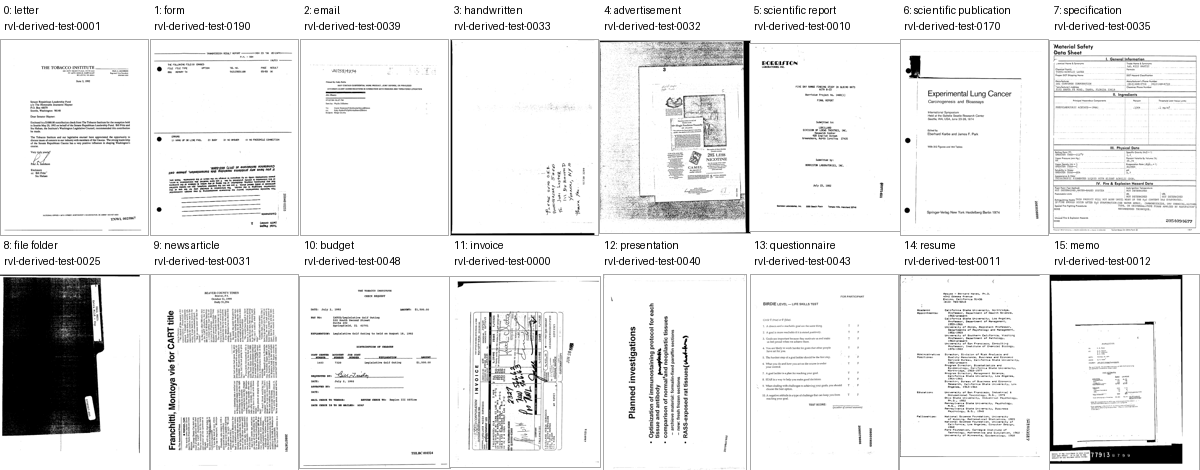

In [ ]:
from collections import Counter

LABELS = [
    "letter","form","email","handwritten","advertisement","scientific report",
    "scientific publication","specification","file folder","news article","budget",
    "invoice","presentation","questionnaire","resume","memo"
]
LABEL_TO_ID = {name:i for i,name in enumerate(LABELS)}

# Selection, decoding, validation and digests run in the isolated environment with the pinned Pillow.
# Each selected page comes back as a lossless RGB PNG; the kernel re-checks its pixel digest.
show_source("select_sample_indices", "build_sample")
run_stage("sample", dataset_id=DATASET_ID, dataset_revision=DATASET_REVISION)
sample = state("sample.json")
sample_digest = sample["sample_digest"]

sample_records = []
for r in sample["records"]:
    with Image.open(r["png"]) as opened:
        image = opened.convert("RGB")
    digest = hashlib.sha256(f"{image.width}x{image.height}:".encode() + image.tobytes()).hexdigest()
    if digest != r["pixel_sha256"]:
        raise RuntimeError(f"Page {r['image_id']} changed after sampling")
    sample_records.append({**r, "image": image})

counts = Counter(r["label_id"] for r in sample_records)
if len(sample_records) != 320 or set(counts.values()) != {20} or len(counts) != 16:
    raise RuntimeError(f"Balanced sample validation failed: {counts}")

print("Class counts:")
for i,name in enumerate(LABELS):
    print(f"  {i:>2} {name:<24} {counts[i]}")
print({"sample_images":len(sample_records), "sample_digest":sample_digest})

import math

def make_gallery(items, columns=4, thumb_size=(260,340), line_height=16):
    """Lay out (PIL image, [caption lines]) pairs as one annotated contact sheet."""
    n_lines = max((len(lines) for _image, lines in items), default=1)
    title_height = 8 + n_lines*line_height
    tile_w, tile_h = thumb_size[0], thumb_size[1] + title_height
    rows_n = max(1, math.ceil(len(items)/columns))
    canvas = Image.new("RGB", (columns*tile_w, rows_n*tile_h), "white")
    draw = ImageDraw.Draw(canvas)
    for idx,(image,lines) in enumerate(items):
        col,row = idx%columns, idx//columns
        img = image.convert("RGB").copy()
        img.thumbnail(thumb_size)
        x,y = col*tile_w, row*tile_h
        px, py = x+(thumb_size[0]-img.width)//2, y+title_height+(thumb_size[1]-img.height)//2
        canvas.paste(img, (px, py))
        draw.rectangle((px-1, py-1, px+img.width, py+img.height), outline=(170,170,170))
        for k,line in enumerate(lines):
            draw.text((x+4, y+4+k*line_height), str(line)[:40], fill="black")
    return canvas

# First selected page of each class (row order, never model output); gold labels only.
preview_records = [next(r for r in sample_records if r["label_id"] == c) for c in range(16)]
print("One page per class, before classification (gold label and image id):")
display(make_gallery(
    [(r["image"], [f"{r['label_id']}: {r['label']}", r["image_id"]]) for r in preview_records],
    columns=8, thumb_size=(150,195),
))


## 9. Classification baselines

The tutorial sample is exactly balanced.

### Uniform random expectation

`1 / 16 = 6.25%` expected top-1 accuracy.

### Majority baseline

Every class has the same support, so deterministic tie-breaking selects class ID 0: `letter`.

The majority baseline is intentionally trivial. It provides a classification floor, not a useful document system.

> **Before you run it:** predict whether this simple reference will be easy or difficult for the learned model(s) to beat. Record the baseline before interpreting the more complex result.

In [ ]:
true_ids = np.array([r["label_id"] for r in sample_records], dtype=int)
random_accuracy_expectation = 1.0 / len(LABELS)
majority_class_id = min(counts, key=lambda k: (-counts[k], k))
majority_predictions = np.full_like(true_ids, majority_class_id)
majority_accuracy = float(np.mean(majority_predictions == true_ids))

print({
    "random_accuracy_expectation": random_accuracy_expectation,
    "majority_class_id": int(majority_class_id),
    "majority_label": LABELS[majority_class_id],
    "majority_accuracy": majority_accuracy,
})

{'random_accuracy_expectation': 0.0625, 'majority_class_id': 0, 'majority_label': 'letter', 'majority_accuracy': 0.0625}


## 10. Load only the converted model for evaluation

The source pickle checkpoint has already served its only purpose: authenticated-by-digest local conversion.

The evaluation model is reconstructed from:

- `config.json`
- `preprocessor_config.json`
- `model.safetensors`

inside the converted local snapshot.

In [ ]:
# The model is loaded inside each stage process and released when that process ends;
# nothing is loaded into this kernel.
show_source("load_converted_model")
run_stage("load-check")
loaded = state("load_check.json")
model_load_seconds = loaded["model_load_seconds"]
parameter_count = loaded["parameter_count"]


```python
def load_converted_model():
    """Load only the converted SafeTensors snapshot; the source pickle is never used for evaluation."""
    from transformers import AutoImageProcessor, AutoModelForImageClassification

    processor = AutoImageProcessor.from_pretrained(str(CONVERTED_DIR), local_files_only=True)
    t0 = time.perf_counter()
    model = AutoModelForImageClassification.from_pretrained(
        str(CONVERTED_DIR),
        local_files_only=True,
    ).to(device()).eval()
    model_load_seconds = time.perf_counter() - t0
    config_labels = [model.config.id2label[i] for i in range(16)]
    if config_labels != LABELS:
        raise RuntimeError("Loaded class ordering differs from canonical RVL-CDIP order")
    return processor, model, model_load_seconds
```

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


/content/work/document_type_classification/env/lib/python3.12/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `BeitImageProcessor.__init__` and were ignored: 'reduce_labels'


  image_processor = cls(**image_processor_dict)


{'model_load_seconds': 0.6241065290000165, 'parameter_count': 85820176, 'class_count': 16, 'device': 'cuda:0'}


## 11. Whole-page inference

For every page, the processor creates the model's 224×224 view and the classifier returns 16 logits.

The notebook exports the complete 16-class softmax score vector and uses `argmax` as the decision rule. One ordering serves every table: classes are ranked by descending score, and equal scores keep the lower class ID first. Top-1 therefore equals `argmax`, top-3 always contains exactly three classes, and predictions, metrics, ranks, robustness and BYOD rows agree even when two scores tie.

Softmax scores are **normalized model scores over this fixed class set**, not calibrated probabilities of real-world correctness.

**Predict before running:** which two document types might share page-layout cues and be confused? Write a pair and a visual reason. After inference, compare your prediction with the confusion matrix and deterministic error gallery, not just overall accuracy.


In [ ]:
import tempfile

show_source("batched_predict")


def batched_predict(records, batch_size=BATCH_SIZE):
    """Score pages with the converted DiT model (the function above) in the isolated environment.

    Pages travel as lossless PNG files. A record with a "variant" is transformed there, and its
    "image" is replaced by the transformed page the model scored. Returns logits, softmax scores,
    per-batch forward seconds and peak GPU memory.
    """
    jobs = WORK_ROOT / "predict"
    jobs.mkdir(parents=True, exist_ok=True)
    job_dir = Path(tempfile.mkdtemp(prefix="job-", dir=jobs))
    items = []
    for k, r in enumerate(records):
        path = r.get("png")
        if path is None:
            path = job_dir / f"page-{k:04d}.png"
            r["image"].save(path, format="PNG")
        items.append({"path": str(path), "variant": r.get("variant")})
    (job_dir / "job.json").write_text(json.dumps({"batch_size": int(batch_size), "items": items}), encoding="utf-8")
    run_stage("predict", "--job", str(job_dir))
    result = read_json(job_dir / "result.json")
    for r, path in zip(records, result["scored_paths"], strict=True):
        if r.get("variant") is not None:
            with Image.open(path) as opened:
                r["image"] = opened.convert("RGB")
    logits, scores = np.load(job_dir / "logits.npy"), np.load(job_dir / "scores.npy")
    return logits, scores, result["timings"], result["peak_gpu_memory_bytes"]

def rank_classes(score_matrix):
    """Class IDs per row, highest score first; equal scores keep the lower class ID first.

    Column 0 equals np.argmax. Every prediction, top-k, rank and export uses this ordering.
    """
    score_matrix = np.atleast_2d(np.asarray(score_matrix))
    class_ids = np.arange(score_matrix.shape[1])
    return np.stack([np.lexsort((class_ids, -row)) for row in score_matrix])

logits, scores, inference_batch_times, peak_gpu_memory = batched_predict(sample_records)
score_order = rank_classes(scores)
pred_ids = score_order[:,0]
top3_ids = score_order[:,:3]
leading_scores = np.take_along_axis(scores, score_order[:,:2], axis=1)
top1_tied_pages = int(np.sum(leading_scores[:,0] == leading_scores[:,1]))

print({
    "pages": len(sample_records),
    "batches": len(inference_batch_times),
    "total_model_forward_seconds": float(sum(inference_batch_times)),
    "mean_batch_seconds": float(np.mean(inference_batch_times)),
    "peak_gpu_memory_bytes": peak_gpu_memory,
    "pages_with_tied_top1_score": top1_tied_pages,
})

```python
def batched_predict(processor, model, records, batch_size):
    import numpy as np
    import torch

    DEVICE = device()
    all_logits = []
    timings = []
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    # Warm-up.
    warm = processor(images=[records[0]["image"]], return_tensors="pt").to(DEVICE)
    with torch.inference_mode():
        _ = model(**warm).logits
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    for start in range(0, len(records), batch_size):
        batch_records = records[start:start+batch_size]
        inputs = processor(
            images=[r["image"] for r in batch_records],
            return_tensors="pt",
        ).to(DEVICE)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.inference_mode():
            logits = model(**inputs).logits
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        timings.append(time.perf_counter() - t0)
        if logits.shape != (len(batch_records), 16):
            raise RuntimeError(f"Unexpected logits shape: {tuple(logits.shape)}")
        if not torch.isfinite(logits).all():
            raise RuntimeError("Model produced non-finite logits")
        all_logits.append(logits.float().cpu())

    logits = torch.cat(all_logits, dim=0).numpy()
    scores = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
    if not np.allclose(scores.sum(axis=1), 1.0, atol=1e-5):
        raise RuntimeError("Softmax score rows do not sum approximately to 1")
    peak_gpu = torch.cuda.max_memory_allocated() if torch.cuda.is_available() else None
    return logits, scores, timings, peak_gpu
```

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


/content/work/document_type_classification/env/lib/python3.12/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `BeitImageProcessor.__init__` and were ignored: 'reduce_labels'


  image_processor = cls(**image_processor_dict)


{'pages': 320, 'batches': 20, 'device': 'cuda:0'}


{'pages': 320, 'batches': 20, 'total_model_forward_seconds': 3.0906277359999876, 'mean_batch_seconds': 0.1545313867999994, 'peak_gpu_memory_bytes': 498254848, 'pages_with_tied_top1_score': 0}


## 12. Principal metrics

We report three complementary classification measures:

- **Accuracy** — top-1 correctness.
- **Macro F1** — equal-weight F1 across all 16 classes.
- **Top-3 accuracy** — whether the gold class appears among the three highest scores (ties at rank three go to the lower class ID, so exactly three classes count).

The sample metrics are tutorial evidence on the pinned RVL-CDIP-derived subset, not reproduction of the original 40k official benchmark.

> **What to notice.** Compare the learned-model result with the baseline/reference first, then use the secondary diagnostics to explain the behavior. Do not infer a universal model ranking from one tutorial sample and configuration.

**Checkpoint:** could a high overall accuracy hide a weak class?

<details><summary>Sample interpretation</summary>
Yes. Inspect the per-class table printed below (weakest recall first) and macro-F1 alongside the overall score. Here the sample is balanced, but classes can still have very different recall. A small tutorial sample cannot establish general document performance.
</details>


In [ ]:
def confusion_matrix_np(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes,n_classes), dtype=int)
    for t,p in zip(y_true,y_pred,strict=True):
        cm[int(t),int(p)] += 1
    return cm

def per_class_metrics_from_cm(cm):
    rows = []
    for i in range(cm.shape[0]):
        tp = cm[i,i]
        fp = cm[:,i].sum() - tp
        fn = cm[i,:].sum() - tp
        support = cm[i,:].sum()
        precision = tp/(tp+fp) if tp+fp else 0.0
        recall = tp/(tp+fn) if tp+fn else 0.0
        f1 = 2*precision*recall/(precision+recall) if precision+recall else 0.0
        rows.append({
            "class_id": i,
            "class_label": LABELS[i],
            "support": int(support),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
        })
    return rows

cm = confusion_matrix_np(true_ids, pred_ids, 16)
class_metrics = per_class_metrics_from_cm(cm)
accuracy = float(np.mean(pred_ids == true_ids))
macro_f1 = float(np.mean([r["f1"] for r in class_metrics]))
top3_accuracy = float(np.mean([
    int(true_ids[i]) in set(int(x) for x in top3_ids[i])
    for i in range(len(true_ids))
]))

for i,row in enumerate(class_metrics):
    row["top3_recall"] = float(np.mean([
        i in set(int(x) for x in top3_ids[j])
        for j in range(len(true_ids))
        if true_ids[j] == i
    ]))

metrics = {
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "top3_accuracy": top3_accuracy,
    "random_accuracy_expectation": random_accuracy_expectation,
    "majority_accuracy": majority_accuracy,
}
print(metrics)

print("\nPer-class metrics, weakest recall first:")
print(f"{'class':<24} {'support':>7} {'precision':>9} {'recall':>7} {'f1':>6} {'top3_recall':>11}")
for row in sorted(class_metrics, key=lambda r: (r["recall"], r["class_id"])):
    print(
        f"{row['class_label']:<24} {row['support']:>7} {row['precision']:>9.3f} "
        f"{row['recall']:>7.3f} {row['f1']:>6.3f} {row['top3_recall']:>11.3f}"
    )


{'accuracy': 0.953125, 'macro_f1': 0.9530115891276032, 'top3_accuracy': 0.99375, 'random_accuracy_expectation': 0.0625, 'majority_accuracy': 0.0625}

Per-class metrics, weakest recall first:
class                    support precision  recall     f1 top3_recall
scientific report             20     0.850   0.850  0.850       1.000
presentation                  20     0.850   0.850  0.850       1.000
letter                        20     1.000   0.900  0.947       0.950
form                          20     0.947   0.900  0.923       1.000
handwritten                   20     1.000   0.900  0.947       0.950
scientific publication        20     0.950   0.950  0.950       1.000
news article                  20     0.950   0.950  0.950       1.000
budget                        20     0.950   0.950  0.950       1.000
email                         20     1.000   1.000  1.000       1.000
advertisement                 20     0.909   1.000  0.952       1.000
specification                 20     1.

## 13. Confusion matrix and prediction

Before reading the matrix, consider which page types you expect to be visually confusable.

Possible hypotheses include:

- scientific report ↔ scientific publication;
- letter ↔ memo;
- form ↔ questionnaire;
- budget ↔ invoice.

These are only hypotheses. The next cell reports the actual measured confusions.

In [ ]:
print("Raw confusion matrix (rows=gold, columns=prediction):")
header = "      " + " ".join(f"{i:>3}" for i in range(16))
print(header)
for i,row in enumerate(cm):
    print(f"{i:>3} {LABELS[i][:14]:<14} " + " ".join(f"{int(v):>3}" for v in row))

off_diagonal = []
for i in range(16):
    for j in range(16):
        if i != j and cm[i,j] > 0:
            off_diagonal.append((int(cm[i,j]), i, j))
off_diagonal.sort(reverse=True)

print("\nStrongest measured confusion pairs:")
for count,i,j in off_diagonal[:10]:
    print(f"  {LABELS[i]} -> {LABELS[j]}: {count}")

Raw confusion matrix (rows=gold, columns=prediction):
        0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15
  0 letter          18   1   0   0   0   0   0   0   0   0   0   0   1   0   0   0
  1 form             0  18   0   0   0   1   0   0   0   0   1   0   0   0   0   0
  2 email            0   0  20   0   0   0   0   0   0   0   0   0   0   0   0   0
  3 handwritten      0   0   0  18   0   0   0   0   0   0   0   0   0   2   0   0
  4 advertisement    0   0   0   0  20   0   0   0   0   0   0   0   0   0   0   0
  5 scientific rep   0   0   0   0   1  17   0   0   0   0   0   0   2   0   0   0
  6 scientific pub   0   0   0   0   0   0  19   0   0   1   0   0   0   0   0   0
  7 specification    0   0   0   0   0   0   0  20   0   0   0   0   0   0   0   0
  8 file folder      0   0   0   0   0   0   0   0  20   0   0   0   0   0   0   0
  9 news article     0   0   0   0   1   0   0   0   0  19   0   0   0   0   0   0
 10 budget           0   0   0   0   0   0   0

## 14. Error analysis

For each page we calculate:

- top-1 score;
- top-2 score;
- top-1/top-2 margin;
- score entropy;
- correctness.

We then surface:

- highest-score incorrect predictions;
- smallest-margin predictions;
- correct pages with the smallest margins.

A high model score is not proof of correctness.

In [ ]:
eps = 1e-12
prediction_rows = []

for i,record in enumerate(sample_records):
    order = score_order[i]
    top1, top2, top3 = [int(x) for x in order[:3]]
    entropy = float(-np.sum(scores[i] * np.log(np.maximum(scores[i], eps))))
    row = {
        "image_id": record["image_id"],
        "source_row_index": record["source_row_index"],
        "true_label": record["label"],
        "true_class_id": record["label_id"],
        "predicted_class_id": top1,
        "predicted_label": LABELS[top1],
        "correct": bool(top1 == record["label_id"]),
        "top1_score": float(scores[i,top1]),
        "top2_label": LABELS[top2],
        "top2_score": float(scores[i,top2]),
        "top3_label": LABELS[top3],
        "top3_score": float(scores[i,top3]),
        "margin": float(scores[i,top1] - scores[i,top2]),
        "entropy": entropy,
    }
    prediction_rows.append(row)

high_conf_wrong = sorted(
    [r for r in prediction_rows if not r["correct"]],
    key=lambda r: -r["top1_score"],
)[:8]
low_margin = sorted(prediction_rows, key=lambda r:r["margin"])[:8]
correct_uncertain = sorted(
    [r for r in prediction_rows if r["correct"]],
    key=lambda r:r["margin"],
)[:8]

print("High-confidence incorrect:")
for r in high_conf_wrong:
    print(f"  {r['image_id']}: gold={r['true_label']} pred={r['predicted_label']} score={r['top1_score']:.3f} margin={r['margin']:.3f}")

print("\nLowest margins:")
for r in low_margin:
    print(f"  {r['image_id']}: gold={r['true_label']} pred={r['predicted_label']} margin={r['margin']:.4f}")

High-confidence incorrect:
  rvl-derived-test-0123: gold=presentation pred=scientific report score=0.896 margin=0.883
  rvl-derived-test-0960: gold=news article pred=advertisement score=0.888 margin=0.856
  rvl-derived-test-0908: gold=letter pred=presentation score=0.839 margin=0.808
  rvl-derived-test-0436: gold=scientific report pred=presentation score=0.833 margin=0.787
  rvl-derived-test-0319: gold=handwritten pred=questionnaire score=0.815 margin=0.775
  rvl-derived-test-0628: gold=form pred=budget score=0.797 margin=0.682
  rvl-derived-test-0861: gold=presentation pred=scientific publication score=0.765 margin=0.627
  rvl-derived-test-0139: gold=handwritten pred=questionnaire score=0.761 margin=0.609

Lowest margins:
  rvl-derived-test-0244: gold=budget pred=memo margin=0.0090
  rvl-derived-test-0504: gold=scientific report pred=presentation margin=0.0437
  rvl-derived-test-0411: gold=scientific report pred=scientific report margin=0.1331
  rvl-derived-test-0852: gold=presentatio

## 15. Deterministic robustness probe

The robustness probe uses one page per class, selected only by the original sample-selection ranking key.

Each probe keeps the same ground-truth class while the visual evidence changes.

Variants:

- original;
- rotate 90° clockwise;
- rotate 180°;
- low resolution (downsample to 112×112, then re-upsample);
- center crop retaining 80% of width and height.

These transformations measure stability. They are not production preprocessing recommendations.

In [ ]:
# Reconstruct the deterministic ranking key used during selection and pick the first sample per class.
def selection_key(record):
    idx = record["source_row_index"]
    label_id = record["label_id"]
    return hashlib.sha256(f"{SAMPLE_SEED}:{idx}:{label_id}".encode()).hexdigest()

robustness_base = []
for label_id in range(16):
    candidates = [r for r in sample_records if r["label_id"] == label_id]
    robustness_base.append(min(candidates, key=selection_key))

print("Robustness probe:")
for r in robustness_base:
    print(f"  {r['label_id']:>2} {r['label']:<24} {r['image_id']}")

Robustness probe:
   0 letter                   rvl-derived-test-0587
   1 form                     rvl-derived-test-0775
   2 email                    rvl-derived-test-0270
   3 handwritten              rvl-derived-test-0319
   4 advertisement            rvl-derived-test-0141
   5 scientific report        rvl-derived-test-0928
   6 scientific publication   rvl-derived-test-0521
   7 specification            rvl-derived-test-0063
   8 file folder              rvl-derived-test-0865
   9 news article             rvl-derived-test-0901
  10 budget                   rvl-derived-test-0298
  11 invoice                  rvl-derived-test-0465
  12 presentation             rvl-derived-test-0861
  13 questionnaire            rvl-derived-test-0413
  14 resume                   rvl-derived-test-0213
  15 memo                     rvl-derived-test-0272


## 16. Rotation, resolution and crop experiments

The same classifier and processor are used for every variant. Only the input page image changes.

**Predict before running:** will rotating the same page by 90 degrees hurt more than downsampling it? Give a layout-based reason. `RUN_ROBUSTNESS=False` skips all transformed-model calls and exports an empty robustness table. With the default enabled, compare each variant against the original for exactly the same 16 pages. After the summary, the cell lists every page whose predicted class changed and shows one deterministic original/transformed pair (the first changed `rotate90` page, otherwise the first changed page, otherwise the first `rotate90` page). No changed page is a legitimate outcome and is reported as such.


```python
def transform_variant(image, variant):
    from PIL import Image

    image = image.convert("RGB")
    if variant == "original":
        return image
    if variant == "rotate90":
        return image.rotate(-90, expand=True, fillcolor="white")
    if variant == "rotate180":
        return image.rotate(180, expand=True, fillcolor="white")
    if variant == "low_resolution":
        low = image.resize((112,112), Image.Resampling.BILINEAR)
        return low.resize(image.size, Image.Resampling.BILINEAR)
    if variant == "center_crop":
        w,h = image.size
        cw,ch = int(w*0.8), int(h*0.8)
        x0,y0 = (w-cw)//2, (h-ch)//2
        return image.crop((x0,y0,x0+cw,y0+ch))
    raise ValueError(variant)
```

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


/content/work/document_type_classification/env/lib/python3.12/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `BeitImageProcessor.__init__` and were ignored: 'reduce_labels'


  image_processor = cls(**image_processor_dict)


{'pages': 80, 'batches': 5, 'device': 'cuda:0'}


Variant            Accuracy  Stability  Gold score    Margin
original              0.812      1.000       0.745     0.846
rotate90              0.500      0.625       0.438     0.556
rotate180             0.688      0.875       0.625     0.843
low_resolution        0.750      0.938       0.723     0.766
center_crop           0.812      1.000       0.751     0.838

Pages whose predicted class changed from the original:
image_id                 gold                   variant         original pred          variant pred           gold score
rvl-derived-test-0319    handwritten            rotate90        questionnaire          form                        0.029
rvl-derived-test-0141    advertisement          rotate90        advertisement          questionnaire               0.016
rvl-derived-test-0141    advertisement          low_resolution  advertisement          handwritten                 0.158
rvl-derived-test-0901    news article           rotate90        news article           email  

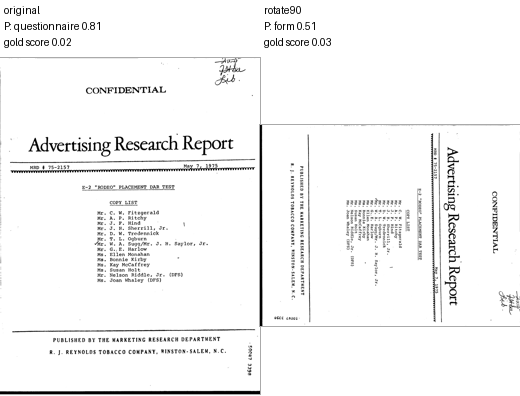

In [ ]:
ROBUSTNESS_VARIANTS = ["original","rotate90","rotate180","low_resolution","center_crop"]

robustness_rows = []
robustness_summary = {}
robust_records = []
changed_rows = []
if RUN_ROBUSTNESS:
    # Each variant is made in the isolated environment (pinned Pillow) just before scoring.
    show_source("transform_variant")
    robust_records = []
    for base in robustness_base:
        for variant in ROBUSTNESS_VARIANTS:
            robust_records.append({
                **{k:v for k,v in base.items() if k != "image"},
                "variant": variant,
                "image": base["image"],  # replaced by the scored, transformed page
            })

    robust_logits, robust_scores, _robust_times, _ = batched_predict(robust_records, batch_size=16)
    robust_order = rank_classes(robust_scores)

    robustness_rows = []
    original_prediction_by_id = {}

    for i,r in enumerate(robust_records):
        order = robust_order[i]
        top1,top2 = int(order[0]),int(order[1])
        if r["variant"] == "original":
            original_prediction_by_id[r["image_id"]] = top1
        robustness_rows.append({
            "image_id": r["image_id"],
            "gold_label": r["label"],
            "gold_class_id": r["label_id"],
            "variant": r["variant"],
            "predicted_label": LABELS[top1],
            "predicted_class_id": top1,
            "correct": bool(top1 == r["label_id"]),
            "top1_score": float(robust_scores[i,top1]),
            "gold_score": float(robust_scores[i,r["label_id"]]),
            "margin": float(robust_scores[i,top1] - robust_scores[i,top2]),
        })

    for row in robustness_rows:
        row["same_as_original_prediction"] = (
            row["predicted_class_id"] == original_prediction_by_id[row["image_id"]]
        )

    robustness_summary = {}
    for variant in ROBUSTNESS_VARIANTS:
        rows = [r for r in robustness_rows if r["variant"] == variant]
        robustness_summary[variant] = {
            "accuracy": float(np.mean([r["correct"] for r in rows])),
            "stability_vs_original": float(np.mean([r["same_as_original_prediction"] for r in rows])),
            "mean_gold_score": float(np.mean([r["gold_score"] for r in rows])),
            "mean_margin": float(np.mean([r["margin"] for r in rows])),
        }

    print(f"{'Variant':<16} {'Accuracy':>10} {'Stability':>10} {'Gold score':>11} {'Margin':>9}")
    for variant,summary in robustness_summary.items():
        print(
            f"{variant:<16} {summary['accuracy']:>10.3f} {summary['stability_vs_original']:>10.3f} "
            f"{summary['mean_gold_score']:>11.3f} {summary['mean_margin']:>9.3f}"
        )

    original_row_by_id = {r["image_id"]: r for r in robustness_rows if r["variant"] == "original"}
    changed_rows = [r for r in robustness_rows if not r["same_as_original_prediction"]]
    print("\nPages whose predicted class changed from the original:")
    if changed_rows:
        print(f"{'image_id':<24} {'gold':<22} {'variant':<15} {'original pred':<22} {'variant pred':<22} {'gold score':>10}")
        for r in changed_rows:
            before = original_row_by_id[r["image_id"]]
            print(
                f"{r['image_id']:<24} {r['gold_label']:<22} {r['variant']:<15} "
                f"{before['predicted_label']:<22} {r['predicted_label']:<22} {r['gold_score']:>10.3f}"
            )
    else:
        print("  none: every page kept its original prediction under every variant.")

    example = next((r for r in changed_rows if r["variant"] == "rotate90"), None)
    if example is None:
        example = changed_rows[0] if changed_rows else next(r for r in robustness_rows if r["variant"] == "rotate90")
    before = original_row_by_id[example["image_id"]]
    image_by_key = {(r["image_id"], r["variant"]): r["image"] for r in robust_records}
    print(f"\nBefore/after example: {example['image_id']} (gold: {example['gold_label']}), {example['variant']}")
    display(make_gallery([
        (image_by_key[(example["image_id"], "original")],
         ["original", f"P: {before['predicted_label']} {before['top1_score']:.2f}",
          f"gold score {before['gold_score']:.2f}"]),
        (image_by_key[(example["image_id"], example["variant"])],
         [example["variant"], f"P: {example['predicted_label']} {example['top1_score']:.2f}",
          f"gold score {example['gold_score']:.2f}"]),
    ], columns=2))
else:
    print("Robustness disabled; exports contain an empty robustness table and summary.")


## 17. Confidence, margins and optional selective classification

The notebook exposes scores, margins and entropy as diagnostics, but does not define a universal rejection threshold.

An optional experiment can measure the trade-off between **coverage** and **accuracy among retained pages** as the top-1/top-2 margin threshold increases.

This is exploratory calibration behavior on the tutorial sample, not a deployment threshold recommendation.

In [ ]:
selective_rows = []
if RUN_SELECTIVE_CLASSIFICATION:
    for threshold in (0.0,0.05,0.10,0.20,0.30,0.50):
        kept = [r for r in prediction_rows if r["margin"] >= threshold]
        selective_rows.append({
            "margin_threshold": threshold,
            "coverage": len(kept)/len(prediction_rows),
            "accuracy_if_retained": (
                float(np.mean([r["correct"] for r in kept])) if kept else None
            ),
            "n_retained": len(kept),
        })
    for r in selective_rows:
        print(r)
else:
    print("Selective-classification experiment disabled on the canonical path.")

Selective-classification experiment disabled on the canonical path.


## 18. Visual galleries

The first gallery contains one deterministic page per class.

The second contains the highest-confidence incorrect predictions available in the sample.

Each thumbnail is annotated with the gold class (G), predicted class and top-1 score (P), and image ID. Both galleries are displayed below and saved under `galleries/`. If the sample has no incorrect predictions, the error gallery is omitted and any copy left by an earlier run is removed.

Class gallery, one page per class: outputs/document_type_classification/galleries/class_gallery.png


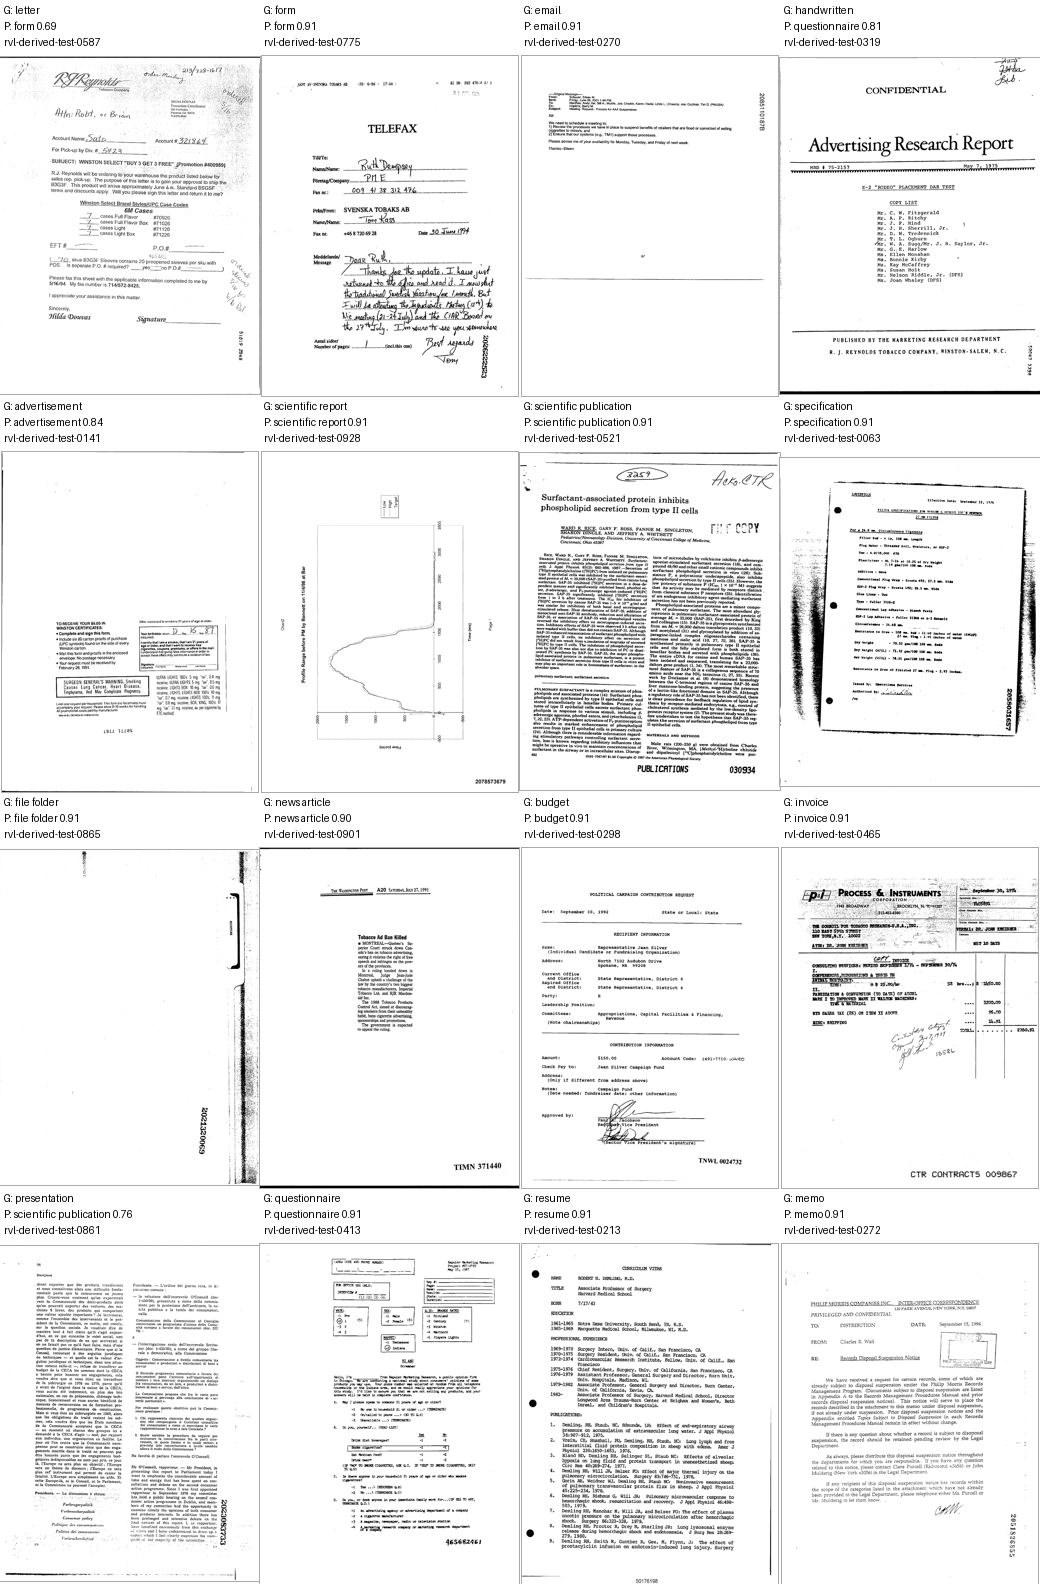

Highest-score incorrect predictions: outputs/document_type_classification/galleries/high_confidence_errors.png


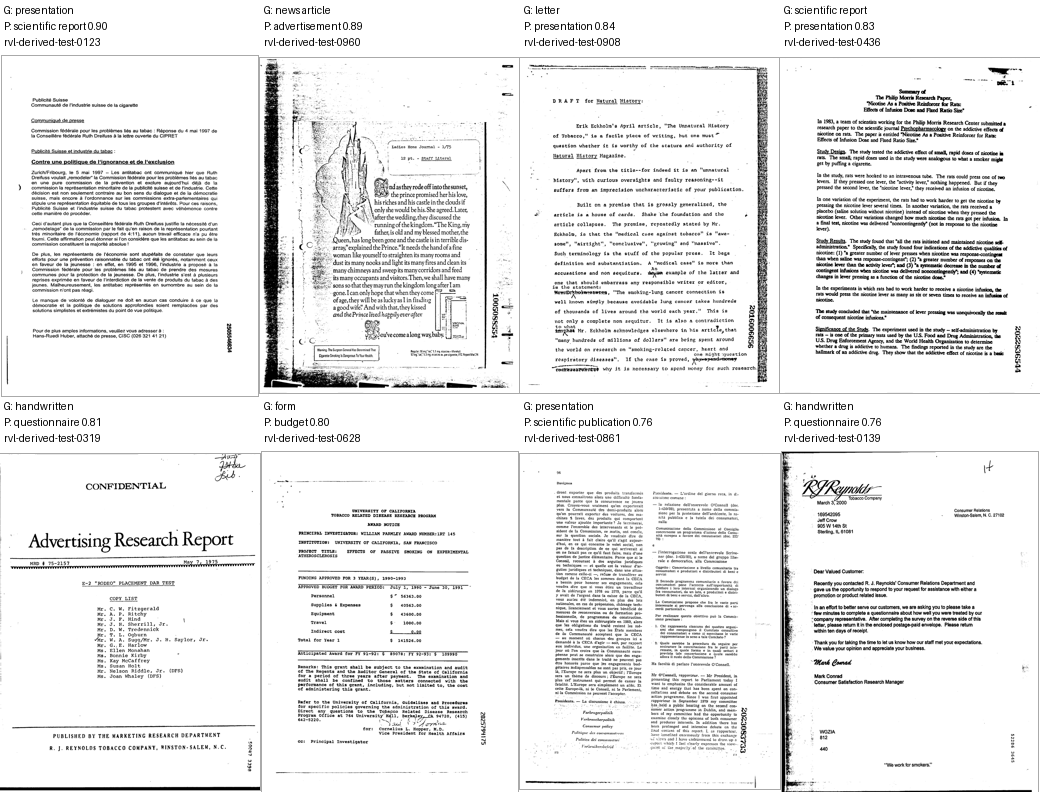

In [ ]:
record_by_id = {r["image_id"]:r for r in sample_records}
pred_by_id = {r["image_id"]:r for r in prediction_rows}

def gallery_caption(row):
    return [
        f"G: {row['true_label']}",
        f"P: {row['predicted_label']} {row['top1_score']:.2f}",
        row["image_id"],
    ]

class_gallery_items = [
    (base["image"], gallery_caption(pred_by_id[base["image_id"]]))
    for base in robustness_base
]
error_gallery_items = [
    (record_by_id[r["image_id"]]["image"], gallery_caption(r))
    for r in high_conf_wrong
]

out_dir = Path(OUTPUT_DIR)
gallery_dir = out_dir / "galleries"
gallery_dir.mkdir(parents=True, exist_ok=True)

class_gallery = make_gallery(class_gallery_items, columns=4)
class_gallery_path = gallery_dir / "class_gallery.png"
class_gallery.save(class_gallery_path)
print(f"Class gallery, one page per class: {class_gallery_path}")
display(class_gallery)

error_gallery_path = gallery_dir / "high_confidence_errors.png"
if error_gallery_items:
    error_gallery = make_gallery(error_gallery_items, columns=4)
    error_gallery.save(error_gallery_path)
    print(f"Highest-score incorrect predictions: {error_gallery_path}")
    display(error_gallery)
else:
    # An earlier run's error gallery must not pass as evidence from this run.
    error_gallery_path.unlink(missing_ok=True)
    error_gallery_path = None
    print("No incorrect predictions in this sample; no error gallery was produced.")

## 19. Machine-readable outputs and provenance

The notebook exports:

- `predictions.csv`
- `class_scores.csv`
- `class_metrics.csv`
- `confusion_matrix.csv`
- `robustness.csv`
- `input_manifest.json`
- `metrics.json`
- `provenance.json`
- gallery PNGs

The cell lists exactly the files this run wrote. Any other file in the output folder (from an earlier run or the optional BYOD branch) is listed separately.

The provenance distinguishes the upstream pickle source asset from the derived SafeTensors file used for evaluation.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [ ]:
import csv
from datetime import datetime, timezone

out_dir.mkdir(parents=True, exist_ok=True)

def write_csv(path, rows, fieldnames):
    with open(path, "w", encoding="utf-8", newline="") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        for row in rows:
            w.writerow({k:row.get(k) for k in fieldnames})

write_csv(
    out_dir/"predictions.csv",
    prediction_rows,
    [
        "image_id","source_row_index","true_label","true_class_id","predicted_class_id",
        "predicted_label","correct","top1_score","top2_label","top2_score","top3_label",
        "top3_score","margin","entropy"
    ],
)

class_score_rows = []
for i,record in enumerate(sample_records):
    order = score_order[i]
    rank_by_class = {int(cls):rank+1 for rank,cls in enumerate(order)}
    for class_id,label in enumerate(LABELS):
        class_score_rows.append({
            "image_id": record["image_id"],
            "class_id": class_id,
            "class_label": label,
            "score": float(scores[i,class_id]),
            "rank": rank_by_class[class_id],
        })

if len(class_score_rows) != len(sample_records)*16:
    raise RuntimeError("class_scores export does not contain exactly 16 rows per page")

write_csv(
    out_dir/"class_scores.csv",
    class_score_rows,
    ["image_id","class_id","class_label","score","rank"],
)

write_csv(
    out_dir/"class_metrics.csv",
    class_metrics,
    ["class_id","class_label","support","precision","recall","f1","top3_recall"],
)

cm_rows = []
for gold_id in range(16):
    row = {"gold_class_id":gold_id,"gold_label":LABELS[gold_id]}
    for pred_id in range(16):
        row[f"pred_{pred_id}"] = int(cm[gold_id,pred_id])
    cm_rows.append(row)
write_csv(
    out_dir/"confusion_matrix.csv",
    cm_rows,
    ["gold_class_id","gold_label"] + [f"pred_{i}" for i in range(16)],
)

write_csv(
    out_dir/"robustness.csv",
    robustness_rows,
    [
        "image_id","gold_label","gold_class_id","variant","predicted_label","predicted_class_id",
        "correct","top1_score","gold_score","margin","same_as_original_prediction"
    ],
)

input_manifest = {
    "schema": {
        "unit": "one document page image",
        "image_side_px": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],
        "max_pixels": MAX_PIXELS,
        "classes": LABELS,
        "decision_rule": "argmax over 16 logits; equal scores rank the lower class ID first (top-1, top-k and ranks)",
    },
    "sample": {
        "images": len(sample_records),
        "class_counts": {LABELS[i]:counts[i] for i in range(16)},
        "min_width": min(r["width"] for r in sample_records),
        "max_width": max(r["width"] for r in sample_records),
        "min_height": min(r["height"] for r in sample_records),
        "max_height": max(r["height"] for r in sample_records),
    },
    "verdict": "accepted",
    "findings": [
        "rejection probe: a synthetic 16x16 image would fail MIN_IMAGE_SIDE=32"
    ],
}
(out_dir/"input_manifest.json").write_text(json.dumps(input_manifest, indent=2), encoding="utf-8")

metrics_export = {
    **metrics,
    "pages_with_tied_top1_score": top1_tied_pages,
    "per_class": class_metrics,
    "confusion_matrix": cm.tolist(),
    "strongest_confusions": [
        {"count":count,"gold":LABELS[i],"predicted":LABELS[j]}
        for count,i,j in off_diagonal[:10]
    ],
    "robustness": robustness_summary,
    "selective_classification": selective_rows,
    "timing": {
        "model_load_seconds": model_load_seconds,
        "batch_forward_seconds": inference_batch_times,
        "total_forward_seconds": float(sum(inference_batch_times)),
    },
}
(out_dir/"metrics.json").write_text(json.dumps(metrics_export, indent=2), encoding="utf-8")

provenance = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "notebook_spec": "2.2",
    "notebook": {
        "repository": "kurtvalcorza/dit-document-classification-pipeline",
        "path": "tutorials/DIMER_Document_Type_Classification_RVL_CDIP_Workshop.ipynb",
        "revision_note": "The executing commit is not visible inside the kernel; record it with the executed notebook.",
    },
    "profile": "TASK-INFERENCE",
    "pedagogical_mode": "WORKSHOP",
    "standalone": True,
    "model": {
        "id": MODEL_ID,
        "revision": MODEL_REVISION,
        "class_order": LABELS,
        "parameter_count": parameter_count,
        "source_asset": {
            "file": "pytorch_model.bin",
            "bytes": source_bin.stat().st_size,
            "sha256": SOURCE_BIN_SHA256,
            "serialization": "PyTorch pickle; verified then loaded with weights_only=True",
        },
        "derived_asset": {
            "file": "model.safetensors",
            "bytes": converted_path.stat().st_size,
            "sha256": converted_sha256,
            "derived_from_sha256": SOURCE_BIN_SHA256,
        },
        "conversion_parity_max_abs_logit_diff": max_abs_logit_diff,
        "config_sha256": config_digest,
        "preprocessor_sha256": processor_digest,
        "redistribution_status": "pending-review",
        "hosting_status": "HOLD",
    },
    "dataset": {
        "id": DATASET_ID,
        "revision": DATASET_REVISION,
        "source_description": "balanced RVL-CDIP-derived dataset; test split contains 992 images / 62 per class",
        "sample_kind": "balanced RVL-CDIP-derived test tutorial subset",
        "sample_seed": SAMPLE_SEED,
        "sample_per_class": SAMPLE_PER_CLASS,
        "sample_images": len(sample_records),
        "sample_digest": sample_digest,
        "evaluation_limitations": [
            "Not the official 40,000-image RVL-CDIP test split; not comparable with published official-test results.",
            "Every page is an IIT-CDIP image and so overlaps DiT's pre-training corpus.",
            "Overlap with the RVL-CDIP fine-tuning split cannot be ruled out; accuracy may be optimistic.",
        ],
        "sample_manifest": [
            {
                "image_id":r["image_id"],
                "source_row_index":r["source_row_index"],
                "class_id":r["label_id"],
                "class_label":r["label"],
                "width":r["width"],
                "height":r["height"],
                "source_bytes_sha256":r["source_bytes_sha256"],
                "pixel_sha256":r["pixel_sha256"],
            }
            for r in sample_records
        ],
    },
    "runtime": RUNTIME,
    "device": DEVICE,
}
(out_dir/"provenance.json").write_text(json.dumps(provenance, indent=2), encoding="utf-8")

run_outputs = [out_dir/name for name in (
    "predictions.csv", "class_scores.csv", "class_metrics.csv", "confusion_matrix.csv",
    "robustness.csv", "input_manifest.json", "metrics.json", "provenance.json",
)]
run_outputs += [p for p in (class_gallery_path, error_gallery_path) if p is not None]
print("Exports written by this run:")
for p in run_outputs:
    print(" ", p)
other_files = sorted(p for p in out_dir.rglob("*") if p.is_file() and p not in set(run_outputs))
if other_files:
    print("Other files in this folder, not written by this cell (earlier runs or the BYOD branch):")
    for p in other_files:
        print(" ", p)

Exports written by this run:
  outputs/document_type_classification/predictions.csv
  outputs/document_type_classification/class_scores.csv
  outputs/document_type_classification/class_metrics.csv
  outputs/document_type_classification/confusion_matrix.csv
  outputs/document_type_classification/robustness.csv
  outputs/document_type_classification/input_manifest.json
  outputs/document_type_classification/metrics.json
  outputs/document_type_classification/provenance.json
  outputs/document_type_classification/galleries/class_gallery.png
  outputs/document_type_classification/galleries/high_confidence_errors.png


## 20. Bring Your Own Document Pages (optional)

BYOD is disabled on the canonical path.

Accepted input:

- one single-page image file (multi-page TIFFs and animated images are rejected: save one file per page);
- a directory of page images; or
- a ZIP containing page images.

Optional `labels.csv`:

`filename,label`

Labels must be one of the fixed 16 RVL-CDIP classes.

If labels are absent, the notebook reports predictions only and the evaluation verdict is `not-measurable`.

### Privacy

Document images can contain names, addresses, signatures, financial information, proprietary records, and personal correspondence. Do not upload restricted, confidential, personal, or regulated documents to a hosted notebook environment unless you are authorized to process them there.

**Input limits:** 1–200 page images, sides 32–4096 pixels and at most 32,000,000 pixels per page; ZIP expanded size at most 512 MiB. ZIP basenames must be unique even across folders; each attempt extracts to a new directory so prior pages cannot leak into the input. PDFs must first be rendered to page images.

When a labels CSV is supplied, it must contain exactly one valid label for every selected filename: duplicate column names, rows with the wrong number of fields, and duplicate, missing or extra names are rejected before inference. Without the CSV, all pages are prediction-only. Image IDs include the filename extension. The branch prints a filename-to-prediction table and writes separate `byod_results.json`, `byod_predictions.csv` and `byod_class_scores.csv` (all 16 scores and ranks per page), with per-image and optional ZIP/labels digests, model revision and runtime. With labels, macro F1 keeps the notebook's fixed-16-class definition: classes absent from your pages still count in the average, so one correct page gives accuracy 1.0 but macro F1 0.0625. The per-class support table shows which classes your pages actually cover. Supplied pages remain in this runtime; no DIMER service is used.


In [ ]:
import zipfile
import tempfile
import io

BYOD_EXTENSIONS = {".png",".jpg",".jpeg",".webp",".tif",".tiff"}

def safe_extract_images(zip_path, dest):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        expanded = 0
        members = []
        seen = set()
        for info in zf.infolist():
            name = info.filename.replace("\\", "/")
            parts = [part for part in name.split("/") if part]
            if info.is_dir():
                continue
            if name.startswith("/") or ".." in parts or any(":" in part for part in parts):
                raise ValueError(f"Unsafe ZIP member: {name}")
            mode = (info.external_attr >> 16) & 0o170000
            if mode == 0o120000:
                raise ValueError(f"Symlink ZIP member refused: {name}")
            expanded += info.file_size
            if expanded > 512*1024*1024:
                raise ValueError("BYOD ZIP exceeds 512 MiB expanded-size ceiling")
            if Path(name).suffix.lower() in BYOD_EXTENSIONS:
                basename = Path(name).name
                if basename.casefold() in seen:
                    raise ValueError(f"Duplicate image basename in ZIP: {basename}")
                seen.add(basename.casefold())
                members.append((info, basename))
        if not 1 <= len(members) <= 200:
            raise ValueError("BYOD ZIP must contain 1..200 page images")
        # Unique directory per attempt; never mix prior runs or overwrite their files.
        extraction = Path(tempfile.mkdtemp(prefix="pages-", dir=dest))
        for info, basename in members:
            (extraction / basename).write_bytes(zf.read(info))
    return extraction

def validate_byod_image(path):
    # Page count and header dimensions are checked before any pixel data is decoded.
    with Image.open(path) as opened:
        frames = getattr(opened, "n_frames", 1)
        # Phone JPEGs often open as MPO; extra MPO frames are previews/depth maps, not pages.
        if frames != 1 and opened.format != "MPO":
            raise ValueError(
                f"{path.name}: contains {frames} pages/frames; this notebook classifies one page per file. "
                "Save each page as its own image file and retry."
            )
        width, height = opened.size
        if not (MIN_IMAGE_SIDE <= min(width, height) and max(width, height) <= MAX_IMAGE_SIDE):
            raise ValueError(f"{path.name}: side outside {MIN_IMAGE_SIDE}..{MAX_IMAGE_SIDE}")
        if width*height > MAX_PIXELS:
            raise ValueError(f"{path.name}: exceeds {MAX_PIXELS} pixels")
        opened.load()
        return opened.convert("RGB")

byod_result = None
if USE_BYOD:
    source = Path(BYOD_PATH)
    if source.is_file() and source.suffix.lower() == ".zip":
        image_root = safe_extract_images(source, Path("byod_document_pages"))
        image_paths = sorted(p for p in image_root.iterdir() if p.is_file() and p.suffix.lower() in BYOD_EXTENSIONS)
    elif source.is_dir():
        image_paths = sorted(p for p in source.iterdir() if p.is_file() and p.suffix.lower() in BYOD_EXTENSIONS)
    elif source.is_file() and source.suffix.lower() in BYOD_EXTENSIONS:
        image_paths = [source]
    else:
        raise FileNotFoundError("BYOD_PATH must be an image, image directory, or ZIP")

    if not 1 <= len(image_paths) <= 200:
        raise ValueError("BYOD accepts 1..200 page images")

    image_names = [p.name for p in image_paths]
    if len({name.casefold() for name in image_names}) != len(image_names):
        raise ValueError("BYOD image filenames must be unique (case-insensitive)")
    image_digests = {p.name: sha256_file(p) for p in image_paths}
    labels_digest = None
    labels_by_name = {}
    if BYOD_LABELS_PATH:
        labels_bytes = Path(BYOD_LABELS_PATH).read_bytes()
        labels_digest = hashlib.sha256(labels_bytes).hexdigest()
        reader = csv.DictReader(io.StringIO(labels_bytes.decode("utf-8-sig")))
        rows = list(reader)
        header = [(name or "").strip().casefold() for name in (reader.fieldnames or [])]
        if len(set(header)) != len(header):
            raise ValueError(f"labels.csv has duplicate column names: {reader.fieldnames}")
        if not rows or not {"filename", "label"}.issubset(reader.fieldnames or []):
            raise ValueError("labels.csv must contain filename,label and one row per image")
        for row_number, row in enumerate(rows, start=1):
            if None in row or any(value is None for value in row.values()):
                raise ValueError(f"labels.csv data row {row_number} does not have exactly {len(header)} fields")
        seen_label_names = set()
        for row in rows:
            filename = (row.get("filename") or "").strip()
            label = (row.get("label") or "").strip().lower()
            if not filename or filename.casefold() in seen_label_names:
                raise ValueError(f"Duplicate or empty label filename: {filename!r}")
            seen_label_names.add(filename.casefold())
            if label not in LABEL_TO_ID:
                raise ValueError(f"Unknown RVL-CDIP label {label!r}")
            labels_by_name[filename] = label
        missing = sorted(set(image_names) - set(labels_by_name))
        extra = sorted(set(labels_by_name) - set(image_names))
        if missing or extra:
            raise ValueError(f"Label filenames must match images exactly; missing={missing}, extra={extra}")

    byod_records = []
    for p in image_paths:
        image = validate_byod_image(p)
        label = labels_by_name.get(p.name)
        byod_records.append({
            "image_id": p.name,
            "image": image,
            "label": label,
            "label_id": LABEL_TO_ID[label] if label is not None else None,
        })

    _l, byod_scores, _t, _m = batched_predict(byod_records, batch_size=min(BATCH_SIZE,len(byod_records)))
    byod_order = rank_classes(byod_scores)
    byod_pred = byod_order[:,0]
    byod_rows = []
    byod_class_score_rows = []
    for i,r in enumerate(byod_records):
        order = byod_order[i]
        byod_rows.append({
            "image_id":r["image_id"],
            "true_label":r["label"],
            "predicted_label":LABELS[int(order[0])],
            "top1_score":float(byod_scores[i,order[0]]),
            "top2_label":LABELS[int(order[1])],
            "top2_score":float(byod_scores[i,order[1]]),
            "correct":None if r["label_id"] is None else bool(int(order[0]) == r["label_id"]),
        })
        rank_by_class = {int(cls):rank+1 for rank,cls in enumerate(order)}
        for class_id,class_label in enumerate(LABELS):
            byod_class_score_rows.append({
                "image_id":r["image_id"],
                "class_id":class_id,
                "class_label":class_label,
                "score":float(byod_scores[i,class_id]),
                "rank":rank_by_class[class_id],
            })
    labelled = all(r["label_id"] is not None for r in byod_records)
    byod_result = {
        "images":len(byod_records),
        "evaluation_verdict":"measured" if labelled else "not-measurable",
        "predictions":byod_rows,
    }
    if labelled:
        y = np.array([r["label_id"] for r in byod_records],dtype=int)
        p = byod_pred
        btop3 = byod_order[:,:3]
        bcm = confusion_matrix_np(y,p,16)
        bmetrics = per_class_metrics_from_cm(bcm)
        for m in bmetrics:
            m["predicted"] = int(bcm[:, m["class_id"]].sum())
        byod_result["accuracy"] = float(np.mean(y==p))
        byod_result["macro_f1"] = float(np.mean([r["f1"] for r in bmetrics]))
        byod_result["macro_f1_definition"] = (
            "mean F1 over all 16 fixed classes; a class with no pages and no predictions contributes F1 = 0"
        )
        byod_result["classes_with_support"] = [m["class_label"] for m in bmetrics if m["support"]]
        byod_result["top3_accuracy"] = float(np.mean([y[i] in btop3[i] for i in range(len(y))]))
        byod_result["per_class"] = bmetrics
    byod_result["provenance"] = {
        "image_sha256": image_digests,
        "source_zip_sha256": sha256_file(source) if source.is_file() and source.suffix.lower() == ".zip" else None,
        "labels_sha256": labels_digest,
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
        "converted_safetensors_sha256": converted_sha256,
        "class_order": LABELS,
        "runtime": RUNTIME,
    }
    byod_out_dir = Path(OUTPUT_DIR)
    byod_out_dir.mkdir(parents=True, exist_ok=True)
    (byod_out_dir / "byod_results.json").write_text(json.dumps(byod_result, indent=2), encoding="utf-8")
    write_csv(byod_out_dir / "byod_predictions.csv", byod_rows,
              ["image_id", "true_label", "predicted_label", "top1_score", "top2_label", "top2_score", "correct"])
    write_csv(byod_out_dir / "byod_class_scores.csv", byod_class_score_rows,
              ["image_id", "class_id", "class_label", "score", "rank"])
    print({k:v for k,v in byod_result.items() if k not in ("predictions", "per_class")})

    print("\nBYOD predictions:")
    print(f"{'image_id':<32} {'predicted':<22} {'score':>6} {'second':<22} {'score':>6} {'gold':<22} {'correct':>7}")
    for r in byod_rows:
        gold = r["true_label"] if r["true_label"] is not None else "-"
        correct = "-" if r["correct"] is None else str(r["correct"])
        print(
            f"{r['image_id'][:32]:<32} {r['predicted_label']:<22} {r['top1_score']:>6.3f} "
            f"{r['top2_label']:<22} {r['top2_score']:>6.3f} {gold:<22} {correct:>7}"
        )
    if labelled:
        print(
            f"\nMacro F1 {byod_result['macro_f1']:.4f} averages all 16 fixed classes; "
            f"{len(byod_result['classes_with_support'])} of 16 have pages here. Classes with pages or predictions:"
        )
        print(f"{'class':<24} {'support':>7} {'predicted':>9} {'recall':>7} {'f1':>6}")
        for m in bmetrics:
            if m["support"] or m["predicted"]:
                print(f"{m['class_label']:<24} {m['support']:>7} {m['predicted']:>9} {m['recall']:>7.3f} {m['f1']:>6.3f}")
    print("\nBYOD outputs:")
    for name in ("byod_results.json", "byod_predictions.csv", "byod_class_scores.csv"):
        print(" ", byod_out_dir / name)
else:
    print("BYOD disabled on the canonical Run all path.")

BYOD disabled on the canonical Run all path.


## 21. Limitations and transfer

### Fixed vocabulary

The checkpoint can output only its 16 RVL-CDIP classes. Renaming the labels does not create new concepts.

A custom organizational taxonomy such as `purchase order`, `passport`, `tax return`, or `government memorandum` requires supervised adaptation with a new classification head.

### Single-page boundary

Each input image is classified independently. Multi-page document aggregation is outside this notebook.

### No OCR requirement does not mean text is irrelevant

The model sees raster pixels. Text appearance, typography and page layout can all contribute visually, but the notebook does not extract text or expose OCR tokens.

### Evaluation-source limitation

This candidate implementation uses a compact dataset explicitly derived from RVL-CDIP. Its card does not establish equivalence to the canonical 40k official test split, so these results must not be compared directly with published official-test numbers. The sample pages were part of DiT's IIT-CDIP pre-training corpus and may include RVL-CDIP fine-tuning pages, so the measured accuracy may overstate performance on documents the model has never seen.

### Asset-hosting limitation

The candidate notebook demonstrates safe local conversion from the pinned upstream pickle source. A release-grade DIMER profile should instead distribute the reviewed converted SafeTensors snapshot after redistribution clearance.

## 22. Terminal summary

The final cell verifies the required outputs and prints only measurements from the current execution.

In [ ]:
required_outputs = [
    out_dir/"predictions.csv",
    out_dir/"class_scores.csv",
    out_dir/"class_metrics.csv",
    out_dir/"confusion_matrix.csv",
    out_dir/"robustness.csv",
    out_dir/"input_manifest.json",
    out_dir/"metrics.json",
    out_dir/"provenance.json",
]
if USE_BYOD:
    required_outputs.extend([
        out_dir/"byod_results.json", out_dir/"byod_predictions.csv", out_dir/"byod_class_scores.csv",
    ])
missing = [str(p) for p in required_outputs if not p.is_file()]
if missing:
    raise RuntimeError(f"Required outputs missing: {missing}")

print("DIMER Document-Type Classification Notebook")
print("-"*45)
print(f"Sample: {len(sample_records)} balanced RVL-CDIP-derived pages")
print(f"Classes: {len(LABELS)}")
print()
print(f"Random expectation: {random_accuracy_expectation:.4f}")
print(f"Majority baseline:  {majority_accuracy:.4f}")
print(f"Accuracy:           {accuracy:.4f}")
print(f"Macro F1:           {macro_f1:.4f}")
print(f"Top-3 accuracy:     {top3_accuracy:.4f}")
print()
print(f"Source checkpoint SHA-256: {SOURCE_BIN_SHA256}")
print(f"Converted SafeTensors SHA-256: {converted_sha256}")
print(f"Conversion parity max abs logit diff: {max_abs_logit_diff:.3e}")
print()
print("Robustness:")
for variant,summary in robustness_summary.items():
    print(f"  {variant:<16} accuracy={summary['accuracy']:.3f} stability={summary['stability_vs_original']:.3f}")
print()
print(f"Outputs: {out_dir}/")

DIMER Document-Type Classification Notebook
---------------------------------------------
Sample: 320 balanced RVL-CDIP-derived pages
Classes: 16

Random expectation: 0.0625
Majority baseline:  0.0625
Accuracy:           0.9531
Macro F1:           0.9530
Top-3 accuracy:     0.9938

Source checkpoint SHA-256: 1b7a901642c36ec7e32de997683223faf02028624fb2e62a7e7e798a5dd1344e
Converted SafeTensors SHA-256: b9484ea5054bf02ede62493b4e7789a40873a513fb4a94c5aa786869d841d1f7
Conversion parity max abs logit diff: 0.000e+00

Robustness:
  original         accuracy=0.812 stability=1.000
  rotate90         accuracy=0.500 stability=0.625
  rotate180        accuracy=0.688 stability=0.875
  low_resolution   accuracy=0.750 stability=0.938
  center_crop      accuracy=0.812 stability=1.000

Outputs: outputs/document_type_classification/


## Try it yourself — one controlled change

Use the existing Section 16 variants without rerunning Configuration or changing the original evaluation.

1. **Predict:** before revealing the Section 16 table, predict whether `rotate90` or `low_resolution` will reduce accuracy more on the fixed robustness pages, and explain which page cues each changes.
2. **Change one thing:** choose `rotate90` as your comparison with `original`. Both rows use identical selected pages and model weights; only the image transformation differs. Keep the canonical controls unchanged.
3. **Run:** if robustness is enabled (the default), execute Section 16 once. If it was disabled, use a separate notebook copy and fresh runtime with `RUN_ROBUSTNESS=True`; do not replace the original run's exports. No new code or tuning is required.
4. **Observe:** read original and rotate90 accuracy, prediction stability, and mean gold score. Record the difference (rotated minus original) and a page whose class changed: Section 16 lists every changed page and shows one before/after pair. If no page changed, record that instead. As a separate comparison, repeat the reading for low_resolution against original, holding everything else fixed.
5. **Explain:** "I predicted __. Rotation changed accuracy from __ to __ on the same 16 pages; stability was __. This suggests __ about layout cues, but one page per class and a previously inspected test sample limit the conclusion."

This is exploratory robustness evidence, not a new independent test or a reason to tune the model on these pages. Canonical prediction arrays and reports are unchanged by reading these comparisons.


## Self-paced checkpoint

Before opening the sample interpretation, answer:

1. What did the model/system receive as input, and what did it produce?
2. Which baseline/reference tells you whether the learned model added value?
3. What failure mode or tradeoff matters most here?
4. What additional evidence would you want before transferring the result to a new domain?

<details>
<summary><b>Show a sample interpretation</b></summary>

Document-type classification answers 'what kind of page is this?' rather than reading its text or answering a question. DiT still learns from visual/textual appearance encoded in pixels, its class vocabulary is fixed, and confidence scores should not be treated as calibrated certainty.

Use the outputs from **your run** when writing your final answer; small numeric differences across supported runtimes are possible.

</details>


## Write an evidence-based conclusion

1. **State the question** tested by this notebook.
2. **Report the primary result** against the relevant baseline/reference.
3. **Add supporting evidence** from a secondary metric, error pattern, disagreement, or qualitative diagnostic.
4. **Account for cost/complexity** when it materially affects the comparison.
5. **State the limits** of the data, split, model revision, and configuration.

Report the evaluation-subset result against the majority/random references (these pages are not a held-out test: they overlap DiT's pre-training corpus and may overlap its fine-tuning data), name the most important confusion or robustness failure mode, and state the fixed-vocabulary and source-dataset limitations.


# Troubleshooting

| What you see | Likely cause | What to do |
|---|---|---|
| Accelerator unavailable or execution is unexpectedly slow | The runtime does not match the documented resource envelope | Select the documented accelerator/runtime, start a fresh session, and run top-to-bottom. |
| The runtime cell refuses the platform | The kernel is not Linux x86_64 | Use Google Colab, Kaggle or a Linux x86_64 Jupyter server; Windows and macOS kernels cannot build the isolated environment. |
| Environment build, hash or pinned-version error | A download was interrupted, or a package differs from the hash lock | Run the runtime cell again; it rebuilds the environment. Do not remove `--require-hashes` or the version checks. A stage's full log is under `work/document_type_classification/logs/`. |
| Model/sample digest or byte-size check fails | Download is incomplete or upstream bytes differ from the pinned artifact | Remove the affected runtime cache/download and rerun. Do not disable the integrity check. |
| Out-of-memory or runtime restart | Too many large models/intermediates are resident | Use the default tier, follow explicit unload/release steps, and avoid combining optional heavy branches. |
| BYOD validation fails | Input does not satisfy the documented schema, shape, labels, or limits | Follow the validation message, correct the indicated field/format, then rerun the BYOD branch. |
| Your numbers differ slightly | Supported hardware/library execution can introduce small numerical variation | Verify the split, model revision, metric definition, and qualitative pattern before treating the difference as substantive. |


# Glossary

| Term | Meaning in this notebook |
|---|---|
| **Document-type classification** | Assigning a whole document page to one label such as a document category. |
| **Fixed vocabulary** | The predefined set of classes the classifier can output. |
| **Confusion matrix** | Counts of true classes versus predicted classes. |
| **Confidence margin** | The difference between leading class scores; useful as a relative ambiguity indicator, not calibrated certainty. |
| **Selective classification** | Withholding some low-confidence predictions according to a chosen rule. |
| **Robustness probe** | A controlled input change used to test sensitivity without changing the underlying label. |